# TF Enrichment Analysis in COSMIC dELS Variants

This notebook analyzes transcription factor (TF) enrichments in COSMIC non-coding variants that reside within distal enhancer-like sequences (dELS).

**Analyses:**
1. TF enrichment in recurrent vs unique variants (per cell type and any cell type)
2. TF enrichment in emVars vs non-emVars
3. TF enrichment by cancer histology
4. Cell type - cancer biology connections
5. **TF enrichment in carcinoma subtypes** (adenocarcinoma, squamous cell, hepatocellular, etc.)

**Cell type - Cancer biology relationships:**
- K562: Chronic myelogenous leukemia (CML) - relevant to lymphoid/myeloid neoplasms
- HepG2: Hepatocellular carcinoma - relevant to liver carcinomas
- SK-N-SH: Neuroblastoma - relevant to primitive neuroectodermal tumors, neuroblastoma

In [1]:
# import packages
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

# set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# load the annotated COSMIC data
cosmic_df = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.EXON.FILTERED.017.030526.tsv', sep='\t')
print(f"Total variants: {len(cosmic_df):,}")

# filter for variants in dELS regions
dels_df = cosmic_df[cosmic_df['encode_dELS'] == 1].copy()
print(f"Variants in dELS: {len(dels_df):,}")

Total variants: 1,937,441
Variants in dELS: 219,066


In [3]:
# define TF columns and cell types
tf_cols = {
    'k562': 'k562_dELS_seqlet_tf_fam',
    'hepg2': 'hepg2_dELS_seqlet_tf_fam',
    'sknsh': 'sknsh_dELS_seqlet_tf_fam'
}

emvar_cols = {
    'k562': 'k562_emvar',
    'hepg2': 'hepg2_emvar',
    'sknsh': 'sknsh_emvar'
}

# cell type to cancer biology mapping
cell_cancer_map = {
    'k562': ['lymphoid_neoplasm', 'haematopoietic_neoplasm'],
    'hepg2': ['carcinoma'],  # specifically hepatocellular, but histology is broader
    'sknsh': ['primitive_neuroectodermal_tumour-medulloblastoma']
}

# preview the TF data
print("\nTF column value counts (K562):")
print(cosmic_df['k562_dELS_seqlet_tf_fam'].value_counts().head(10))
pro_tf_cols = {
    'k562': 'k562_pro_seqlet_tf_fam',
    'hepg2': 'hepg2_pro_seqlet_tf_fam',
    'sknsh': 'sknsh_pro_seqlet_tf_fam'
}



TF column value counts (K562):
k562_dELS_seqlet_tf_fam
0              1931410
Ebox/CACCTG        704
HIC/2              474
GFI                440
KLF/SP/2           383
AP1/1              329
INSM1              252
GATA               221
CREB/ATF/3         204
ETS/1              153
Name: count, dtype: int64


In [4]:
# create a column for "has TF" in any cell type (TF columns have 0 for no TF, string for TF name)
cosmic_df['has_tf_any'] = (
    (cosmic_df['k562_dELS_seqlet_tf_fam'] != '0') | 
    (cosmic_df['hepg2_dELS_seqlet_tf_fam'] != '0') | 
    (cosmic_df['sknsh_dELS_seqlet_tf_fam'] != '0')
).astype(int)

# create combined TF column (any cell type)
def get_any_tf(row):
    for col in tf_cols.values():
        if row[col] != '0':
            return row[col]
    return 0

cosmic_df['any_tf_fam'] = cosmic_df.apply(get_any_tf, axis=1)

print(f"Variants with TF in any cell type: {cosmic_df['has_tf_any'].sum():,}")
print(f"Variants with no TF: {(cosmic_df['has_tf_any'] == 0).sum():,}")
# promoter seqlet "has TF" in any cell type
cosmic_df['has_pro_tf_any'] = (
    (cosmic_df['k562_pro_seqlet_tf_fam'] != '0') |
    (cosmic_df['hepg2_pro_seqlet_tf_fam'] != '0') |
    (cosmic_df['sknsh_pro_seqlet_tf_fam'] != '0')
).astype(int)

def get_any_pro_tf(row):
    for col in pro_tf_cols.values():
        if row[col] != '0':
            return row[col]
    return 0

cosmic_df['any_pro_tf_fam'] = cosmic_df.apply(get_any_pro_tf, axis=1)

# combined (enhancer + promoter): has TF in either
cosmic_df['has_combined_tf_any'] = (
    (cosmic_df['has_tf_any'] == 1) | (cosmic_df['has_pro_tf_any'] == 1)
).astype(int)

def get_any_combined_tf(row):
    for col in list(tf_cols.values()) + list(pro_tf_cols.values()):
        if row[col] != '0':
            return row[col]
    return 0

cosmic_df['any_combined_tf_fam'] = cosmic_df.apply(get_any_combined_tf, axis=1)

print(f"Variants with promoter TF in any cell type: {cosmic_df['has_pro_tf_any'].sum():,}")
print(f"Variants with combined (enh or pro) TF: {cosmic_df['has_combined_tf_any'].sum():,}")


Variants with TF in any cell type: 11,765
Variants with no TF: 1,925,676
Variants with promoter TF in any cell type: 1,118,405
Variants with combined (enh or pro) TF: 1,124,378


## Helper Functions for Enrichment Analysis

In [5]:
def fisher_exact_enrichment(df, tf_col, condition_col, condition_val=1, min_count=5):
    """
    Perform Fisher's exact test for TF enrichment given a binary condition.
    
    Parameters:
    -----------
    df : DataFrame
    tf_col : str - column containing TF family names ('0' = no TF, excluded from analysis)
    condition_col : str - binary column for the condition (e.g., 'recurrent')
    condition_val : value indicating positive condition
    min_count : int - minimum count in condition group to include TF
    
    Returns:
    --------
    DataFrame with TF, odds_ratio, p_value, counts
    """
    results = []
    
    # filter to only variants with a TF (exclude '0' values - stored as strings)
    df_with_tf = df#[df[tf_col] != '0'].copy()
    
    if len(df_with_tf) == 0:
        return pd.DataFrame()
    
    # get unique TFs
    tfs = df_with_tf[tf_col].unique()
    # extra safety: remove any 0 that might have slipped through
    tfs = [tf for tf in tfs if tf != 0 and tf != '0' and pd.notna(tf)]
    
    for tf in tfs:
        # 2x2 contingency table (comparing this TF vs all other TFs):
        # | TF | condition+ | condition- |
        # | this TF    | a | b |
        # | other TFs  | c | d |
        
        has_this_tf = df_with_tf[tf_col] == tf
        is_condition = df_with_tf[condition_col] == condition_val
        
        a = (has_this_tf & is_condition).sum()
        b = (has_this_tf & ~is_condition).sum()
        c = (~has_this_tf & is_condition).sum()
        d = (~has_this_tf & ~is_condition).sum()
        
        # skip if insufficient counts
        if a < min_count:
            continue
        
        # Fisher's exact test
        odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])
        
        results.append({
            'tf_family': tf,
            'condition_with_tf': a,
            'condition_without_tf': c,
            'no_condition_with_tf': b,
            'no_condition_without_tf': d,
            'odds_ratio': odds_ratio,
            'log2_or': np.log2(odds_ratio) if odds_ratio > 0 else np.nan,
            'p_value': p_value
        })
    
    if not results:
        return pd.DataFrame()
    
    result_df = pd.DataFrame(results)
    
    # multiple testing correction
    result_df['p_adj'] = multipletests(result_df['p_value'], method='fdr_bh')[1]
    
    return result_df.sort_values('p_value')


def plot_enrichment_forest(result_df, title, max_display=20, figsize=(10, 8)):
    """
    Create a forest plot for enrichment results.
    """
    if result_df.empty:
        print(f"No results to plot for: {title}")
        return
    
    # filter to significant and take top results
    plot_df = result_df.head(max_display).copy()
    plot_df = plot_df.sort_values('log2_or')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = range(len(plot_df))
    colors = ['red' if p < 0.05 else 'gray' for p in plot_df['p_adj']]
    
    ax.barh(y_pos, plot_df['log2_or'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['tf_family'])
    ax.set_xlabel('log2(Odds Ratio)')
    ax.set_title(title)
    
    # add significance markers
    for i, (_, row) in enumerate(plot_df.iterrows()):
        if row['p_adj'] < 0.001:
            ax.annotate('***', (row['log2_or'], i), fontsize=10)
        elif row['p_adj'] < 0.01:
            ax.annotate('**', (row['log2_or'], i), fontsize=10)
        elif row['p_adj'] < 0.05:
            ax.annotate('*', (row['log2_or'], i), fontsize=10)
    
    plt.tight_layout()
    return fig


def plot_enrichment_heatmap(result_dict, title, figsize=(12, 10), show_significance=True):
    """
    Create a heatmap of log2(OR) across multiple conditions with significance annotations.
    
    result_dict: dict of {condition_name: result_df}
    show_significance: if True, annotate cells with significance stars
    """
    # collect all TFs
    all_tfs = set()
    for df in result_dict.values():
        if not df.empty:
            all_tfs.update(df['tf_family'].tolist())
    
    # remove any 0 values that might have slipped through
    all_tfs = {tf for tf in all_tfs if tf != 0 and tf != '0' and pd.notna(tf)}
    
    if not all_tfs:
        print(f"No results to plot for: {title}")
        return
    
    # build matrix for values and p-values
    matrix_data = []
    pval_data = []
    for tf in sorted(all_tfs):
        row = {'tf_family': tf}
        prow = {'tf_family': tf}
        for cond_name, df in result_dict.items():
            if not df.empty and tf in df['tf_family'].values:
                row[cond_name] = df[df['tf_family'] == tf]['log2_or'].values[0]
                prow[cond_name] = df[df['tf_family'] == tf]['p_adj'].values[0]
            else:
                row[cond_name] = 0
                prow[cond_name] = 1.0
        matrix_data.append(row)
        pval_data.append(prow)
    
    matrix_df = pd.DataFrame(matrix_data).set_index('tf_family')
    pval_df = pd.DataFrame(pval_data).set_index('tf_family')
    
    # filter to TFs with at least one significant result
    sig_tfs = set()
    for cond_name, df in result_dict.items():
        if not df.empty:
            sig_tfs.update(df[df['p_adj'] < 0.05]['tf_family'].tolist())
    
    # remove any 0 values
    sig_tfs = {tf for tf in sig_tfs if tf != 0 and tf != '0' and pd.notna(tf)}
    
    if sig_tfs:
        matrix_df = matrix_df.loc[matrix_df.index.isin(sig_tfs)]
        pval_df = pval_df.loc[pval_df.index.isin(sig_tfs)]
    
    if matrix_df.empty:
        print(f"No significant results to plot for: {title}")
        return
    
    # create annotation matrix with significance stars
    if show_significance:
        annot_matrix = matrix_df.copy().astype(str)
        for tf in matrix_df.index:
            for cond in matrix_df.columns:
                val = matrix_df.loc[tf, cond]
                pval = pval_df.loc[tf, cond]
                if pval < 0.001:
                    annot_matrix.loc[tf, cond] = f'{val:.1f}***'
                elif pval < 0.01:
                    annot_matrix.loc[tf, cond] = f'{val:.1f}**'
                elif pval < 0.05:
                    annot_matrix.loc[tf, cond] = f'{val:.1f}*'
                else:
                    annot_matrix.loc[tf, cond] = f'{val:.1f}'
    else:
        annot_matrix = True
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(matrix_df, cmap='RdBu_r', center=0, 
                annot=annot_matrix if show_significance else True, 
                fmt='' if show_significance else '.2f', 
                ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    return fig

In [6]:
def fisher_exact_enrichment_combined(df, tf_col1, tf_col2, condition_col, condition_val=1, min_count=5):
    """
    Fisher's exact test for TF enrichment using the union of two TF columns.
    A variant is counted for TF_X if TF_X appears in either tf_col1 or tf_col2.
    Used for combined enhancer + promoter analyses.
    """
    tfs = set(df[tf_col1].unique()) | set(df[tf_col2].unique())
    tfs = {tf for tf in tfs if tf != 0 and tf != '0' and pd.notna(tf)}

    results = []
    for tf in tfs:
        has_this_tf = (df[tf_col1] == tf) | (df[tf_col2] == tf)
        is_condition = df[condition_col] == condition_val

        a = (has_this_tf & is_condition).sum()
        b = (has_this_tf & ~is_condition).sum()
        c = (~has_this_tf & is_condition).sum()
        d = (~has_this_tf & ~is_condition).sum()

        if a < min_count:
            continue

        odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])
        results.append({
            'tf_family': tf,
            'condition_with_tf': a,
            'condition_without_tf': c,
            'no_condition_with_tf': b,
            'no_condition_without_tf': d,
            'odds_ratio': odds_ratio,
            'log2_or': np.log2(odds_ratio) if odds_ratio > 0 else np.nan,
            'p_value': p_value
        })

    if not results:
        return pd.DataFrame()

    result_df = pd.DataFrame(results)
    result_df['p_adj'] = multipletests(result_df['p_value'], method='fdr_bh')[1]
    return result_df.sort_values('p_value')


## Analysis 1: TF Enrichment in Recurrent vs Unique Variants

In [7]:
# summary of recurrence in dELS variants
print("Recurrence summary in dELS variants:")
print(f"Recurrent (>1 sample): {cosmic_df['recurrent'].sum():,}")
print(f"Unique (1 sample): {(cosmic_df['recurrent'] == 0).sum():,}")

Recurrence summary in dELS variants:
Recurrent (>1 sample): 43,010
Unique (1 sample): 1,894,431


In [9]:
# Are recurrent variants more likely to be in seqlets (have TF annotation)?
print("=== Seqlet Enrichment in Recurrent vs Unique Variants ===\n")

# Overall: any cell type
print("--- Any Cell Type ---")
# 2x2 table: rows = has_tf (yes/no), cols = recurrent (yes/no)
has_tf_any = cosmic_df['has_tf_any'] == 1
is_recurrent = cosmic_df['recurrent'] == 1

a = (has_tf_any & is_recurrent).sum()      # TF + recurrent
b = (has_tf_any & ~is_recurrent).sum()     # TF + unique
c = (~has_tf_any & is_recurrent).sum()     # no TF + recurrent
d = (~has_tf_any & ~is_recurrent).sum()    # no TF + unique

odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])

print(f"  Recurrent with TF: {a:,} ({100*a/(a+c):.1f}%)")
print(f"  Recurrent without TF: {c:,} ({100*c/(a+c):.1f}%)")
print(f"  Unique with TF: {b:,} ({100*b/(b+d):.1f}%)")
print(f"  Unique without TF: {d:,} ({100*d/(b+d):.1f}%)")
print(f"  Odds Ratio: {odds_ratio:.3f}")
print(f"  P-value: {p_value:.2e}")

# Per cell type
print("\n--- Per Cell Type ---")
seqlet_enrichment_results = []

for cell_type, tf_col in tf_cols.items():
    # TF values are strings, '0' = no TF
    has_tf = cosmic_df[tf_col] != '0'
    
    a = (has_tf & is_recurrent).sum()      # TF + recurrent
    b = (has_tf & ~is_recurrent).sum()     # TF + unique
    c = (~has_tf & is_recurrent).sum()     # no TF + recurrent
    d = (~has_tf & ~is_recurrent).sum()    # no TF + unique
    
    odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])
    
    pct_recurrent_with_tf = 100 * a / (a + c) if (a + c) > 0 else 0
    pct_unique_with_tf = 100 * b / (b + d) if (b + d) > 0 else 0
    
    seqlet_enrichment_results.append({
        'cell_type': cell_type.upper(),
        'recurrent_with_tf': a,
        'recurrent_no_tf': c,
        'unique_with_tf': b,
        'unique_no_tf': d,
        'pct_recurrent_with_tf': pct_recurrent_with_tf,
        'pct_unique_with_tf': pct_unique_with_tf,
        'odds_ratio': odds_ratio,
        'p_value': p_value
    })

seqlet_df = pd.DataFrame(seqlet_enrichment_results)
display(seqlet_df[['cell_type', 'recurrent_with_tf', 'unique_with_tf', 
                   'pct_recurrent_with_tf', 'pct_unique_with_tf', 
                   'odds_ratio', 'p_value']])

=== Seqlet Enrichment in Recurrent vs Unique Variants ===

--- Any Cell Type ---
  Recurrent with TF: 271 (0.6%)
  Recurrent without TF: 42,739 (99.4%)
  Unique with TF: 11,494 (0.6%)
  Unique without TF: 1,882,937 (99.4%)
  Odds Ratio: 1.039
  P-value: 5.30e-01

--- Per Cell Type ---


,cell_type,recurrent_with_tf,unique_with_tf,pct_recurrent_with_tf,pct_unique_with_tf,odds_ratio,p_value
0,K562,146,5885,0.339456,0.310647,1.093053,0.293202
1,HEPG2,153,6247,0.355731,0.329756,1.079052,0.349685
2,SKNSH,146,5943,0.339456,0.313709,1.082352,0.337802


In [10]:
# TF enrichment in recurrent variants - per cell type
recurrent_results = {}

for cell_type, tf_col in tf_cols.items():
    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment(cosmic_df, tf_col, 'recurrent', condition_val=1, min_count=3)
    recurrent_results[cell_type] = result
    
    if not result.empty:
        print(f"\nTop enriched TFs in recurrent variants:")
        display(result[result['p_adj'] < 0.1].head(10))
    else:
        print("No TFs met minimum count threshold")


=== K562 ===

Top enriched TFs in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
17,ZFX,4,43006,24,1894407,7.341638,2.876102,0.003247,0.058442



=== HEPG2 ===

Top enriched TFs in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj



=== SKNSH ===

Top enriched TFs in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj


In [11]:
# TF enrichment in recurrent variants - any cell type
print("\n=== ANY CELL TYPE ===")
recurrent_any_result = fisher_exact_enrichment(cosmic_df, 'any_tf_fam', 'recurrent', condition_val=1, min_count=3)
recurrent_results['any'] = recurrent_any_result

if not recurrent_any_result.empty:
    print(f"\nTop enriched TFs in recurrent variants (any cell type):")
    display(recurrent_any_result[recurrent_any_result['p_adj'] < 0.1].head(15))


=== ANY CELL TYPE ===

Top enriched TFs in recurrent variants (any cell type):


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
22,ZFX,5,43005,41,1894390,5.372007,2.425461,0.003467,0.090132


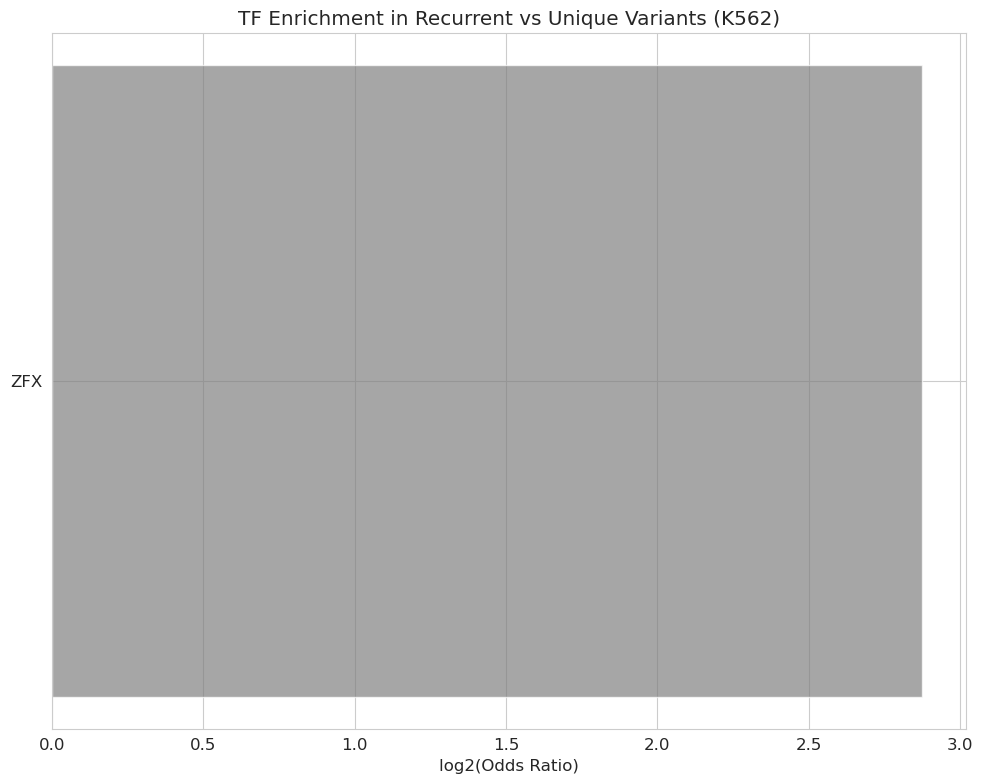

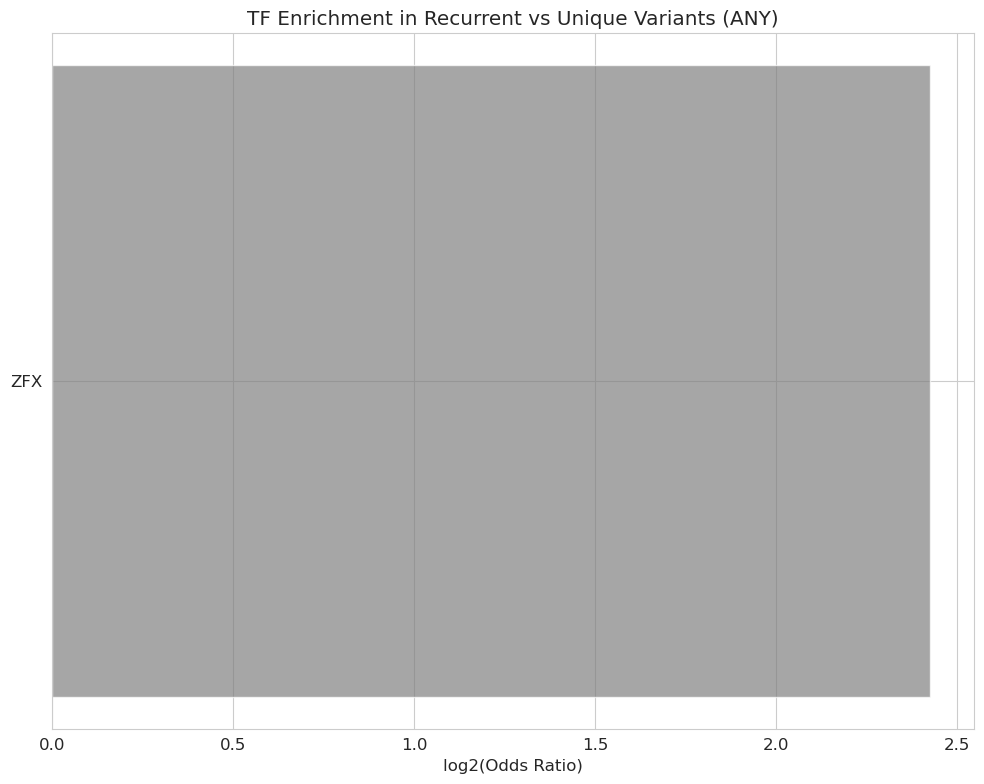

In [12]:
# visualize recurrence enrichments
for cell_type, result in recurrent_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1], 
            f'TF Enrichment in Recurrent vs Unique Variants ({cell_type.upper()})',
            max_display=15
        )
        plt.show()

## Analysis 2: TF Enrichment in emVars

In [13]:
# summary of emVars in dELS variants
print("emVar summary in dELS variants:")
for cell_type, emvar_col in emvar_cols.items():
    print(f"{cell_type}: {cosmic_df[emvar_col].sum():,} emVars")
print(f"Any cell type: {cosmic_df['emvar_any'].sum():,} emVars")

emVar summary in dELS variants:
k562: 21,803 emVars
hepg2: 16,143 emVars
sknsh: 19,953 emVars
Any cell type: 33,811 emVars


In [14]:
# TF enrichment in emVars - per cell type (matched TF and emVar cell type)
emvar_results = {}

for cell_type in tf_cols.keys():
    tf_col = tf_cols[cell_type]
    emvar_col = emvar_cols[cell_type]
    
    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment(cosmic_df, tf_col, emvar_col, condition_val=1, min_count=3)
    emvar_results[cell_type] = result
    
    if not result.empty:
        print(f"\nTop enriched TFs in emVars:")
        display(result[result['p_adj'] < 0.1].head(10))
    else:
        print("No TFs met minimum count threshold")


=== K562 ===

Top enriched TFs in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
11,KLF/SP/2,267,21536,116,1915522,204.727119,7.677558,0.000000e+00,0.000000e+00
9,AP1/1,237,21566,92,1915546,228.814480,7.838035,0.000000e+00,0.000000e+00
15,GATA,164,21639,57,1915581,254.701983,7.992666,2.814532e-267,7.130148e-266
8,ETS/1,129,21674,24,1915614,475.058838,8.891962,1.411847e-224,2.682509e-223
13,KLF/SP/1,103,21700,27,1915611,336.760425,8.395579,6.701345e-174,1.018604e-172
2,Ebox/CACCTG,130,21673,574,1915064,20.012241,4.322811,3.716707e-112,4.707829e-111
14,ETS/2,59,21744,15,1915623,346.522434,8.436805,1.516993e-100,1.647021e-99
0,INSM1,81,21722,171,1915467,41.769932,5.384393,5.212825e-92,4.952184e-91
29,Ebox/CACGTG/1,52,21751,22,1915616,208.166045,7.701591,1.250660e-83,1.056113e-82
36,AP1/2,51,21752,22,1915616,204.153466,7.673510,7.828228e-82,5.949453e-81



=== HEPG2 ===

Top enriched TFs in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
6,ETS/1,242,15901,75,1921223,389.858890,8.606808,0.000000e+00,0.000000e+00
11,AP1/1,193,15950,137,1921161,169.683579,7.406703,4.317286e-307,1.467877e-305
9,KLF/SP/2,156,15987,107,1921191,175.204150,7.452893,6.423227e-250,1.455931e-248
23,Ebox/CACGTG/1,115,16028,44,1921254,313.292945,8.291368,1.357798e-200,2.308257e-199
27,ETS/2,95,16048,39,1921259,291.624494,8.187968,1.544687e-164,2.100774e-163
12,NRF1,56,16087,17,1921281,393.418639,8.619921,5.106181e-101,5.787005e-100
10,CREB3/XBP1,57,16086,54,1921244,126.071104,6.978094,3.338029e-87,3.242657e-86
24,NFY,56,16087,80,1921218,83.598719,6.385409,1.239912e-78,1.053925e-77
32,YY1,57,16086,140,1921158,48.625249,5.603634,1.606362e-69,1.213696e-68
4,CREB/ATF/1,39,16104,27,1921271,172.327945,7.429013,1.526101e-63,1.037749e-62



=== SKNSH ===

Top enriched TFs in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
5,ETS/1,253,19700,61,1917427,403.685638,8.657088,0.000000e+00,0.000000e+00
15,AP1/1,222,19731,121,1917367,178.288674,7.478071,0.000000e+00,0.000000e+00
16,KLF/SP/2,177,19776,93,1917395,184.528501,7.527700,5.361973e-279,1.072395e-277
29,ETS/2,127,19826,38,1917450,323.228071,8.336409,6.587417e-216,9.881125e-215
14,Ebox/CACGTG/1,111,19842,52,1917436,206.279024,7.688453,1.605037e-178,1.926044e-177
0,Ebox/CACCTG,220,19733,1526,1915962,13.997869,3.807135,1.463640e-159,1.463640e-158
13,NRF1,65,19888,16,1917472,391.679907,8.613531,1.743739e-113,1.494634e-112
37,YY1,76,19877,83,1917405,88.328025,6.464799,1.382686e-105,1.037014e-104
25,NFY,65,19888,50,1917438,125.335348,6.969650,4.284694e-97,2.856463e-96
11,KLF/SP/1,48,19905,14,1917474,330.278652,8.367540,9.799085e-83,5.879451e-82


In [15]:
# TF enrichment in emVars - any cell type
print("\n=== ANY CELL TYPE ===")
emvar_any_result = fisher_exact_enrichment(cosmic_df, 'any_tf_fam', 'emvar_any', condition_val=1, min_count=3)
emvar_results['any'] = emvar_any_result

if not emvar_any_result.empty:
    print(f"\nTop enriched TFs in emVars (any cell type):")
    display(emvar_any_result[emvar_any_result['p_adj'] < 0.1].head(15))


=== ANY CELL TYPE ===

Top enriched TFs in emVars (any cell type):


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
11,AP1/1,387,33424,184,1903446,119.777510,6.904213,0.000000e+00,0.000000e+00
14,KLF/SP/2,311,33500,143,1903487,123.574670,6.949239,0.000000e+00,0.000000e+00
9,ETS/1,301,33510,71,1903559,240.824164,7.911836,0.000000e+00,0.000000e+00
20,GATA,171,33640,73,1903557,132.551043,7.050404,1.049779e-238,2.388247e-237
19,ETS/2,163,33648,56,1903574,164.668332,7.363419,4.900051e-235,8.918092e-234
2,Ebox/CACCTG,335,33476,1738,1901892,10.950837,3.452969,5.918326e-207,8.976127e-206
25,Ebox/CACGTG/1,139,33672,63,1903567,124.730742,6.962673,1.745983e-192,2.269777e-191
18,KLF/SP/1,109,33702,31,1903599,198.602448,7.633740,1.275027e-161,1.450343e-160
52,YY1,106,33705,210,1903420,28.505382,4.833162,1.612376e-102,1.630291e-101
24,NFY,90,33721,122,1903508,41.642514,5.379985,2.008415e-98,1.827658e-97


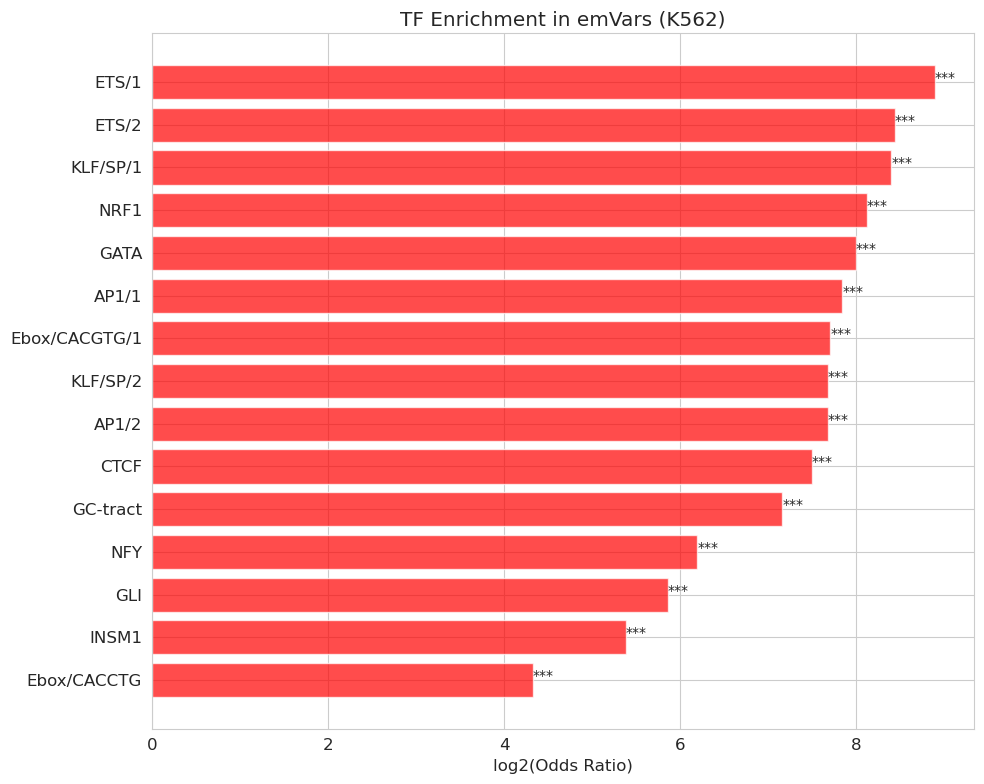

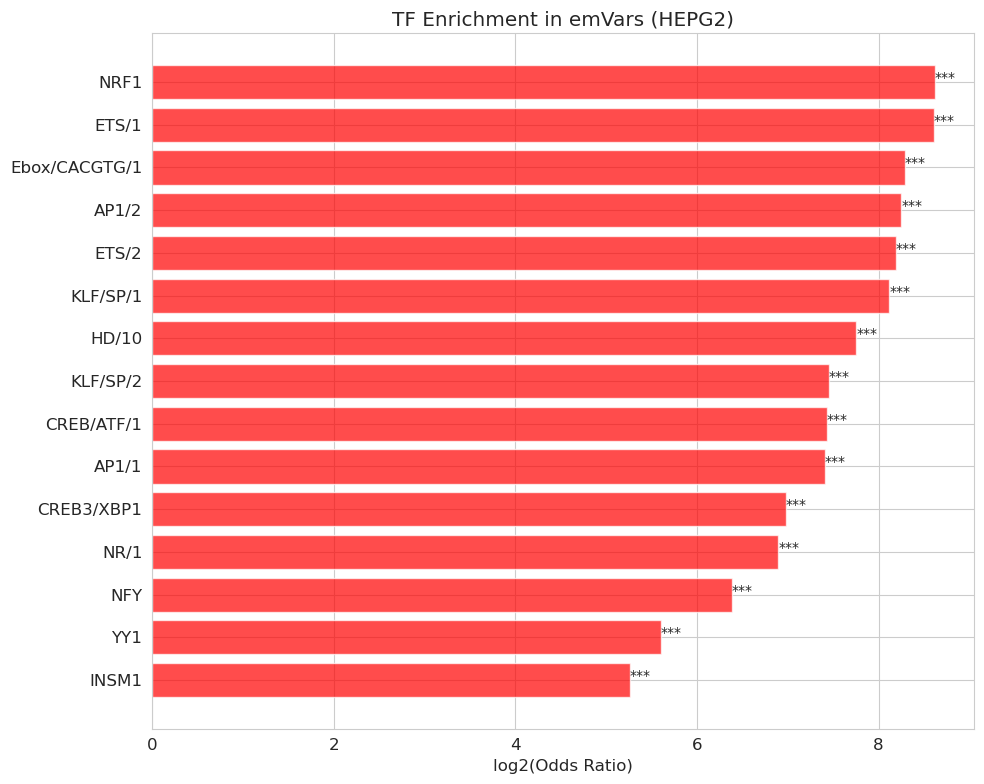

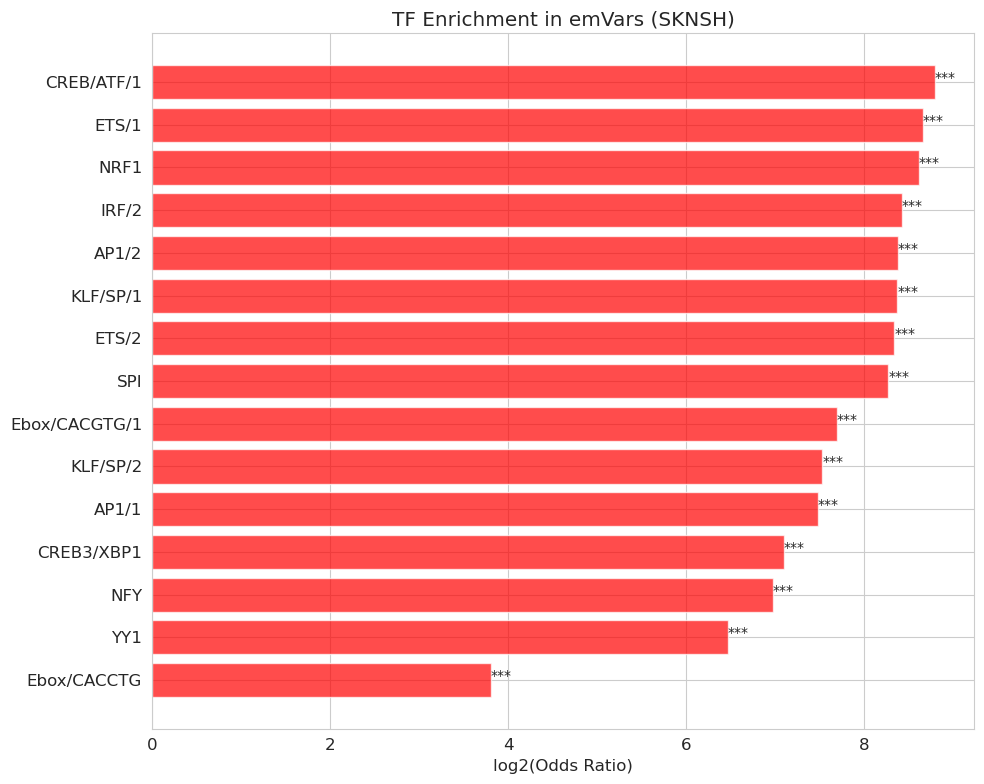

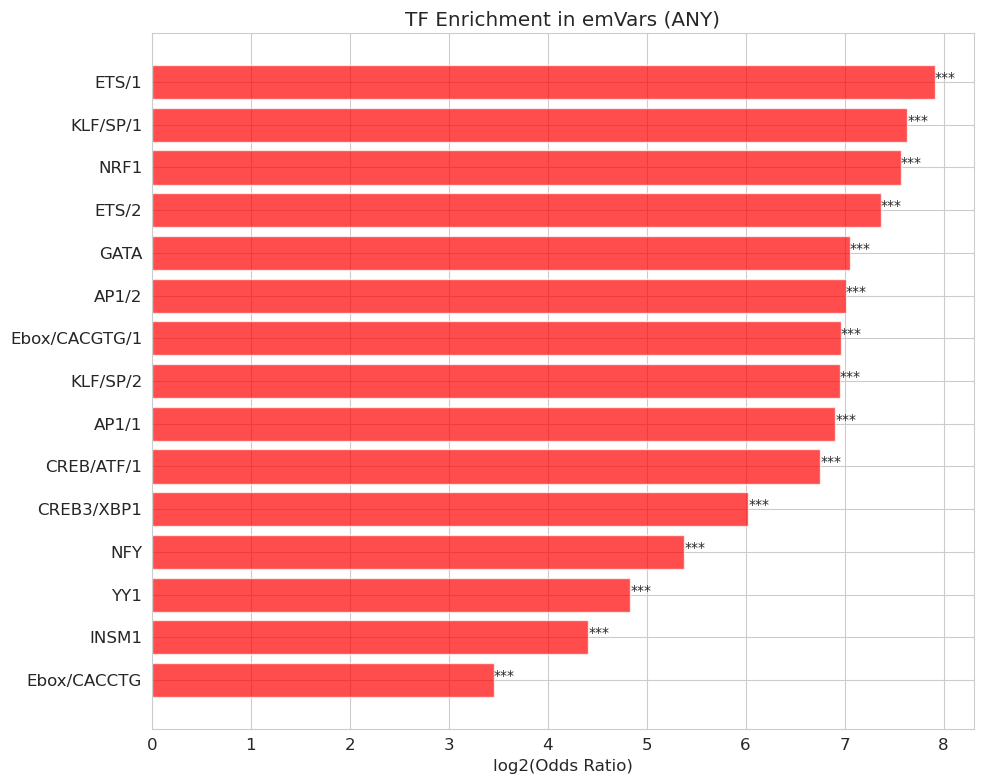

In [16]:
# visualize emVar enrichments
for cell_type, result in emvar_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1], 
            f'TF Enrichment in emVars ({cell_type.upper()})',
            max_display=15
        )
        plt.show()

## Analysis 3: TF Enrichment by Cancer Histology

In [17]:
# get top histology types (focusing on primary, not combined categories)
histology_counts = cosmic_df['primary_histology'].value_counts()
print("Top histology types in dELS variants:")
print(histology_counts.head(15))

Top histology types in dELS variants:
primary_histology
carcinoma                                           1443939
undifferentiated-unclassified_sarcoma                221429
lymphoid_neoplasm                                    204268
primitive_neuroectodermal_tumour-medulloblastoma      11600
angiosarcoma                                           9099
other                                                  7225
carcinoma:lymphoid_neoplasm                            6581
glioma                                                 5996
meningioma                                             4421
Wilms_tumour                                           4372
carcinoma:undifferentiated-unclassified_sarcoma        3647
haematopoietic_neoplasm                                2837
malignant_melanoma                                     2389
germ_cell_tumour                                       1582
carcinoma:haematopoietic_neoplasm                      1368
Name: count, dtype: int64


In [18]:
# get all melanomas
len([i for i in cosmic_df['primary_histology'] if 'melanoma' in i])

2563

In [19]:
# focus on major histology types (excluding combined categories for clarity)
major_histologies = [
    'carcinoma',
    'lymphoid_neoplasm',
    'malignant_melanoma',
    'undifferentiated-unclassified_sarcoma',
    'primitive_neuroectodermal_tumour-medulloblastoma',
    'glioma',
    'haematopoietic_neoplasm'
]

# filter to variants with these histologies
cosmic_major = cosmic_df[cosmic_df['primary_histology'].isin(major_histologies)].copy()
print(f"Variants with major histology types: {len(cosmic_major):,}")

Variants with major histology types: 1,892,458


In [20]:
# TF enrichment by histology - compare each histology vs all others
histology_results = {}

for histology in major_histologies:
    # create binary column for this histology
    cosmic_major['is_histology'] = (cosmic_major['primary_histology'] == histology).astype(int)
    
    print(f"\n=== {histology.upper()} ===")
    print(f"Count: {cosmic_major['is_histology'].sum():,}")
    
    result = fisher_exact_enrichment(cosmic_major, 'any_tf_fam', 'is_histology', condition_val=1, min_count=3)
    histology_results[histology] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.1]
        if len(sig_results) > 0:
            print(f"\nSignificant TF enrichments:")
            display(sig_results.head(10))


=== CARCINOMA ===
Count: 1,443,939

Significant TF enrichments:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,Ebox/CACCTG,1658,1442281,373,448146,1.381164,0.465885,6.486713e-09,7.329986e-07
58,ZNF768,56,1443883,40,448479,0.434849,-1.201415,9.809135e-05,5.542161e-03
65,CUX/1,73,1443866,7,448512,3.239455,1.695751,8.788441e-04,3.310313e-02



=== LYMPHOID_NEOPLASM ===
Count: 204,268

Significant TF enrichments:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,Ebox/CACCTG,147,204121,1884,1686306,0.644592,-0.633541,6.125808e-08,0.000004
50,ZNF768,28,204240,68,1688122,3.403393,1.766974,6.532185e-07,0.000021
13,GFI,21,204247,417,1687773,0.416142,-1.264852,1.364821e-05,0.000291
7,HIC/2,41,204227,579,1687611,0.585146,-0.773131,4.549279e-04,0.007279
12,KLF/SP/2,28,204240,413,1687777,0.560250,-0.835856,1.614998e-03,0.020672
23,NFY,10,204258,199,1687991,0.415277,-1.267854,3.470698e-03,0.037021
40,FOX/4,7,204261,16,1688174,3.615845,1.854333,8.750693e-03,0.080006



=== MALIGNANT_MELANOMA ===
Count: 2,389

Significant TF enrichments:


...


=== PRIMITIVE_NEUROECTODERMAL_TUMOUR-MEDULLOBLASTOMA ===
Count: 11,600

Significant TF enrichments:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
7,MIES,5,11595,205,1880653,3.95598,1.984035,0.009987,0.079897



=== GLIOMA ===
Count: 5,996

Significant TF enrichments:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
0,CREB/ATF/3,5,5991,443,1886019,3.553146,1.829097,0.014854,0.087303
3,ETS/1,4,5992,358,1886104,3.516987,1.814340,0.029101,0.087303
2,HIC/2,5,5991,615,1885847,2.559187,1.355686,0.049187,0.098374



=== HAEMATOPOIETIC_NEOPLASM ===
Count: 2,837


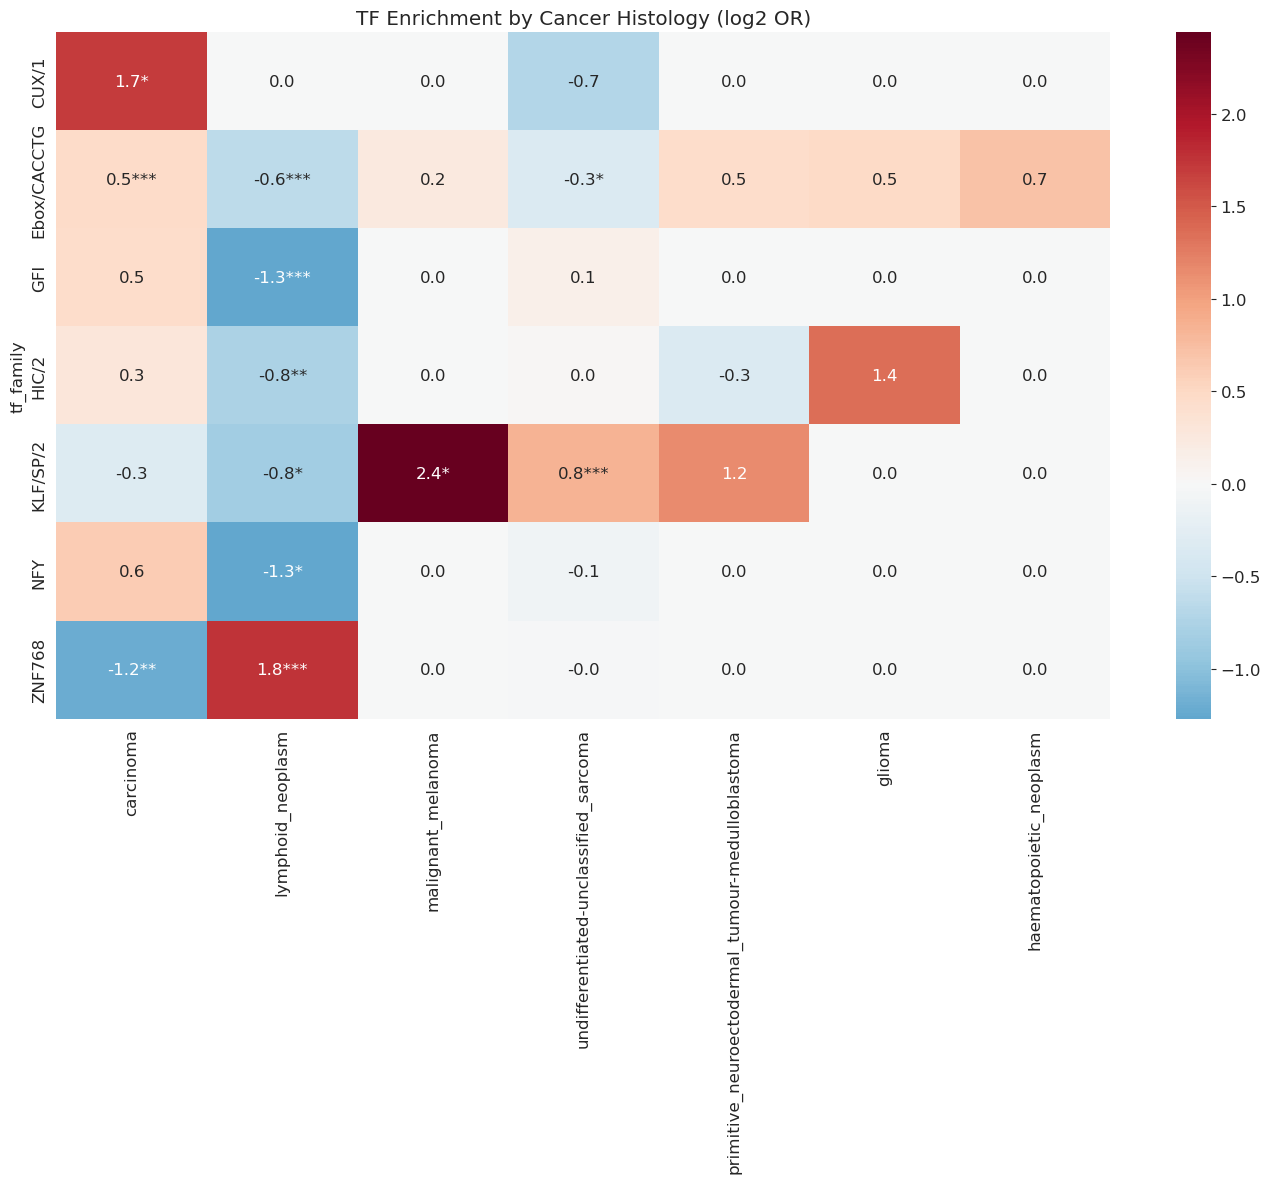

In [21]:
# heatmap of TF enrichments across histologies
fig = plot_enrichment_heatmap(
    histology_results,
    'TF Enrichment by Cancer Histology (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()

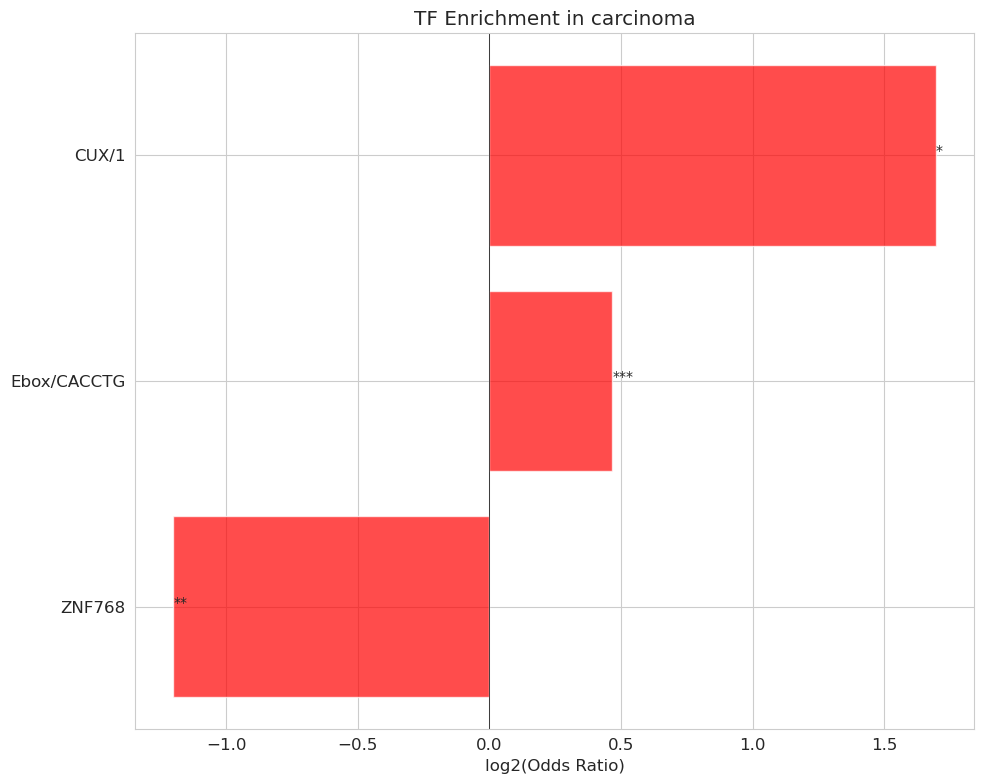

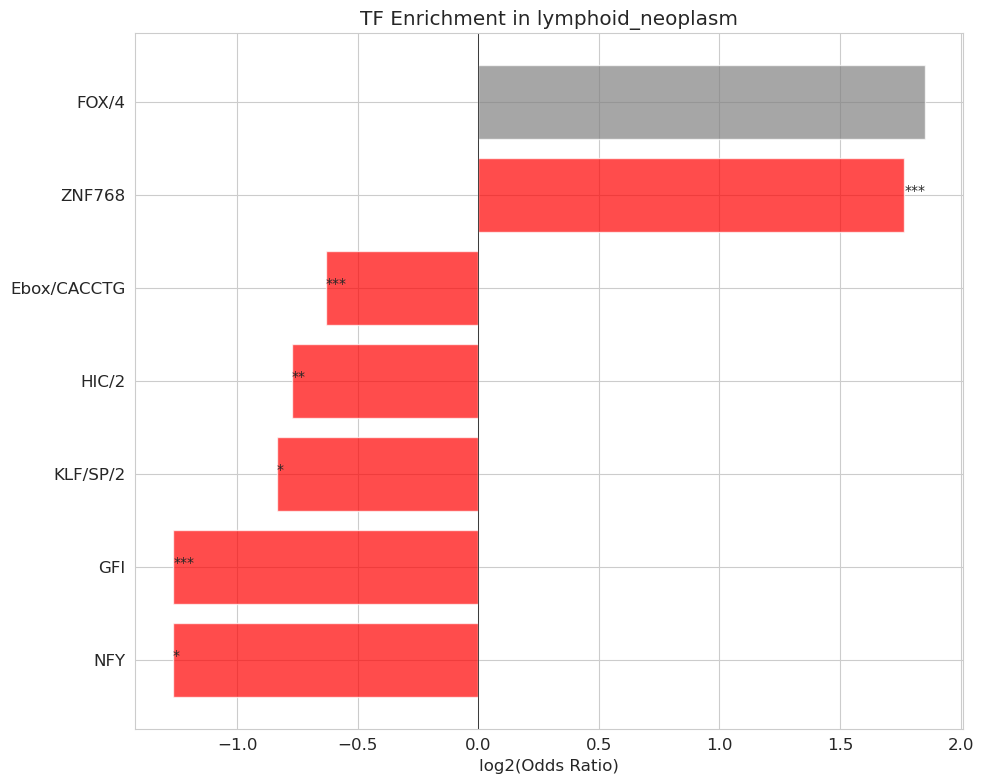

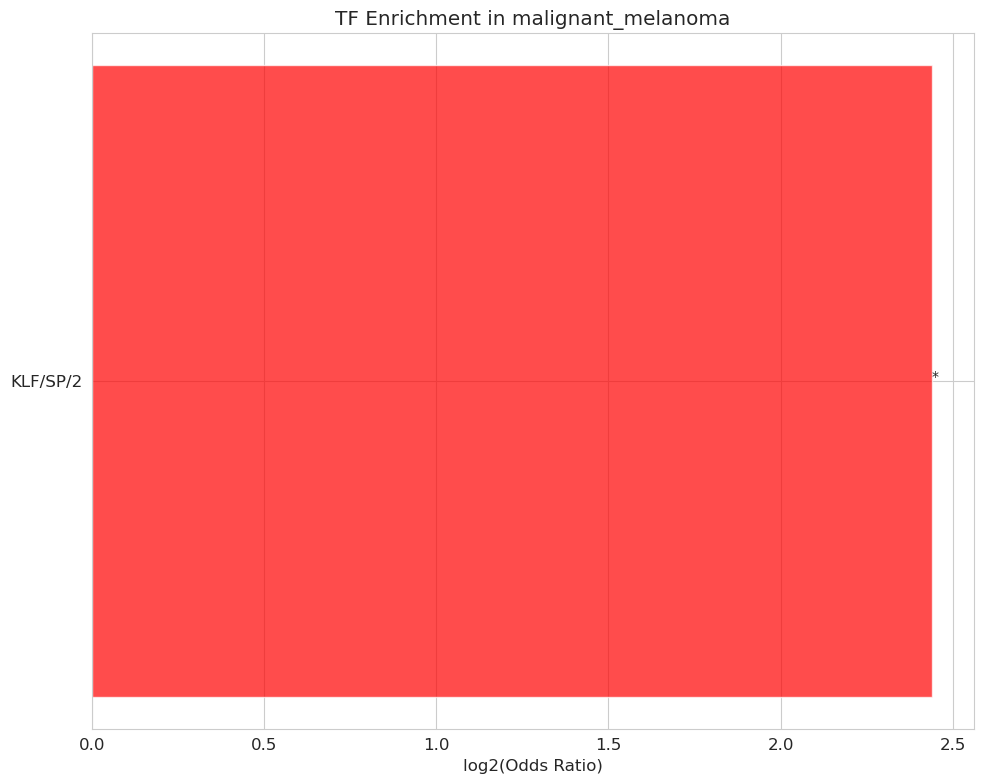

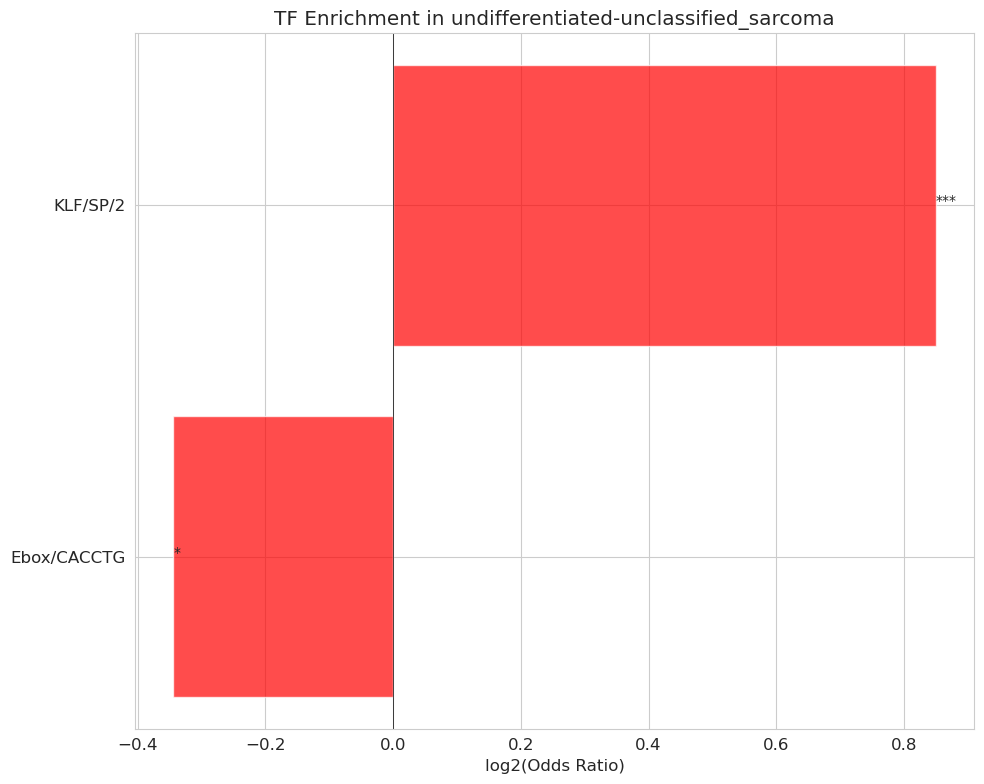

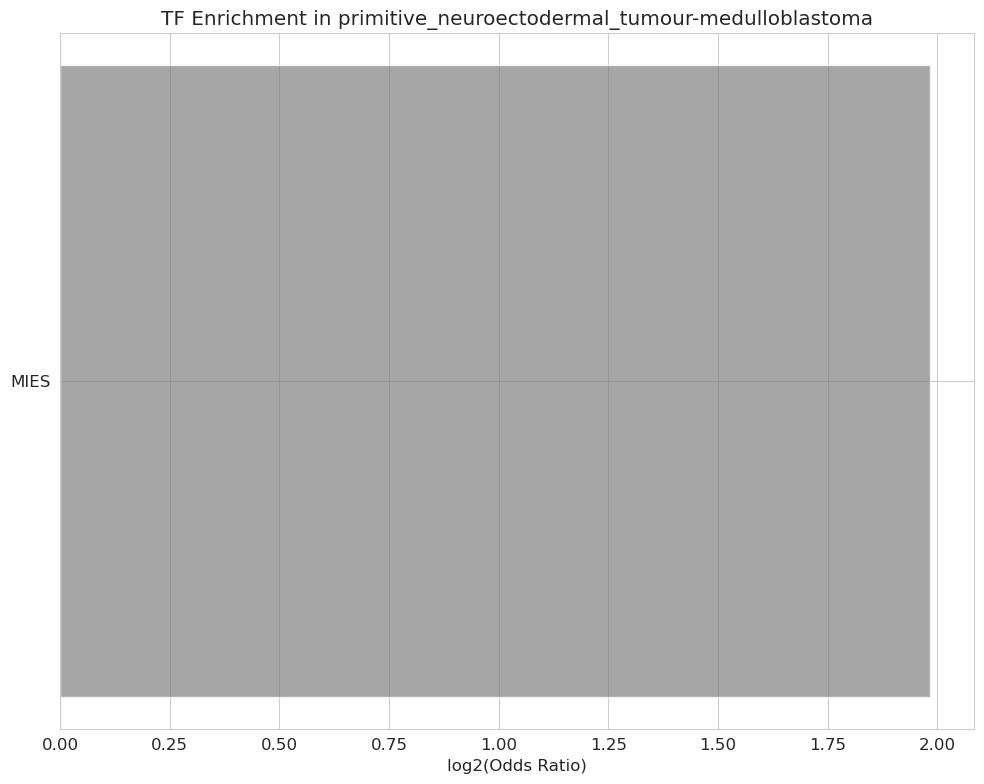

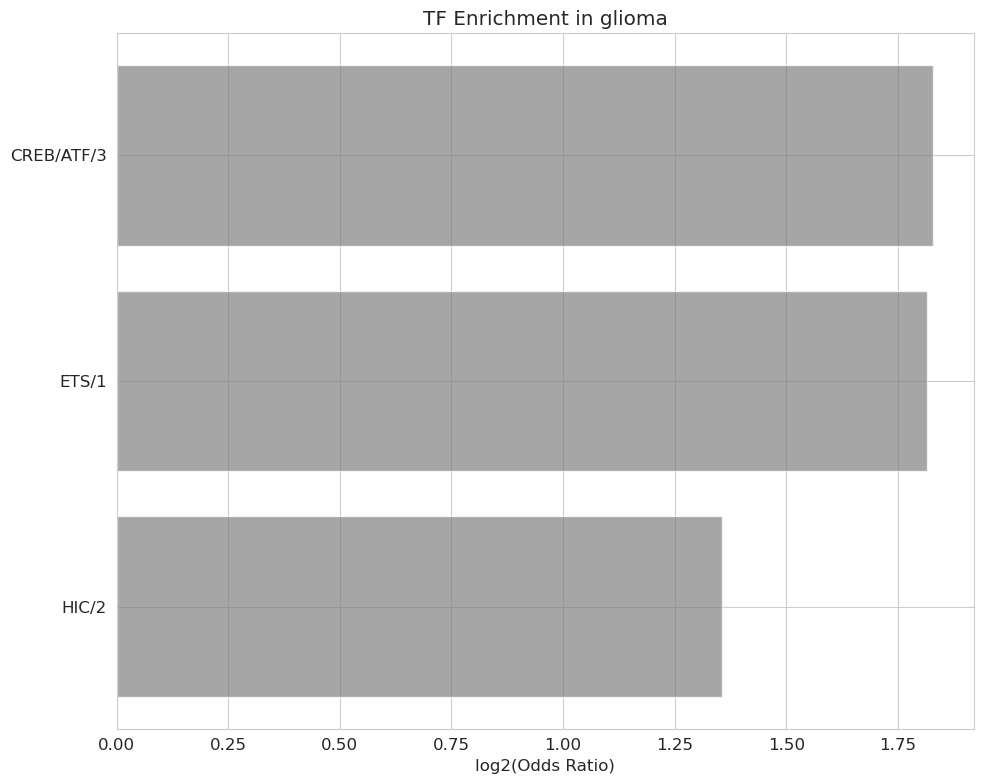

In [22]:
# forest plots for histologies with significant results
for histology, result in histology_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1], 
            f'TF Enrichment in {histology}',
            max_display=15
        )
        plt.show()

In [23]:
melAll = cosmic_df[cosmic_df['primary_histology'].isin(list(pd.Series([i for i in cosmic_df['primary_histology'] if 'melanoma' in i])))]


## Analysis 3b: TF Enrichment in Recurrent Variants by Histology

Are specific TFs enriched in recurrent variants within each cancer histology type?

In [24]:
# TF enrichment in recurrent variants - stratified by histology
recurrent_by_histology_results = {}

for histology in major_histologies:
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    n_total = len(hist_df)
    n_recurrent = hist_df['recurrent'].sum()
    
    if n_recurrent < 10:
        print(f"\n=== {histology.upper()} ===")
        print(f"Skipping: only {n_recurrent} recurrent variants")
        continue
    
    print(f"\n=== {histology.upper()} ===")
    print(f"Total variants: {n_total:,}, Recurrent: {n_recurrent:,} ({100*n_recurrent/n_total:.1f}%)")
    
    result = fisher_exact_enrichment(hist_df, 'any_tf_fam', 'recurrent', condition_val=1, min_count=2)
    recurrent_by_histology_results[histology] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.1]
        if len(sig_results) > 0:
            print(f"\nTFs enriched in recurrent variants:")
            display(sig_results.head(10))
        else:
            print("No significant TF enrichments at p_adj < 0.1")


=== CARCINOMA ===
Total variants: 1,443,939, Recurrent: 31,926 (2.2%)

TFs enriched in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
0,CREB/ATF/3,18,31908,341,1411672,2.335352,1.22364,0.0016,0.054396



=== LYMPHOID_NEOPLASM ===
Total variants: 204,268, Recurrent: 6,053 (3.0%)

TFs enriched in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,KLF/SP/1,3,6050,9,198206,10.920441,3.448959,0.004680,0.032761
6,GLI,3,6050,22,198193,4.467160,2.159358,0.036792,0.094329
5,ZBTB7A,2,6051,9,198206,7.279091,2.863758,0.040427,0.094329



=== MALIGNANT_MELANOMA ===
Total variants: 2,389, Recurrent: 493 (20.6%)

=== UNDIFFERENTIATED-UNCLASSIFIED_SARCOMA ===
Total variants: 221,429, Recurrent: 722 (0.3%)

=== PRIMITIVE_NEUROECTODERMAL_TUMOUR-MEDULLOBLASTOMA ===
Skipping: only 4 recurrent variants

=== GLIOMA ===
Total variants: 5,996, Recurrent: 115 (1.9%)

=== HAEMATOPOIETIC_NEOPLASM ===
Total variants: 2,837, Recurrent: 2,016 (71.1%)
No significant TF enrichments at p_adj < 0.1


In [25]:
# identify unique emVars in the same enhancers as those with recurrent emVars at ETS/1 sites in melanoma
cosmic_df[(cosmic_df['primary_histology'] == 'malignant_melanoma') & 
        ((cosmic_df['any_tf_fam'] == 'KLF/SP/1')) &
        (cosmic_df['recurrent'] == 0) &
        (cosmic_df['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,all_histology,k562_pro_seqlet_tf_fam,hepg2_pro_seqlet_tf_fam,sknsh_pro_seqlet_tf_fam,has_tf_any,any_tf_fam,has_pro_tf_any,any_pro_tf_fam,has_combined_tf_any,any_combined_tf_fam


In [26]:
cosmic_df[(cosmic_df['primary_histology'] == 'malignant_melanoma') & 
        (cosmic_df['k562_dELS_seqlet_tf_fam'] == 'ETS/2') &# | (cosmic_df['hepg2_dELS_seqlet_tf_fam'] == 'ETS/1') | (cosmic_df['sknsh_dELS_seqlet_tf_fam'] == 'ETS/1')) &
        (cosmic_df['recurrent'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,all_histology,k562_pro_seqlet_tf_fam,hepg2_pro_seqlet_tf_fam,sknsh_pro_seqlet_tf_fam,has_tf_any,any_tf_fam,has_pro_tf_any,any_pro_tf_fam,has_combined_tf_any,any_combined_tf_fam


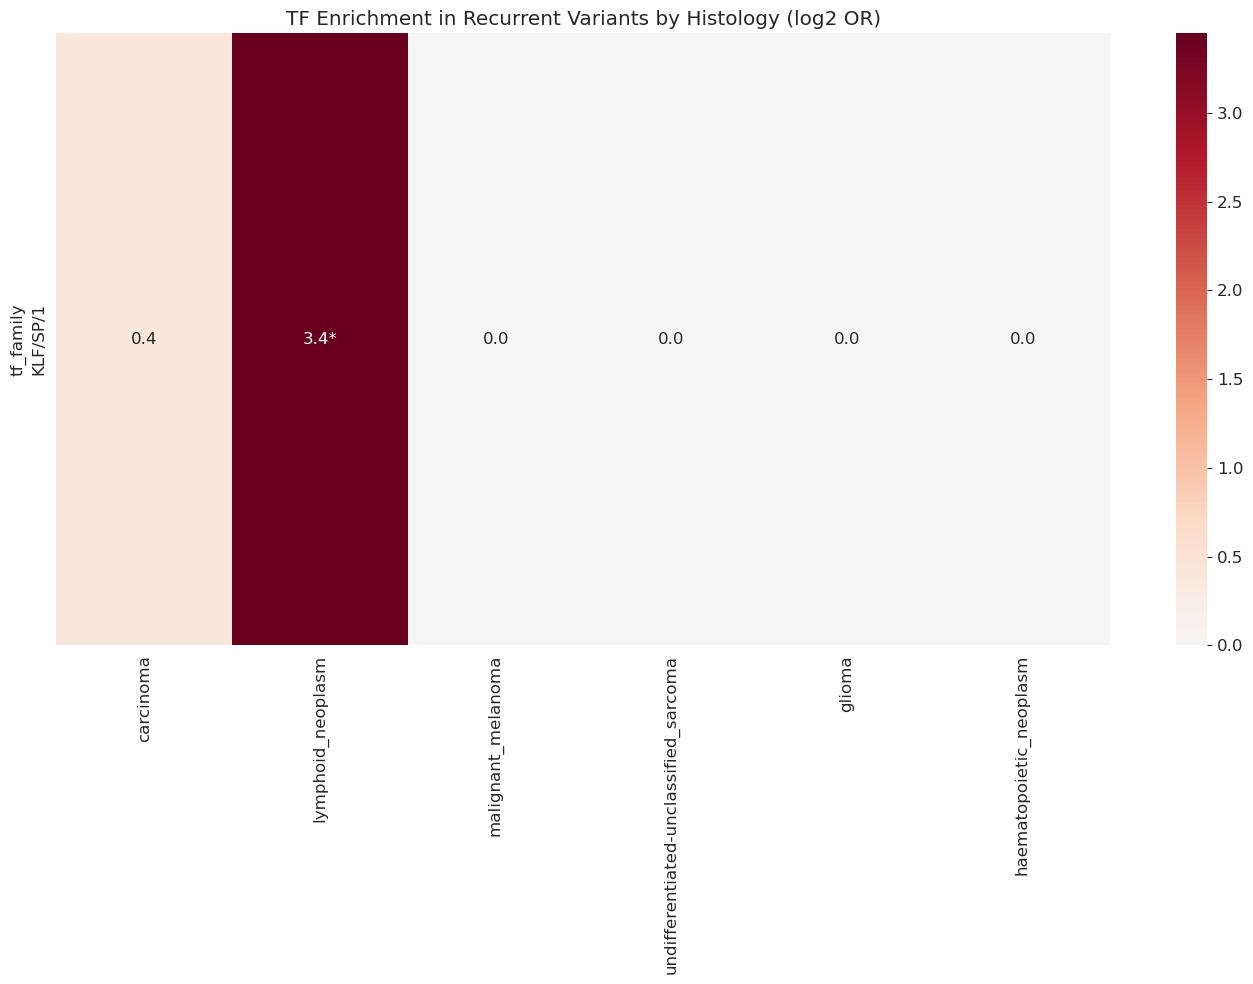

In [27]:
# heatmap of TF enrichments in recurrent variants across histologies
fig = plot_enrichment_heatmap(
    recurrent_by_histology_results,
    'TF Enrichment in Recurrent Variants by Histology (log2 OR)',
    figsize=(14, 10),
    show_significance=True
)
if fig:
    plt.show()

In [29]:
# Are recurrent variants more likely to be in seqlets, stratified by histology?
print("=== Seqlet Enrichment in Recurrent Variants by Histology ===\n")

seqlet_by_histology = []

for histology in major_histologies:
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    
    has_tf = hist_df['has_tf_any'] == 1
    is_recurrent = hist_df['recurrent'] == 1
    
    a = (has_tf & is_recurrent).sum()
    b = (has_tf & ~is_recurrent).sum()
    c = (~has_tf & is_recurrent).sum()
    d = (~has_tf & ~is_recurrent).sum()
    
    if (a + c) < 10:
        continue
    
    odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])
    
    seqlet_by_histology.append({
        'histology': histology,
        'recurrent_with_tf': a,
        'recurrent_no_tf': c,
        'unique_with_tf': b,
        'unique_no_tf': d,
        'pct_recurrent_in_seqlet': 100 * a / (a + c) if (a + c) > 0 else 0,
        'pct_unique_in_seqlet': 100 * b / (b + d) if (b + d) > 0 else 0,
        'odds_ratio': odds_ratio,
        'p_value': p_value
    })

seqlet_hist_df = pd.DataFrame(seqlet_by_histology)
if not seqlet_hist_df.empty:
    seqlet_hist_df['p_adj'] = multipletests(seqlet_hist_df['p_value'], method='fdr_bh')[1]
    display(seqlet_hist_df[['histology', 'recurrent_with_tf', 'unique_with_tf',
                            'pct_recurrent_in_seqlet', 'pct_unique_in_seqlet',
                            'odds_ratio', 'p_value', 'p_adj']])

=== Seqlet Enrichment in Recurrent Variants by Histology ===



,histology,recurrent_with_tf,unique_with_tf,pct_recurrent_in_seqlet,pct_unique_in_seqlet,odds_ratio,p_value,p_adj
0,carcinoma,207,8868,0.648374,0.628040,1.032590,0.641486,0.641486
1,lymphoid_neoplasm,32,917,0.528663,0.462629,1.143496,0.441961,0.641486
2,malignant_melanoma,3,25,0.608519,1.318565,0.458204,0.243993,0.618593
3,undifferentiated-unclassified_sarcoma,1,1313,0.138504,0.594906,0.231753,0.140929,0.618593
4,glioma,0,51,0.000000,0.867199,0.000000,0.626942,0.641486
5,haematopoietic_neoplasm,16,3,0.793651,0.365408,2.181333,0.309296,0.618593


## Analysis 4: Cell Type - Cancer Biology Connections

Examining whether TF disruptions in specific cell types are enriched in biologically relevant cancer types:
- K562 (CML) → Lymphoid/Haematopoietic neoplasms
- HepG2 (HCC) → Liver carcinomas (subset of carcinoma)
- SK-N-SH (Neuroblastoma) → Primitive neuroectodermal tumors

In [30]:
# analyze cell type-specific TF disruptions in relevant cancer types

cell_histology_pairs = [
    ('k562', 'lymphoid_neoplasm', 'K562 TFs in Lymphoid Neoplasm'),
    ('k562', 'haematopoietic_neoplasm', 'K562 TFs in Haematopoietic Neoplasm'),
    ('sknsh', 'primitive_neuroectodermal_tumour-medulloblastoma', 'SKNSH TFs in PNET/Medulloblastoma'),
]

cell_cancer_results = {}

for cell_type, histology, label in cell_histology_pairs:
    tf_col = tf_cols[cell_type]
    
    # filter to variants with TF in this cell type (TF values are strings, '0' = no TF)
    has_tf = cosmic_df[cosmic_df[tf_col] != '0'].copy()
    
    if len(has_tf) == 0:
        print(f"\n{label}: No variants with TF")
        continue
    
    # check if this histology is enriched for variants with TF in this cell type
    has_tf['is_histology'] = has_tf['primary_histology'].str.contains(histology, case=False, na=False).astype(int)
    
    print(f"\n=== {label} ===")
    print(f"Variants with {cell_type} TF: {len(has_tf):,}")
    print(f"  In {histology}: {has_tf['is_histology'].sum():,}")
    
    result = fisher_exact_enrichment(has_tf, tf_col, 'is_histology', condition_val=1, min_count=2)
    cell_cancer_results[label] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.1]
        if len(sig_results) > 0:
            print(f"\nTFs enriched in {histology}:")
            display(sig_results.head(10))


=== K562 TFs in Lymphoid Neoplasm ===
Variants with k562 TF: 6,031
  In lymphoid_neoplasm: 491

TFs enriched in lymphoid_neoplasm:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
32,ZNF768,13,478,33,5507,4.538544,2.18223,0.000049,0.002596



=== K562 TFs in Haematopoietic Neoplasm ===
Variants with k562 TF: 6,031
  In haematopoietic_neoplasm: 14

TFs enriched in haematopoietic_neoplasm:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,NRF1,2,12,52,5965,19.11859,4.256904,0.006684,0.020053



=== SKNSH TFs in PNET/Medulloblastoma ===
Variants with sknsh TF: 6,089
  In primitive_neuroectodermal_tumour-medulloblastoma: 43

TFs enriched in primitive_neuroectodermal_tumour-medulloblastoma:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
4,KLF/SP/2,6,37,264,5782,3.551597,1.828468,0.011012,0.066073


In [31]:
# compare TF disruptions: do variants in biologically-relevant histologies have more TF disruptions?
print("\n=== Cell Type - Cancer Biology Concordance ===")

for cell_type, relevant_histologies in cell_cancer_map.items():
    tf_col = tf_cols[cell_type]
    
    # variants with TF in this cell type (TF values are strings, '0' = no TF)
    has_tf = cosmic_df[tf_col] != '0'
    
    # variants in relevant histology
    is_relevant = cosmic_df['primary_histology'].isin(relevant_histologies)
    
    # 2x2 table
    a = (has_tf & is_relevant).sum()  # TF + relevant histology
    b = (has_tf & ~is_relevant).sum()  # TF + other histology
    c = (~has_tf & is_relevant).sum()  # no TF + relevant histology
    d = (~has_tf & ~is_relevant).sum()  # no TF + other histology
    
    odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])
    
    print(f"\n{cell_type.upper()} TFs in {relevant_histologies}:")
    print(f"  With TF & relevant histology: {a}")
    print(f"  With TF & other histology: {b}")
    print(f"  No TF & relevant histology: {c}")
    print(f"  No TF & other histology: {d}")
    print(f"  Odds Ratio: {odds_ratio:.3f}")
    print(f"  P-value: {p_value:.2e}")


=== Cell Type - Cancer Biology Concordance ===

K562 TFs in ['lymphoid_neoplasm', 'haematopoietic_neoplasm']:
  With TF & relevant histology: 485
  With TF & other histology: 5546
  No TF & relevant histology: 206620
  No TF & other histology: 1724790
  Odds Ratio: 0.730
  P-value: 4.62e-12

HEPG2 TFs in ['carcinoma']:
  With TF & relevant histology: 4889
  With TF & other histology: 1511
  No TF & relevant histology: 1439050
  No TF & other histology: 491991
  Odds Ratio: 1.106
  P-value: 5.93e-04

SKNSH TFs in ['primitive_neuroectodermal_tumour-medulloblastoma']:
  With TF & relevant histology: 43
  With TF & other histology: 6046
  No TF & relevant histology: 11557
  No TF & other histology: 1919795
  Odds Ratio: 1.181
  P-value: 2.78e-01


## Summary Tables

In [32]:
# compile all significant results into summary tables

def compile_significant_results(results_dict, analysis_name):
    """Compile significant results from multiple analyses."""
    all_sig = []
    for condition, result in results_dict.items():
        if result.empty:
            continue
        sig = result[result['p_adj'] < 0.05].copy()
        if len(sig) > 0:
            sig['condition'] = condition
            sig['analysis'] = analysis_name
            all_sig.append(sig)
    
    if all_sig:
        return pd.concat(all_sig, ignore_index=True)
    return pd.DataFrame()

# compile results
recurrent_sig = compile_significant_results(recurrent_results, 'Recurrent vs Unique')
emvar_sig = compile_significant_results(emvar_results, 'emVar vs non-emVar')
histology_sig = compile_significant_results(histology_results, 'Histology')

print("=== Significant Results Summary ===")
print(f"\nRecurrent vs Unique: {len(recurrent_sig)} significant TF-condition pairs")
print(f"emVar vs non-emVar: {len(emvar_sig)} significant TF-condition pairs")
print(f"Histology: {len(histology_sig)} significant TF-condition pairs")

=== Significant Results Summary ===

Recurrent vs Unique: 0 significant TF-condition pairs
emVar vs non-emVar: 295 significant TF-condition pairs
Histology: 12 significant TF-condition pairs


In [33]:
# display summary tables
if not recurrent_sig.empty:
    print("\n=== Recurrent vs Unique - Significant Results ===")
    display(recurrent_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj', 'condition_with_tf']].sort_values('p_adj'))

if not emvar_sig.empty:
    print("\n=== emVar vs non-emVar - Significant Results ===")
    display(emvar_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj', 'condition_with_tf']].sort_values('p_adj'))

if not histology_sig.empty:
    print("\n=== Histology - Significant Results ===")
    display(histology_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj', 'condition_with_tf']].sort_values('p_adj'))


=== emVar vs non-emVar - Significant Results ===


,tf_family,condition,odds_ratio,log2_or,p_adj,condition_with_tf
0,KLF/SP/2,k562,204.727119,7.677558,0.000000,267
1,AP1/1,k562,228.814480,7.838035,0.000000,237
204,AP1/1,any,119.777510,6.904213,0.000000,387
205,KLF/SP/2,any,123.574670,6.949239,0.000000,311
76,ETS/1,hepg2,389.858890,8.606808,0.000000,242
...,...,...,...,...,...,...
203,ZNF146,sknsh,13.106398,3.712199,0.002120,3
74,HD/8,k562,7.988665,2.997954,0.002131,4
75,MEF2,k562,10.139090,3.341856,0.004184,3
142,HD/21,hepg2,9.156701,3.194828,0.005288,3



=== Histology - Significant Results ===


,tf_family,condition,odds_ratio,log2_or,p_adj,condition_with_tf
0,Ebox/CACCTG,carcinoma,1.381164,0.465885,7.329986e-07,1658
3,Ebox/CACCTG,lymphoid_neoplasm,0.644592,-0.633541,3.920517e-06,147
4,ZNF768,lymphoid_neoplasm,3.403393,1.766974,2.090299e-05,28
10,KLF/SP/2,undifferentiated-unclassified_sarcoma,1.802157,0.849725,2.837043e-04,85
5,GFI,lymphoid_neoplasm,0.416142,-1.264852,2.911617e-04,21
1,ZNF768,carcinoma,0.434849,-1.201415,5.542161e-03,56
6,HIC/2,lymphoid_neoplasm,0.585146,-0.773131,7.278847e-03,41
7,KLF/SP/2,lymphoid_neoplasm,0.560250,-0.835856,2.067198e-02,28
2,CUX/1,carcinoma,3.239455,1.695751,3.310313e-02,73
8,NFY,lymphoid_neoplasm,0.415277,-1.267854,3.702077e-02,10


In [34]:
# # save results to files
# output_dir = '../processed_data/tf_enrichment_results'
# import os
# os.makedirs(output_dir, exist_ok=True)

# # save all results
# for name, result in recurrent_results.items():
#     if not result.empty:
#         result.to_csv(f'{output_dir}/recurrent_vs_unique_{name}.tsv', sep='\t', index=False)

# for name, result in emvar_results.items():
#     if not result.empty:
#         result.to_csv(f'{output_dir}/emvar_{name}.tsv', sep='\t', index=False)

# for name, result in histology_results.items():
#     if not result.empty:
#         safe_name = name.replace('/', '_').replace('-', '_')
#         result.to_csv(f'{output_dir}/histology_{safe_name}.tsv', sep='\t', index=False)

# print(f"Results saved to {output_dir}")

---

## Analysis 5: TF Enrichment in Carcinoma Subtypes

The previous analyses treat "carcinoma" as a single category, but carcinomas encompass many distinct subtypes (adenocarcinoma, squamous cell carcinoma, hepatocellular carcinoma, etc.). This section loads the raw COSMIC data to extract carcinoma subtype information and performs the same TF enrichment analyses within carcinoma subsets.

**Major carcinoma subtypes analyzed:**
- Adenocarcinoma
- Ductal carcinoma
- Squamous cell carcinoma
- Hepatocellular carcinoma
- Endometrioid carcinoma
- Transitional cell carcinoma
- Clear cell renal cell carcinoma

In [35]:
# Load raw COSMIC data to extract carcinoma subtypes
print("Loading raw COSMIC data...")
raw_cosmic = pd.read_csv('../raw_data/CosmicNCV.tsv', sep='\t', 
                          usecols=['GENOMIC_MUTATION_ID', 'Primary histology', 'Histology subtype 1'])
print(f"Raw COSMIC records: {len(raw_cosmic):,}")

# Filter to carcinomas only
raw_carcinoma = raw_cosmic[raw_cosmic['Primary histology'] == 'carcinoma'].copy()
print(f"Carcinoma records: {len(raw_carcinoma):,}")

# Preview subtypes
print("\nCarcinoma subtype distribution:")
print(raw_carcinoma['Histology subtype 1'].value_counts().head(15))

Loading raw COSMIC data...
Raw COSMIC records: 18,778,798
Carcinoma records: 14,406,522

Carcinoma subtype distribution:
Histology subtype 1
adenocarcinoma                                      4170799
NS                                                  4156298
ductal_carcinoma                                    2909429
mixed_adenosquamous_carcinoma                        683824
squamous_cell_carcinoma                              551794
hepatocellular_carcinoma                             412132
endometrioid_carcinoma                               341519
HER-positive_carcinoma                               232193
carcinosarcoma-malignant_mesodermal_mixed_tumour     146582
transitional_cell_carcinoma                          145104
basal_cell_carcinoma                                 117308
clear_cell_renal_cell_carcinoma                       91841
lobular_carcinoma                                     78198
small_cell_carcinoma                                  67472
serous_carcinoma   

In [36]:
# Define major carcinoma subtypes to analyze
major_carcinoma_subtypes = [
    'adenocarcinoma',
    'ductal_carcinoma', 
    'squamous_cell_carcinoma',
    'hepatocellular_carcinoma',
    'endometrioid_carcinoma',
    'transitional_cell_carcinoma',
    'clear_cell_renal_cell_carcinoma'
]

# Create a mapping: variant ID -> set of subtypes it was observed in
# A variant can appear in multiple subtypes across different samples
print("Creating variant-to-subtype mapping...")
variant_subtypes = raw_carcinoma.groupby('GENOMIC_MUTATION_ID')['Histology subtype 1'].apply(set).to_dict()
print(f"Unique carcinoma variants with subtype info: {len(variant_subtypes):,}")

# Check how many variants have multiple subtypes
multi_subtype = sum(1 for v in variant_subtypes.values() if len(v) > 1)
print(f"Variants observed in multiple subtypes: {multi_subtype:,} ({100*multi_subtype/len(variant_subtypes):.1f}%)")

Creating variant-to-subtype mapping...
Unique carcinoma variants with subtype info: 12,395,005
Variants observed in multiple subtypes: 453,248 (3.7%)


In [37]:
# Filter dELS data to carcinomas only
cosmic_carcinoma = cosmic_df[cosmic_df['primary_histology'] == 'carcinoma'].copy()
print(f"Carcinoma variants in dELS: {len(cosmic_carcinoma):,}")

# Add binary columns for each major carcinoma subtype
# A variant is marked as belonging to a subtype if it was observed in at least one sample of that subtype
for subtype in major_carcinoma_subtypes:
    cosmic_carcinoma[f'is_{subtype}'] = cosmic_carcinoma['id'].apply(
        lambda x: 1 if x in variant_subtypes and subtype in variant_subtypes[x] else 0
    )

# Also create a column for "all subtypes" (concatenated string for reference)
cosmic_carcinoma['all_subtypes'] = cosmic_carcinoma['id'].apply(
    lambda x: '|'.join(sorted(variant_subtypes.get(x, {'unknown'})))
)

# Summary of subtype coverage
print("\nCarcinoma subtype coverage in dELS variants:")
for subtype in major_carcinoma_subtypes:
    count = cosmic_carcinoma[f'is_{subtype}'].sum()
    pct = 100 * count / len(cosmic_carcinoma)
    print(f"  {subtype}: {count:,} ({pct:.1f}%)")

# Check NS (not specified) coverage
ns_count = cosmic_carcinoma['id'].apply(lambda x: 1 if x in variant_subtypes and 'NS' in variant_subtypes[x] else 0).sum()
print(f"  NS (not specified): {ns_count:,} ({100*ns_count/len(cosmic_carcinoma):.1f}%)")

Carcinoma variants in dELS: 1,443,939

Carcinoma subtype coverage in dELS variants:
  adenocarcinoma: 30,967 (2.1%)
  ductal_carcinoma: 341,445 (23.6%)
  squamous_cell_carcinoma: 1,143 (0.1%)
  hepatocellular_carcinoma: 221,584 (15.3%)
  endometrioid_carcinoma: 1,916 (0.1%)
  transitional_cell_carcinoma: 83,027 (5.8%)
  clear_cell_renal_cell_carcinoma: 265 (0.0%)
  NS (not specified): 738,769 (51.2%)


### 5a. TF Enrichment by Carcinoma Subtype

Compare TF enrichment in each carcinoma subtype vs all other carcinomas.

In [38]:
# TF enrichment by carcinoma subtype - compare each subtype vs all other carcinomas
carcinoma_subtype_results = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    n_variants = cosmic_carcinoma[col_name].sum()
    
    print(f"\n=== {subtype.upper().replace('_', ' ')} ===")
    print(f"Variants: {n_variants:,}")
    
    if n_variants < 100:
        print("Skipping: insufficient variants")
        continue
    
    result = fisher_exact_enrichment(cosmic_carcinoma, 'any_tf_fam', col_name, condition_val=1, min_count=3)
    carcinoma_subtype_results[subtype] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.01]
        if len(sig_results) > 0:
            print(f"\nSignificant TF enrichments:")
            display(sig_results.head(10))
        else:
            print("No significant TF enrichments at p_adj < 0.01")


=== ADENOCARCINOMA ===
Variants: 30,967
No significant TF enrichments at p_adj < 0.01

=== DUCTAL CARCINOMA ===
Variants: 341,445
No significant TF enrichments at p_adj < 0.01

=== SQUAMOUS CELL CARCINOMA ===
Variants: 1,143

=== HEPATOCELLULAR CARCINOMA ===
Variants: 221,584
No significant TF enrichments at p_adj < 0.01

=== ENDOMETRIOID CARCINOMA ===
Variants: 1,916
No significant TF enrichments at p_adj < 0.01

=== TRANSITIONAL CELL CARCINOMA ===
Variants: 83,027

Significant TF enrichments:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
16,ZNF680,12,83015,59,1360853,3.334140,1.737315,0.000694,0.009049
17,TBX/4,13,83014,68,1360844,3.133946,1.647980,0.000705,0.009049
18,ZIM3,13,83014,68,1360844,3.133946,1.647980,0.000705,0.009049
10,AP1/1,44,82983,406,1360506,1.776798,0.829279,0.000739,0.009049



=== CLEAR CELL RENAL CELL CARCINOMA ===
Variants: 265


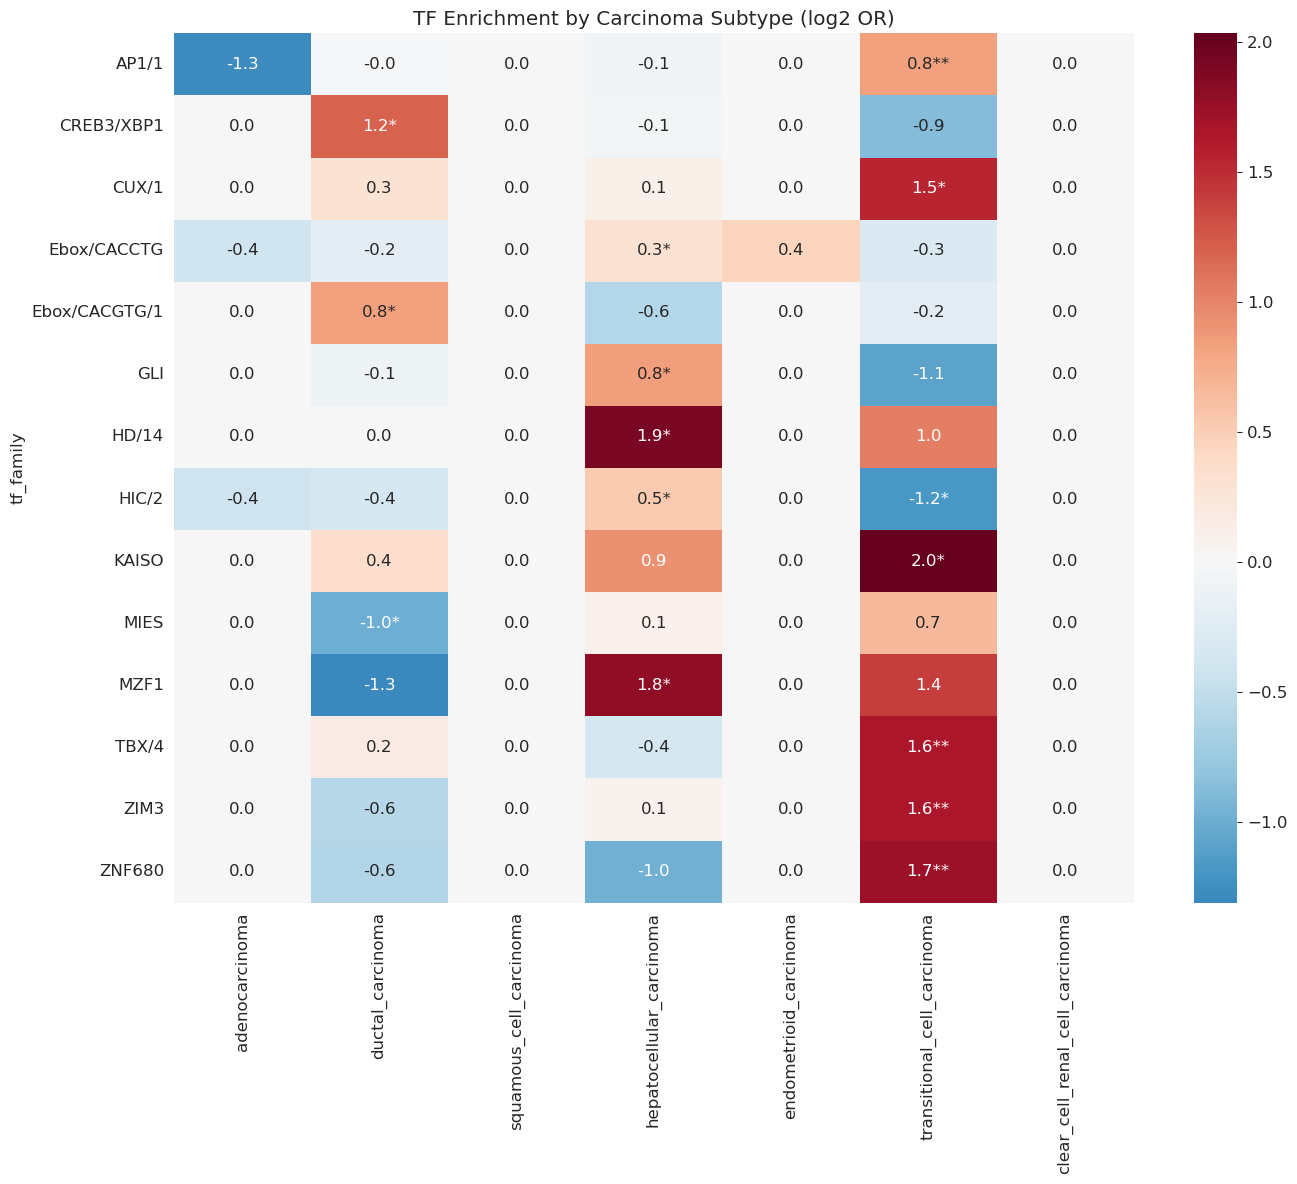

In [39]:
# Heatmap of TF enrichments across carcinoma subtypes
fig = plot_enrichment_heatmap(
    carcinoma_subtype_results,
    'TF Enrichment by Carcinoma Subtype (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()

In [ ]:
# # Forest plots for carcinoma subtypes with significant results
# for subtype, result in carcinoma_subtype_results.items():
#     if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
#         fig = plot_enrichment_forest(
#             result[result['p_adj'] < 0.1], 
#             f'TF Enrichment in {subtype.replace("_", " ").title()}',
#             max_display=15
#         )
#         plt.show()

### 5b. TF Enrichment in Recurrent Variants by Carcinoma Subtype

Are specific TFs enriched in recurrent variants within each carcinoma subtype?

In [40]:
# TF enrichment in recurrent variants - stratified by carcinoma subtype
recurrent_by_carcinoma_subtype = {}

# Dictionary to store variants for each significantly enriched TF by subtype
# Structure: {subtype: {tf_family: [list of variant IDs]}}
recurrent_variants_by_subtype_tf = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    
    n_total = len(subtype_df)
    n_recurrent = subtype_df['recurrent'].sum()
    
    if n_total < 100:
        continue
    
    print(f"\n=== {subtype.upper().replace('_', ' ')} ===")
    print(f"Total variants: {n_total:,}, Recurrent: {n_recurrent:,} ({100*n_recurrent/n_total:.1f}%)")
    
    if n_recurrent < 10:
        print("Skipping: insufficient recurrent variants")
        continue
    
    result = fisher_exact_enrichment(subtype_df, 'any_tf_fam', 'recurrent', condition_val=1, min_count=2)
    recurrent_by_carcinoma_subtype[subtype] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.1]
        if len(sig_results) > 0:
            print(f"\nTFs enriched in recurrent variants:")
            display(sig_results.head(10))
            
            # Collect variant IDs for each significant TF
            recurrent_variants_by_subtype_tf[subtype] = {}
            for _, row in sig_results.iterrows():
                tf = row['tf_family']
                # Get variants that are: recurrent AND have this TF
                mask = (subtype_df['recurrent'] == 1) & (subtype_df['any_tf_fam'] == tf)
                variant_ids = subtype_df.loc[mask, 'id'].tolist()
                recurrent_variants_by_subtype_tf[subtype][tf] = variant_ids
                print(f"  {tf}: {len(variant_ids)} recurrent variants")
        else:
            print("No significant TF enrichments at p_adj < 0.1")


=== ADENOCARCINOMA ===
Total variants: 30,967, Recurrent: 1,887 (6.1%)

TFs enriched in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
0,ETS/2,2,1885,3,29077,10.283643,3.362279,0.032798,0.032798


  ETS/2: 2 recurrent variants

=== DUCTAL CARCINOMA ===
Total variants: 341,445, Recurrent: 15,075 (4.4%)
No significant TF enrichments at p_adj < 0.1

=== SQUAMOUS CELL CARCINOMA ===
Total variants: 1,143, Recurrent: 126 (11.0%)

=== HEPATOCELLULAR CARCINOMA ===
Total variants: 221,584, Recurrent: 5,134 (2.3%)

TFs enriched in recurrent variants:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,CREB/ATF/3,11,5123,56,216394,8.297085,3.052604,3.978522e-07,0.000003
3,SMAD,3,5131,14,216436,9.039007,3.176164,6.627108e-03,0.023195


  CREB/ATF/3: 11 recurrent variants
  SMAD: 3 recurrent variants

=== ENDOMETRIOID CARCINOMA ===
Total variants: 1,916, Recurrent: 114 (5.9%)

=== TRANSITIONAL CELL CARCINOMA ===
Total variants: 83,027, Recurrent: 7,678 (9.2%)
No significant TF enrichments at p_adj < 0.1

=== CLEAR CELL RENAL CELL CARCINOMA ===
Total variants: 265, Recurrent: 54 (20.4%)


In [41]:
# save recurrent variants by carcinoma subtype to disk
with open('../processed_data/adenocarcinoma_recurrent_tf_enrichments.pkl', 'wb') as f:
    pickle.dump(recurrent_variants_by_subtype_tf, f)

In [42]:
# Summary of collected recurrent variants by subtype and TF
print("=== Recurrent Variants by Carcinoma Subtype and Enriched TF ===\n")
for subtype, tf_dict in recurrent_variants_by_subtype_tf.items():
    print(f"\n{subtype.upper().replace('_', ' ')}:")
    for tf, variants in tf_dict.items():
        print(f"  {tf}: {len(variants)} variants")
        if len(variants) <= 10:
            print(f"    IDs: {variants}")
        else:
            print(f"    First 10 IDs: {variants[:10]}")

# The full dictionary is available as: recurrent_variants_by_subtype_tf
print(f"\n\nFull dictionary stored in: recurrent_variants_by_subtype_tf")
print(f"Structure: {{subtype: {{tf_family: [variant_ids]}}}}")

=== Recurrent Variants by Carcinoma Subtype and Enriched TF ===


ADENOCARCINOMA:
  ETS/2: 2 variants
    IDs: ['COSV56709650', 'COSV59185042']

HEPATOCELLULAR CARCINOMA:
  CREB/ATF/3: 11 variants
    First 10 IDs: ['COSV56995255', 'COSV71375277', 'COSV60297901', 'COSV60320741', 'COSV60321788', 'COSV58305684', 'COSV58745885', 'COSV73900708', 'COSV51479875', 'COSV53885861']
  SMAD: 3 variants
    IDs: ['COSV56671149', 'COSV53312542', 'COSV54608344']


Full dictionary stored in: recurrent_variants_by_subtype_tf
Structure: {subtype: {tf_family: [variant_ids]}}


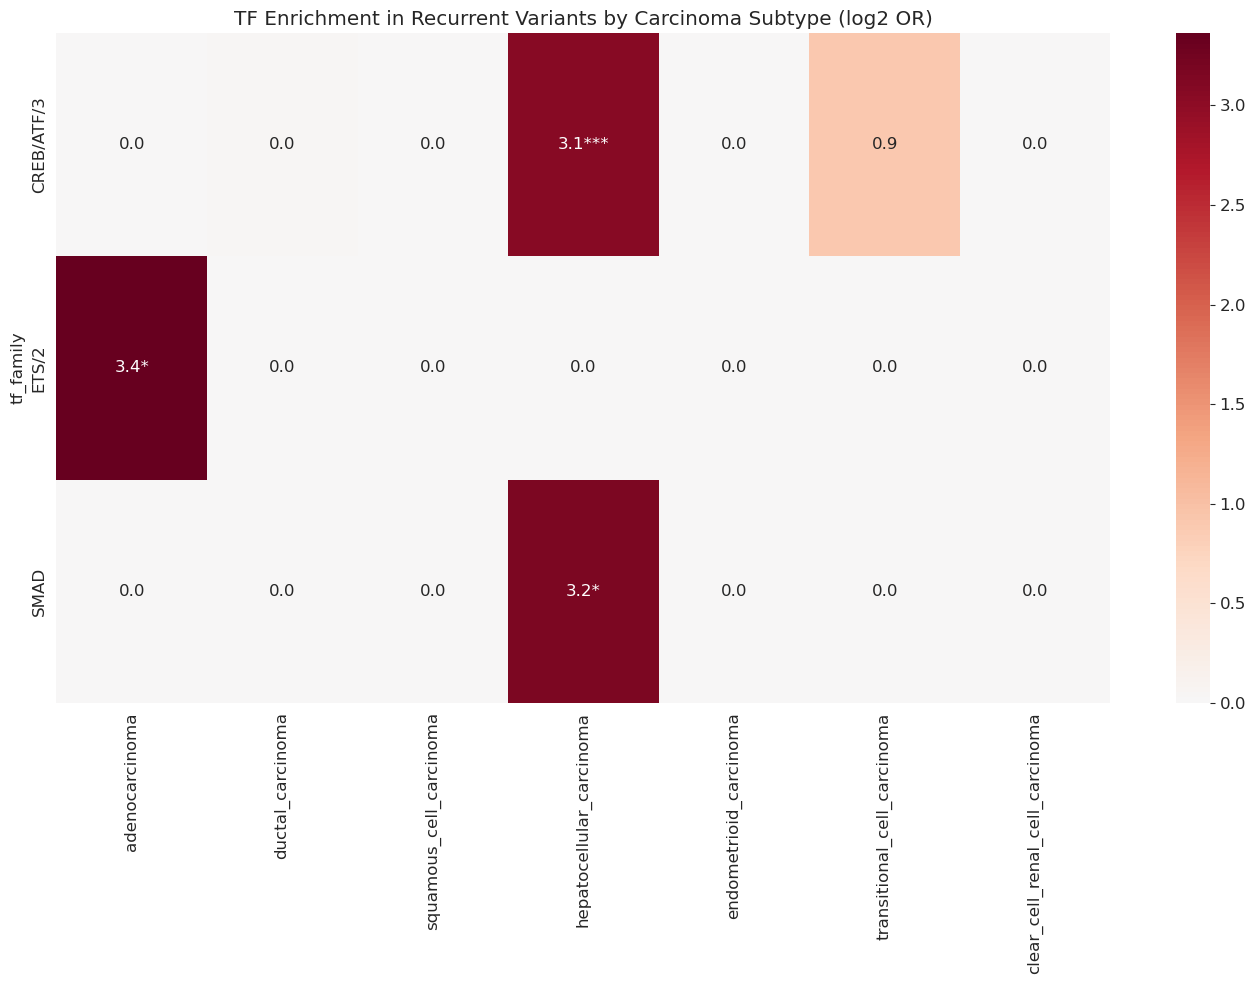

In [43]:
# Heatmap of TF enrichments in recurrent variants across carcinoma subtypes
if recurrent_by_carcinoma_subtype:
    fig = plot_enrichment_heatmap(
        recurrent_by_carcinoma_subtype,
        'TF Enrichment in Recurrent Variants by Carcinoma Subtype (log2 OR)',
        figsize=(14, 10)
    )
    if fig:
        plt.show()

### 5c. TF Enrichment in emVars by Carcinoma Subtype

Are specific TFs enriched in emVars within each carcinoma subtype?

In [49]:
# TF enrichment in emVars - stratified by carcinoma subtype
emvar_by_carcinoma_subtype = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    
    n_total = len(subtype_df)
    n_emvar = subtype_df['emvar_any'].sum()
    
    if n_total < 100:
        continue
    
    print(f"\n=== {subtype.upper().replace('_', ' ')} ===")
    print(f"Total variants: {n_total:,}, emVars: {n_emvar:,} ({100*n_emvar/n_total:.1f}%)")
    
    if n_emvar < 10:
        print("Skipping: insufficient emVars")
        continue
    
    result = fisher_exact_enrichment(subtype_df, 'any_tf_fam', 'emvar_any', condition_val=1, min_count=3)
    emvar_by_carcinoma_subtype[subtype] = result
    
    if not result.empty:
        sig_results = result[result['p_adj'] < 0.1]
        if len(sig_results) > 0:
            print(f"\nTFs enriched in emVars:")
            display(sig_results.head(10))
        else:
            print("No significant TF enrichments at p_adj < 0.1")


=== ADENOCARCINOMA ===
Total variants: 30,967, emVars: 649 (2.1%)

TFs enriched in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
0,Ebox/CACCTG,8,641,19,30299,19.902455,4.314874,5.568365e-08,2.784183e-07
3,ETS/2,4,645,1,30317,188.012403,7.554684,9.399735e-07,2.349934e-06
2,KLF/SP/1,3,646,1,30317,140.791022,7.137412,3.608107e-05,4.510134e-05
4,AP1/1,3,646,1,30317,140.791022,7.137412,3.608107e-05,4.510134e-05
1,ETS/1,3,646,4,30314,35.194272,5.137269,3.011499e-04,3.011499e-04



=== DUCTAL CARCINOMA ===
Total variants: 341,445, emVars: 6,320 (1.9%)

TFs enriched in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,KLF/SP/2,73,6247,19,335106,206.100933,7.687207,3.556481e-108,1.742676e-106
22,ETS/1,67,6253,10,335115,359.070926,8.488125,5.333407e-105,1.306685e-103
11,AP1/1,73,6247,32,335093,122.367681,6.935079,1.128010e-100,1.842416e-99
4,ETS/2,33,6287,6,335119,293.169159,8.195590,1.798784e-51,2.203511e-50
8,Ebox/CACGTG/1,36,6284,14,335111,137.128262,7.099382,2.792294e-51,2.736448e-50
5,Ebox/CACCTG,67,6253,281,334844,12.767991,3.674460,2.058507e-46,1.681114e-45
6,GATA,30,6290,10,335115,159.832273,7.320415,6.959898e-44,4.871928e-43
13,KLF/SP/1,28,6292,7,335118,213.043865,7.735007,1.716519e-42,1.051368e-41
24,YY1,23,6297,31,335094,39.481996,5.303123,8.488858e-26,4.621712e-25
1,CREB/ATF/1,16,6304,4,335121,212.640228,7.732271,8.415584e-25,4.123636e-24



=== SQUAMOUS CELL CARCINOMA ===
Total variants: 1,143, emVars: 42 (3.7%)

=== HEPATOCELLULAR CARCINOMA ===
Total variants: 221,584, emVars: 4,520 (2.0%)

TFs enriched in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
1,AP1/1,46,4474,20,217044,111.578274,6.801912,3.798716e-62,1.709422e-60
7,ETS/1,39,4481,7,217057,269.876718,8.076157,4.703905e-59,1.058379e-57
31,KLF/SP/2,42,4478,25,217039,81.425976,6.347417,8.492798e-54,1.273920e-52
34,ETS/2,20,4500,6,217058,160.783704,7.328977,3.057461e-29,3.439644e-28
5,GATA,20,4500,12,217052,80.389630,6.328937,2.667042e-26,2.400338e-25
4,Ebox/CACCTG,46,4474,257,216807,8.673653,3.116640,5.742945e-26,4.307208e-25
30,KLF/SP/1,11,4509,2,217062,264.768463,8.048587,1.888685e-17,1.214154e-16
42,NRF1,9,4511,2,217062,216.532698,7.758441,3.215964e-14,1.808980e-13
18,NFY,12,4508,21,217043,27.512105,4.781995,1.219753e-12,6.098767e-12
32,GLI,13,4507,31,217033,20.193885,4.335847,2.995015e-12,1.347757e-11



=== ENDOMETRIOID CARCINOMA ===
Total variants: 1,916, emVars: 79 (4.1%)

=== TRANSITIONAL CELL CARCINOMA ===
Total variants: 83,027, emVars: 1,439 (1.7%)

TFs enriched in emVars:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
11,AP1/1,31,1408,13,81575,138.156960,7.110164,7.707605e-45,1.849825e-43
3,ETS/1,15,1424,2,81586,429.701545,8.747191,4.686318e-25,5.623582e-24
1,GATA,11,1428,6,81582,104.738796,6.710652,4.592822e-16,3.674257e-15
9,KLF/SP/2,9,1430,6,81582,85.575524,6.419126,6.274536e-13,3.764721e-12
6,AP1/2,5,1434,1,81587,284.473501,8.152150,9.185294e-09,4.408941e-08
17,KAISO,5,1434,2,81586,142.235007,7.152133,3.168598e-08,1.267439e-07
13,NFY,6,1433,9,81579,37.952547,5.246125,1.174383e-07,4.026457e-07
20,ETS/2,5,1434,4,81584,71.115760,6.152097,1.846878e-07,5.540634e-07
5,INSM1,6,1433,13,81575,26.273552,4.715539,5.998991e-07,1.599731e-06
7,NFAT/1,4,1435,3,81585,75.804878,6.244219,3.016630e-06,7.239913e-06



=== CLEAR CELL RENAL CELL CARCINOMA ===
Total variants: 265, emVars: 13 (4.9%)


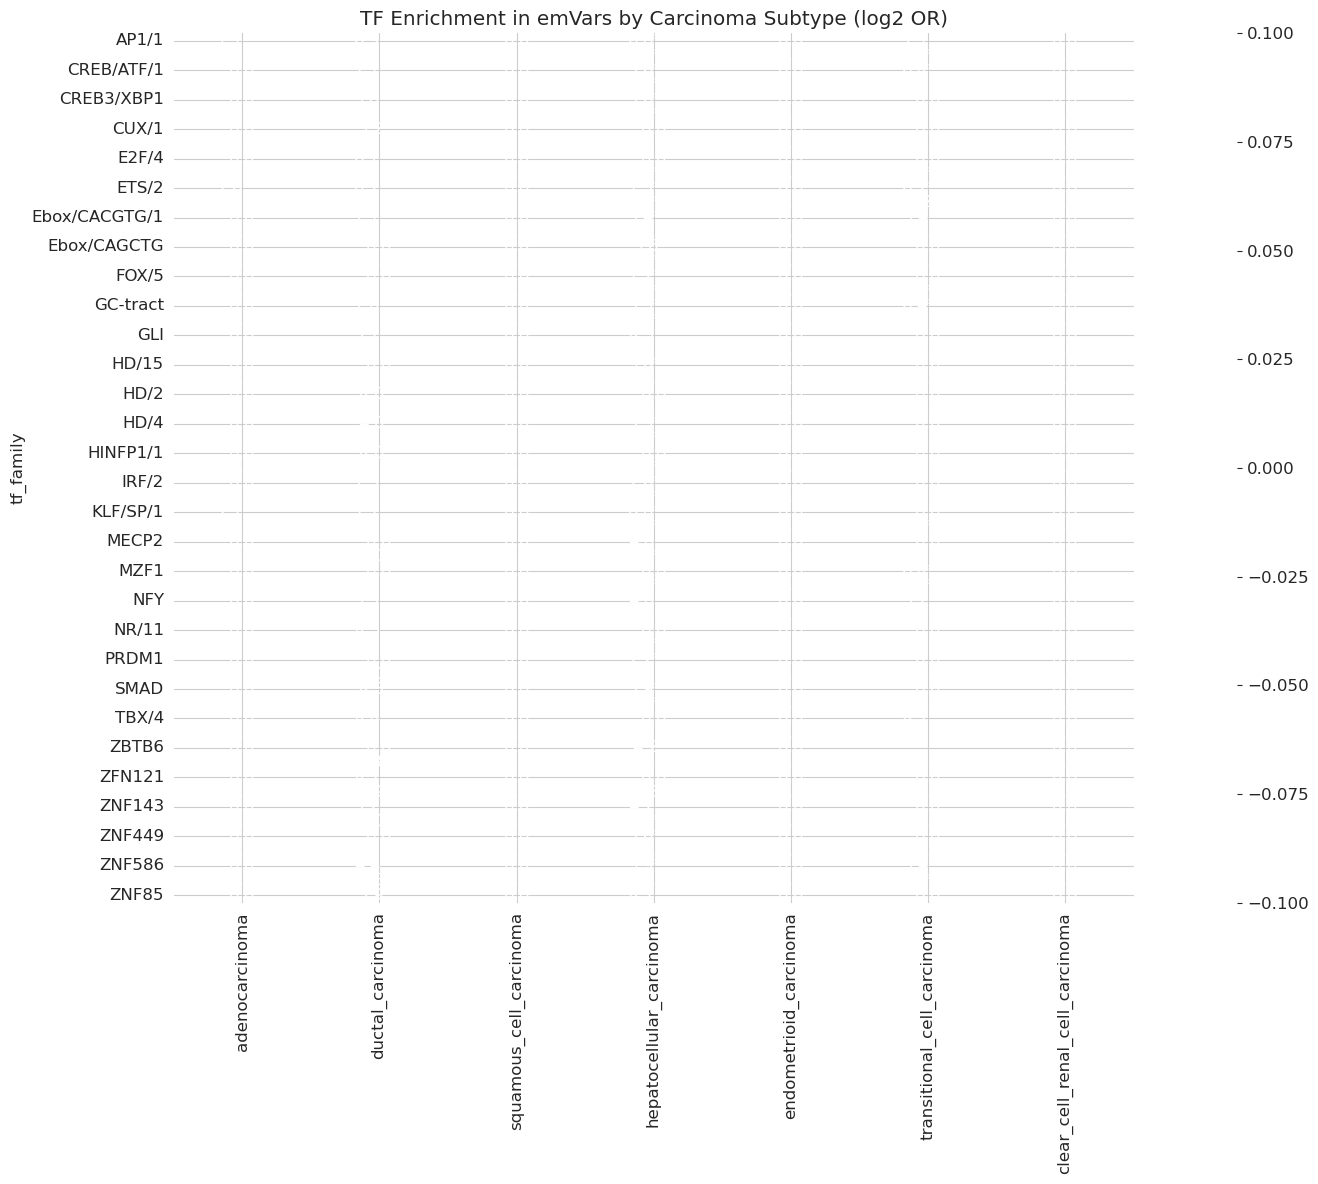

In [45]:
# Heatmap of TF enrichments in emVars across carcinoma subtypes
if emvar_by_carcinoma_subtype:
    fig = plot_enrichment_heatmap(
        emvar_by_carcinoma_subtype,
        'TF Enrichment in emVars by Carcinoma Subtype (log2 OR)',
        figsize=(14, 12)
    )
    if fig:
        plt.show()

### 5d. Cell Type - Carcinoma Subtype Connections

Examining whether TF disruptions in HepG2 (hepatocellular carcinoma cell line) are enriched specifically in hepatocellular carcinoma variants compared to other carcinoma subtypes.

In [50]:
# HepG2 - Hepatocellular carcinoma connection
print("=== HepG2 TF Disruptions in Hepatocellular Carcinoma ===\n")

# Compare HepG2 TF disruption rates between HCC and other carcinomas
hepg2_tf_col = 'hepg2_dELS_seqlet_tf_fam'
has_hepg2_tf = cosmic_carcinoma[hepg2_tf_col] != '0'
is_hcc = cosmic_carcinoma['is_hepatocellular_carcinoma'] == 1

# 2x2 table
a = (has_hepg2_tf & is_hcc).sum()       # HepG2 TF + HCC
b = (has_hepg2_tf & ~is_hcc).sum()      # HepG2 TF + other carcinoma
c = (~has_hepg2_tf & is_hcc).sum()      # No HepG2 TF + HCC
d = (~has_hepg2_tf & ~is_hcc).sum()     # No HepG2 TF + other carcinoma

odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])

print("HepG2 TF disruptions in HCC vs other carcinomas:")
print(f"  HCC with HepG2 TF: {a:,} ({100*a/(a+c):.1f}%)")
print(f"  Other carcinomas with HepG2 TF: {b:,} ({100*b/(b+d):.1f}%)")
print(f"  Odds Ratio: {odds_ratio:.3f}")
print(f"  P-value: {p_value:.2e}")

# Which specific TFs in HepG2 are enriched in HCC?
print("\n--- Specific HepG2 TFs enriched in HCC ---")
hcc_hepg2_result = fisher_exact_enrichment(cosmic_carcinoma, hepg2_tf_col, 'is_hepatocellular_carcinoma', 
                                            condition_val=1, min_count=3)
if not hcc_hepg2_result.empty:
    sig_results = hcc_hepg2_result[hcc_hepg2_result['p_adj'] < 0.1]
    if len(sig_results) > 0:
        print("\nSignificant HepG2 TF enrichments in HCC:")
        display(sig_results.head(10))
    else:
        print("No significant HepG2 TF enrichments at p_adj < 0.1")

=== HepG2 TF Disruptions in Hepatocellular Carcinoma ===

HepG2 TF disruptions in HCC vs other carcinomas:
  HCC with HepG2 TF: 927 (0.4%)
  Other carcinomas with HepG2 TF: 3,962 (0.3%)
  Odds Ratio: 1.292
  P-value: 8.77e-12

--- Specific HepG2 TFs enriched in HCC ---

Significant HepG2 TF enrichments in HCC:


,tf_family,condition_with_tf,condition_without_tf,no_condition_with_tf,no_condition_without_tf,odds_ratio,log2_or,p_value,p_adj
2,HIC/2,64,221520,196,1222159,1.801518,0.849213,0.000096,0.006142
1,Ebox/CACCTG,123,221461,477,1221878,1.422713,0.508645,0.000803,0.025685
7,INSM1,34,221550,103,1222252,1.821087,0.864800,0.004077,0.086984
40,MZF1,11,221573,21,1222334,2.889658,1.530899,0.006215,0.099447


### 5e. Carcinoma Subtype Analysis Summary

In [51]:
# Compile carcinoma subtype results
carcinoma_subtype_sig = compile_significant_results(carcinoma_subtype_results, 'Carcinoma Subtype')
recurrent_carcinoma_sig = compile_significant_results(recurrent_by_carcinoma_subtype, 'Recurrent by Carcinoma Subtype')
emvar_carcinoma_sig = compile_significant_results(emvar_by_carcinoma_subtype, 'emVar by Carcinoma Subtype')

print("=== Carcinoma Subtype Analysis Summary ===")
print(f"\nSubtype comparison: {len(carcinoma_subtype_sig)} significant TF-subtype pairs")
print(f"Recurrent by subtype: {len(recurrent_carcinoma_sig)} significant TF-subtype pairs")
print(f"emVar by subtype: {len(emvar_carcinoma_sig)} significant TF-subtype pairs")

# Display significant results
if not carcinoma_subtype_sig.empty:
    print("\n=== Carcinoma Subtype - Significant Results ===")
    display(carcinoma_subtype_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj', 
                                    'condition_with_tf']].sort_values('p_adj').head(20))

if not recurrent_carcinoma_sig.empty:
    print("\n=== Recurrent by Carcinoma Subtype - Significant Results ===")
    display(recurrent_carcinoma_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj',
                                      'condition_with_tf']].sort_values('p_adj').head(20))

if not emvar_carcinoma_sig.empty:
    print("\n=== emVar by Carcinoma Subtype - Significant Results ===")
    display(emvar_carcinoma_sig[['tf_family', 'condition', 'odds_ratio', 'log2_or', 'p_adj',
                                  'condition_with_tf']].sort_values('p_adj').head(20))

=== Carcinoma Subtype Analysis Summary ===

Subtype comparison: 15 significant TF-subtype pairs
Recurrent by subtype: 3 significant TF-subtype pairs
emVar by subtype: 123 significant TF-subtype pairs

=== Carcinoma Subtype - Significant Results ===


,tf_family,condition,odds_ratio,log2_or,p_adj,condition_with_tf
11,AP1/1,transitional_cell_carcinoma,1.776798,0.829279,0.009049,44
10,ZIM3,transitional_cell_carcinoma,3.133946,1.647980,0.009049,13
9,TBX/4,transitional_cell_carcinoma,3.133946,1.647980,0.009049,13
8,ZNF680,transitional_cell_carcinoma,3.334140,1.737315,0.009049,12
0,CREB3/XBP1,ductal_carcinoma,2.289736,1.195181,0.010376,39
12,HIC/2,transitional_cell_carcinoma,0.441999,-1.177885,0.013443,13
5,Ebox/CACCTG,hepatocellular_carcinoma,1.233886,0.303209,0.021802,303
3,MZF1,hepatocellular_carcinoma,3.510621,1.811726,0.021802,14
4,HIC/2,hepatocellular_carcinoma,1.449682,0.535736,0.021802,103
6,GLI,hepatocellular_carcinoma,1.798110,0.846481,0.021802,44



=== Recurrent by Carcinoma Subtype - Significant Results ===


,tf_family,condition,odds_ratio,log2_or,p_adj,condition_with_tf
1,CREB/ATF/3,hepatocellular_carcinoma,8.297085,3.052604,0.000003,11
2,SMAD,hepatocellular_carcinoma,9.039007,3.176164,0.023195,3
0,ETS/2,adenocarcinoma,10.283643,3.362279,0.032798,2



=== emVar by Carcinoma Subtype - Significant Results ===


,tf_family,condition,odds_ratio,log2_or,p_adj,condition_with_tf
5,KLF/SP/2,ductal_carcinoma,206.100933,7.687207,1.742676e-106,73
6,ETS/1,ductal_carcinoma,359.070926,8.488125,1.306685e-103,67
7,AP1/1,ductal_carcinoma,122.367681,6.935079,1.842416e-99,73
54,AP1/1,hepatocellular_carcinoma,111.578274,6.801912,1.709422e-60,46
55,ETS/1,hepatocellular_carcinoma,269.876718,8.076157,1.058379e-57,39
56,KLF/SP/2,hepatocellular_carcinoma,81.425976,6.347417,1.273920e-52,42
8,ETS/2,ductal_carcinoma,293.169159,8.195590,2.203511e-50,33
9,Ebox/CACGTG/1,ductal_carcinoma,137.128262,7.099382,2.736448e-50,36
10,Ebox/CACCTG,ductal_carcinoma,12.767991,3.674460,1.681114e-45,67
99,AP1/1,transitional_cell_carcinoma,138.156960,7.110164,1.849825e-43,31


---

## Promoter Seqlet Analyses (Pro)

Repeat of Analyses 1–5 using **promoter seqlet** TF calls (`k562_pro_seqlet_tf_fam`, `hepg2_pro_seqlet_tf_fam`, `sknsh_pro_seqlet_tf_fam`).


In [52]:
# Setup for promoter and combined analyses
# cosmic_major and cosmic_carcinoma are already created above (cells 22 and 43).
# Just derive the combined TF columns on cosmic_df if not already present.

# derive any_pro_tf_fam on cosmic_df (promoter seqlet TF, any cell type)
def _get_any_pro_tf(row):
    for col in pro_tf_cols.values():
        if row[col] != '0':
            return row[col]
    return 0

cosmic_df['any_pro_tf_fam'] = cosmic_df.apply(_get_any_pro_tf, axis=1)

# derive any_combined_tf_fam (first non-zero across all 6 seqlet columns)
def _get_any_combined_tf(row):
    for col in list(tf_cols.values()) + list(pro_tf_cols.values()):
        if row[col] != '0':
            return row[col]
    return 0

cosmic_df['any_combined_tf_fam'] = cosmic_df.apply(_get_any_combined_tf, axis=1)

print(f"cosmic_df: {len(cosmic_df):,} variants")
print(f"  with any dELS TF:     {(cosmic_df['any_tf_fam'] != 0).sum():,}")
print(f"  with any pro TF:      {(cosmic_df['any_pro_tf_fam'] != 0).sum():,}")
print(f"  with any combined TF: {(cosmic_df['any_combined_tf_fam'] != 0).sum():,}")


cosmic_df: 1,937,441 variants
  with any dELS TF:     11,765
  with any pro TF:      186
  with any combined TF: 11,951


### Pro Analysis 1: TF Enrichment in Recurrent vs Unique Variants

In [53]:
# Pro: TF enrichment in recurrent variants - per cell type
pro_recurrent_results = {}

for cell_type, tf_col in pro_tf_cols.items():
    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment(cosmic_df, tf_col, 'recurrent', condition_val=1, min_count=3)
    pro_recurrent_results[cell_type] = result
    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"Significant TFs (p_adj<0.1): {len(sig)}")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))

# any cell type
print("\n=== ANY CELL TYPE ===")
pro_recurrent_any = fisher_exact_enrichment(cosmic_df, 'any_pro_tf_fam', 'recurrent', condition_val=1, min_count=3)
pro_recurrent_results['any'] = pro_recurrent_any
if not pro_recurrent_any.empty:
    sig = pro_recurrent_any[pro_recurrent_any['p_adj'] < 0.1]
    print(f"Significant TFs (p_adj<0.1): {len(sig)}")
    if not sig.empty:
        display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))



=== K562 ===
Significant TFs (p_adj<0.1): 1


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
0,ETS/1,12.013393,3.586572,0.003314,3



=== HEPG2 ===
Significant TFs (p_adj<0.1): 2


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
1,ETS/1,25.697690,4.683567,2.115952e-07,7
0,ETS/2,132.148022,7.046011,4.302908e-05,3



=== SKNSH ===
Significant TFs (p_adj<0.1): 2


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
1,ETS/1,33.052604,5.046692,8.921387e-25,24
0,ETS/2,55.064150,5.783041,6.303314e-07,5



=== ANY CELL TYPE ===
Significant TFs (p_adj<0.1): 2


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
0,ETS/1,33.489534,5.065638,6.273465e-20,19
1,ETS/2,66.073976,6.046010,1.057838e-04,3


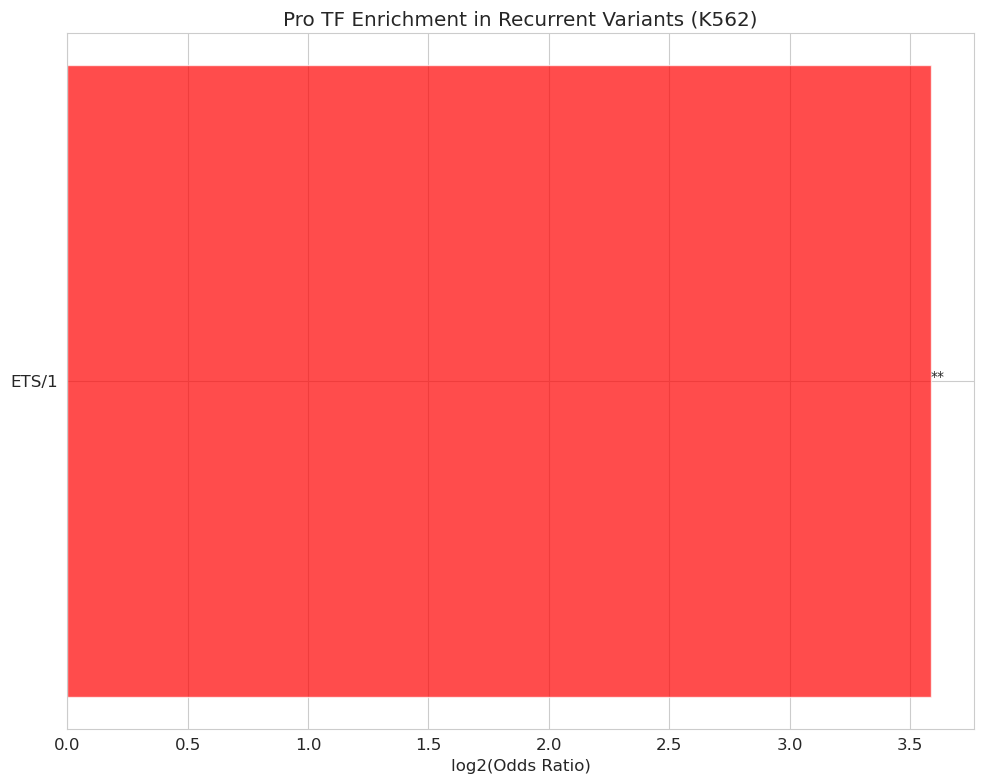

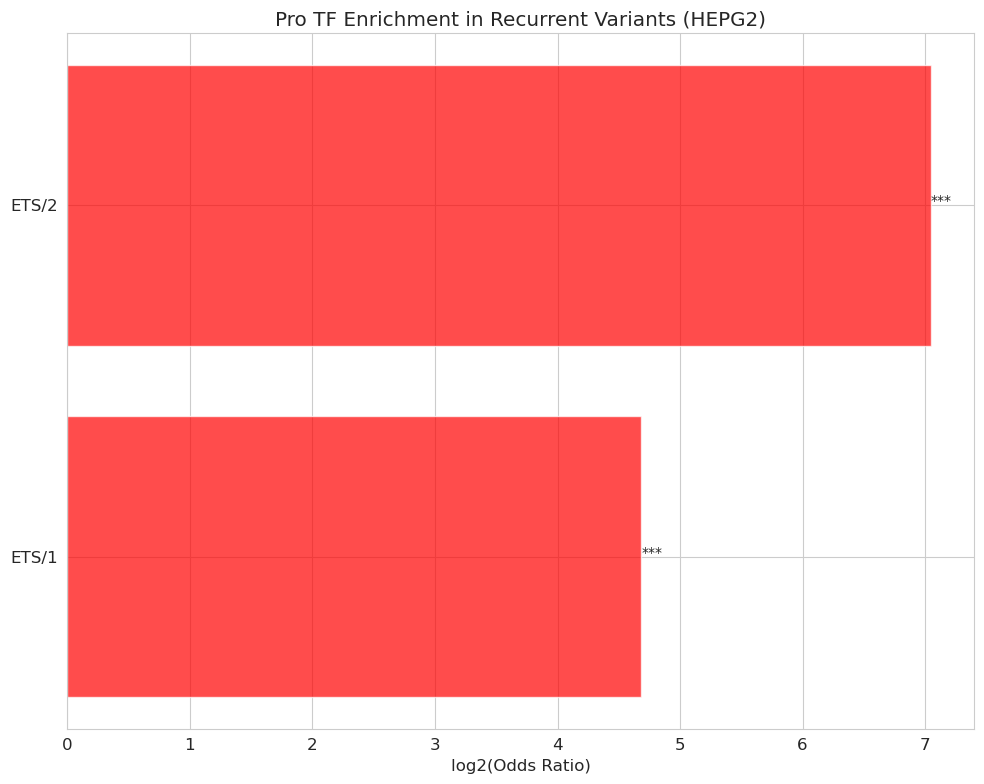

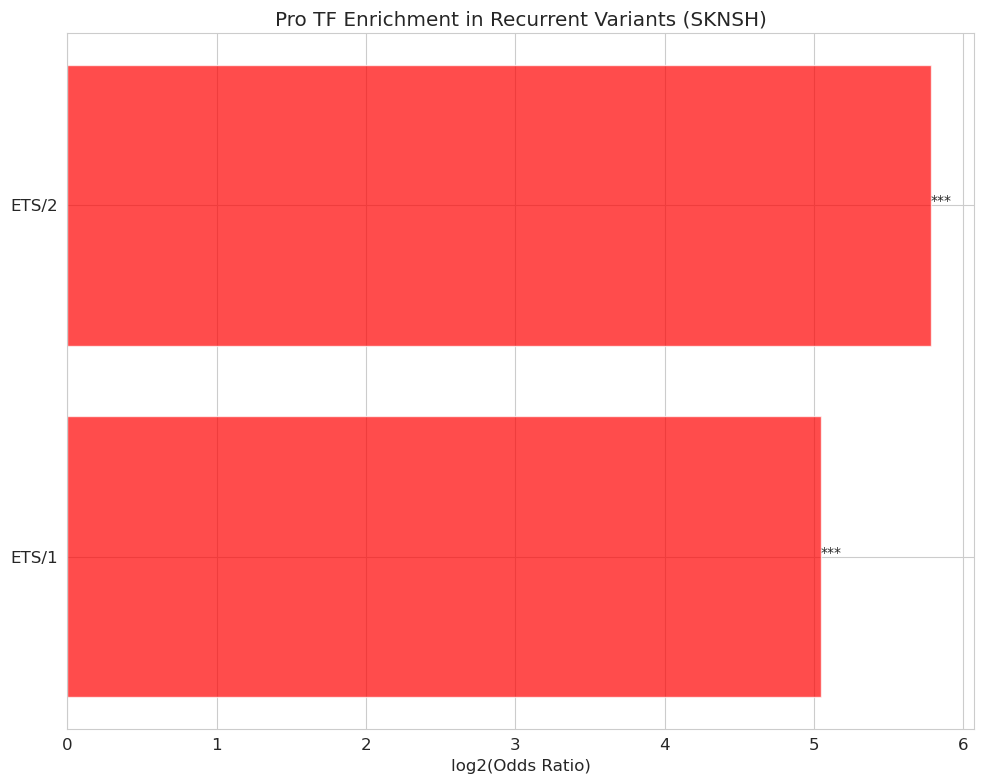

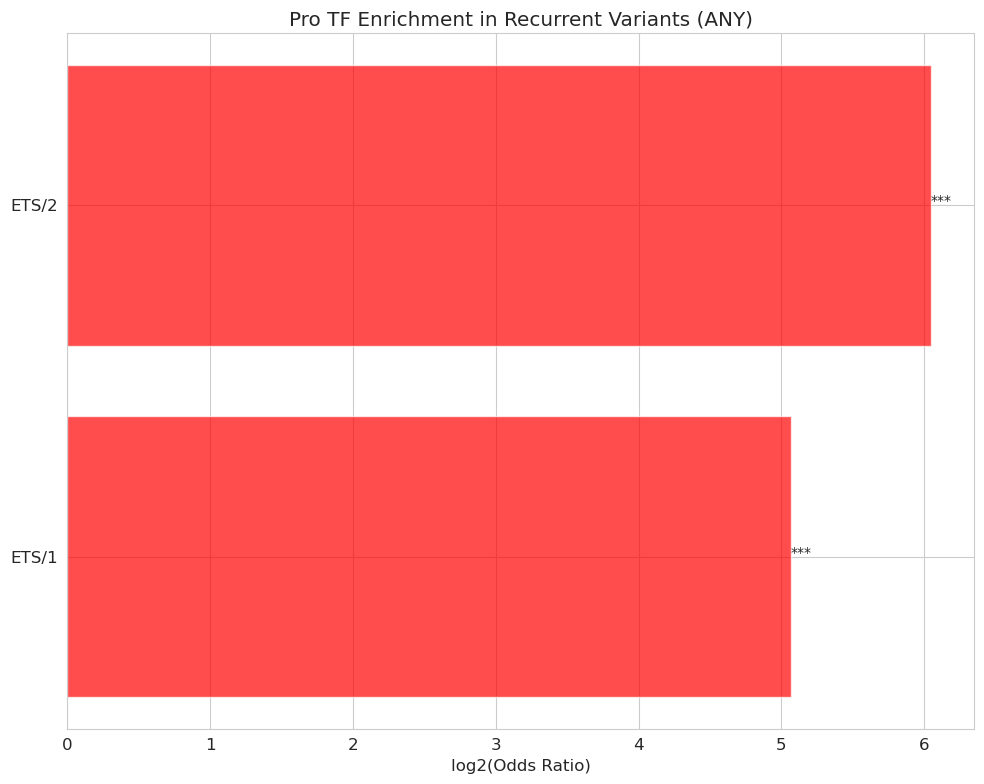

In [54]:
# Pro: visualize recurrent enrichments
for cell_type, result in pro_recurrent_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1],
            f'Pro TF Enrichment in Recurrent Variants ({cell_type.upper()})',
            max_display=20
        )
        plt.show()


### Pro Analysis 2: TF Enrichment in emVars

In [55]:
# Pro: TF enrichment in emVars - per cell type (matched TF and emVar cell type)
pro_emvar_results = {}

for cell_type in pro_tf_cols.keys():
    tf_col = pro_tf_cols[cell_type]
    emvar_col = emvar_cols[cell_type]

    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment(cosmic_df, tf_col, emvar_col, condition_val=1, min_count=3)
    pro_emvar_results[cell_type] = result
    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"Significant TFs (p_adj<0.1): {len(sig)}")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))

# any cell type
print("\n=== ANY CELL TYPE ===")
pro_emvar_any = fisher_exact_enrichment(cosmic_df, 'any_pro_tf_fam', 'emvar_any', condition_val=1, min_count=3)
pro_emvar_results['any'] = pro_emvar_any
if not pro_emvar_any.empty:
    sig = pro_emvar_any[pro_emvar_any['p_adj'] < 0.1]
    print(f"Significant TFs (p_adj<0.1): {len(sig)}")
    if not sig.empty:
        display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))



=== K562 ===
Significant TFs (p_adj<0.1): 6


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
4,ETS/1,inf,inf,3.121673e-27,14
0,KLF/SP/2,200.972375,7.650853,4.492235e-26,16
3,NRF1,307.612681,8.264971,1.611912e-12,7
5,Ebox/CACCTG,109.851477,6.779410,3.283569e-08,5
2,RFX/1,inf,inf,1.424965e-06,3
1,ETS/2,inf,inf,1.424965e-06,3



=== HEPG2 ===
Significant TFs (p_adj<0.1): 4


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
1,ETS/1,1012.713382,9.984010,3.002062e-33,17
3,NRF1,277.827322,8.118045,6.537517e-13,7
2,KLF/SP/2,178.592117,7.480525,9.095962e-11,6
0,ETS/2,inf,inf,4.817957e-09,4



=== SKNSH ===
Significant TFs (p_adj<0.1): 7


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
1,ETS/1,982.731715,9.940654,1.070110e-94,51
3,NRF1,480.741614,8.909118,3.035803e-18,10
0,ETS/2,769.109852,9.587046,2.629429e-15,8
2,Ebox/CACCTG,61.175806,5.934889,6.188716e-10,7
6,KLF/SP/2,384.477818,8.586757,7.807202e-08,4
5,Ebox/CACGTG/1,inf,inf,1.274152e-06,3
4,NR/7,288.343910,8.171647,4.334785e-06,3



=== ANY CELL TYPE ===
Significant TFs (p_adj<0.1): 7


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
0,ETS/1,770.394897,9.589454,7.069927e-68,41
2,KLF/SP/2,159.602336,7.318338,4.114037e-25,17
1,Ebox/CACCTG,56.320089,5.815578,6.293494e-14,11
5,NRF1,225.261427,7.815456,6.560825e-13,8
3,ETS/2,inf,inf,2.265424e-09,5
4,RFX/1,inf,inf,5.314357e-06,3
6,Ebox/CACGTG/1,inf,inf,5.314357e-06,3


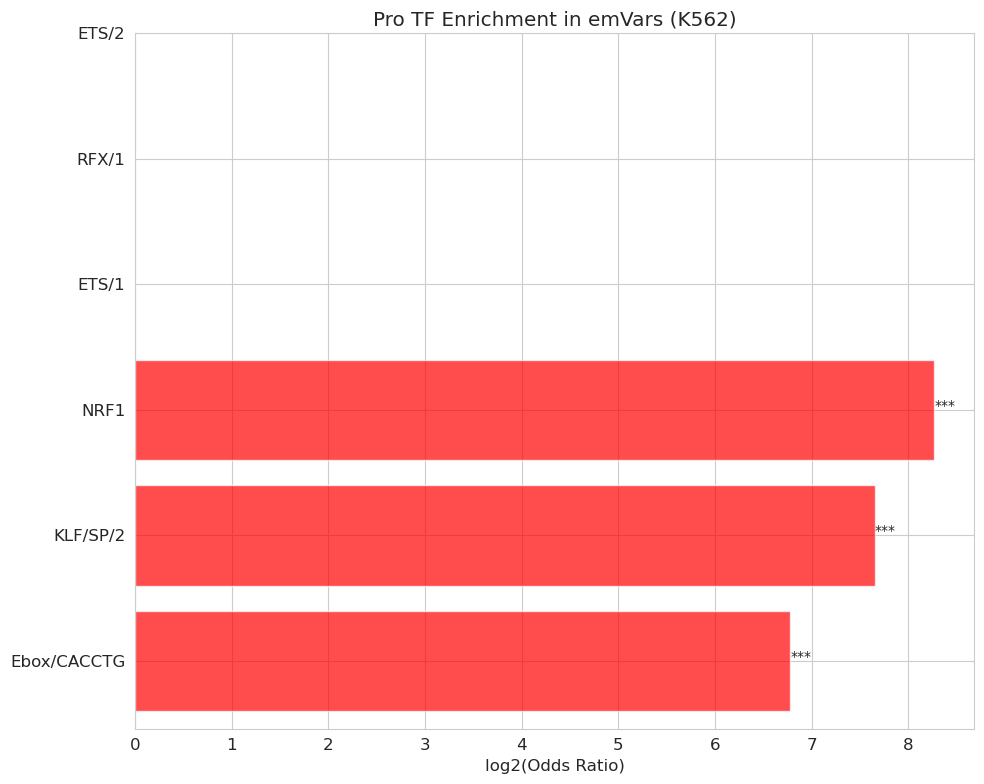

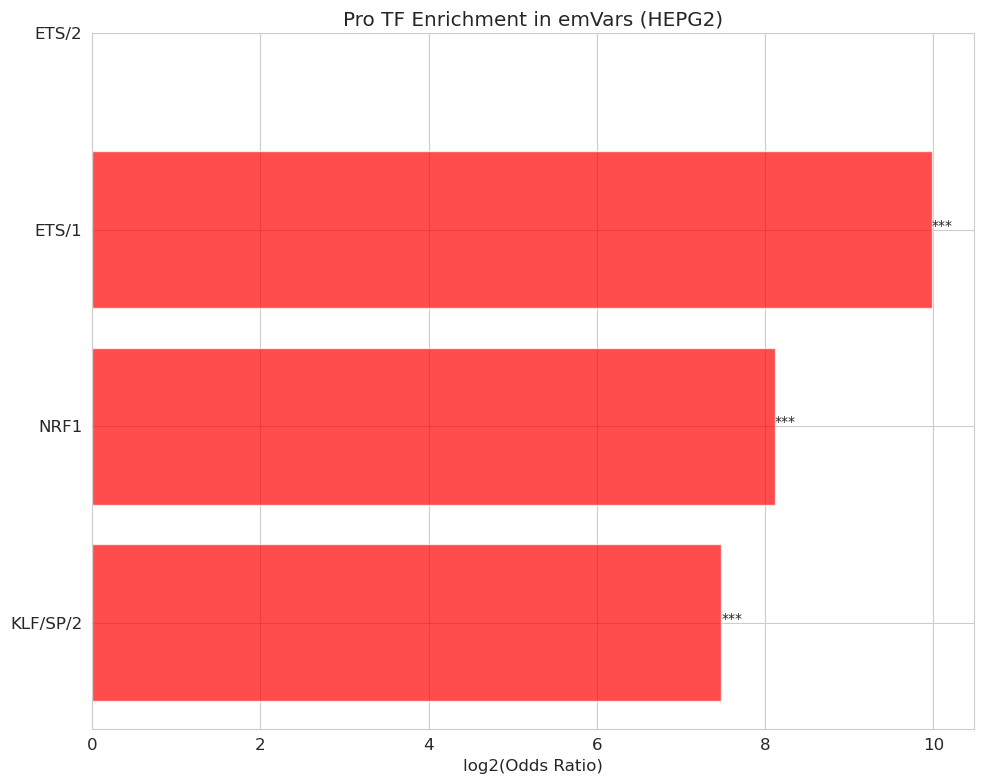

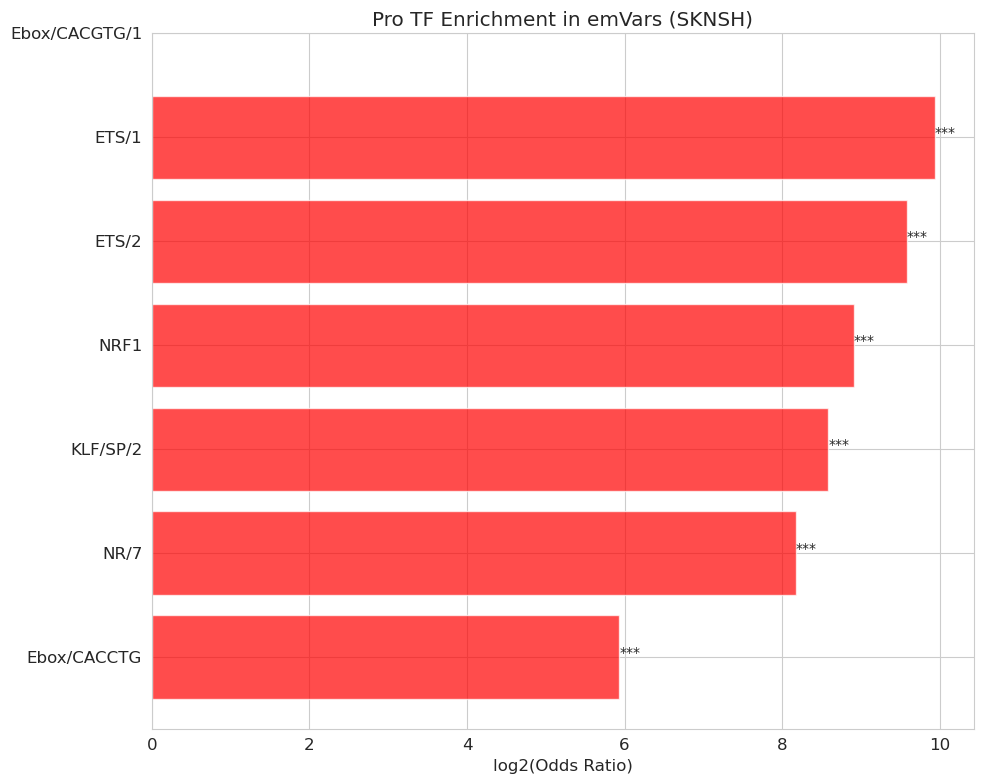

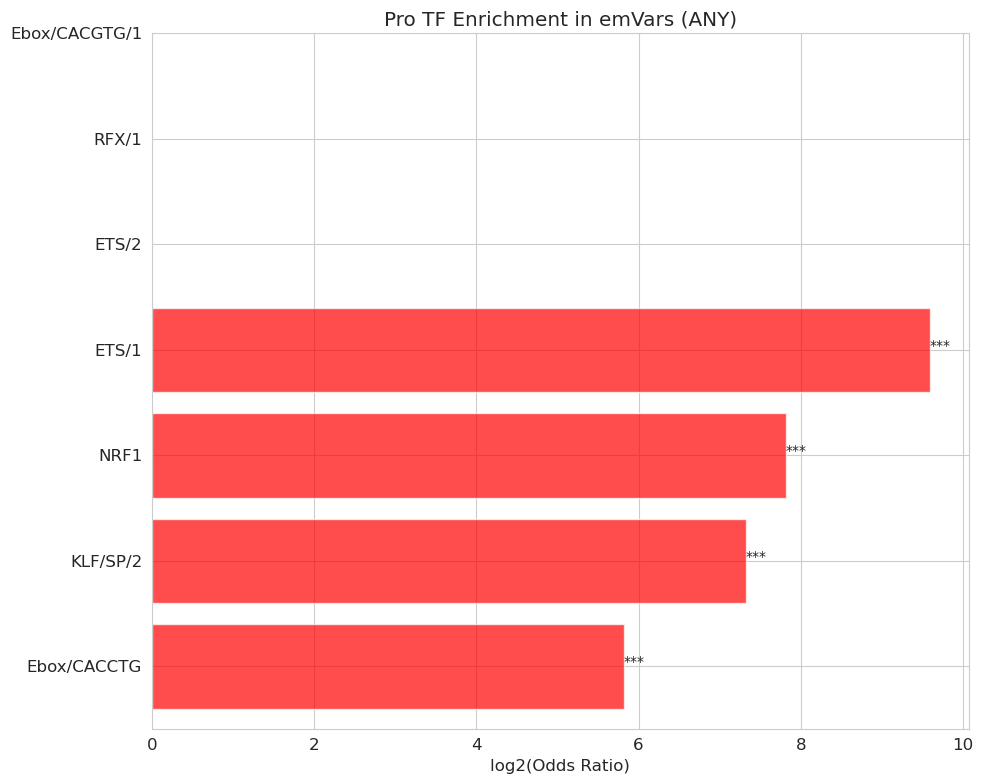

In [56]:
# Pro: visualize emVar enrichments
for cell_type, result in pro_emvar_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1],
            f'Pro TF Enrichment in emVars ({cell_type.upper()})',
            max_display=20
        )
        plt.show()


### Pro Analysis 3: TF Enrichment by Cancer Histology

In [57]:
# Pro: TF enrichment by histology - per cell type and any
pro_histology_results = {}

for histology in major_histologies:
    cosmic_major['is_histology'] = (cosmic_major['primary_histology'] == histology).astype(int)

    ct_results = {}
    for cell_type, tf_col in pro_tf_cols.items():
        result = fisher_exact_enrichment(cosmic_major, tf_col, 'is_histology', condition_val=1, min_count=3)
        ct_results[f'{cell_type}'] = result

    any_result = fisher_exact_enrichment(cosmic_major, 'any_pro_tf_fam', 'is_histology', condition_val=1, min_count=3)
    ct_results['any'] = any_result
    pro_histology_results[histology] = any_result  # use 'any' for heatmap

print("Pro histology analysis complete.")
for h, r in pro_histology_results.items():
    if not r.empty:
        n_sig = len(r[r['p_adj'] < 0.05])
        print(f"  {h}: {n_sig} sig TFs")


Pro histology analysis complete.
  carcinoma: 1 sig TFs
  malignant_melanoma: 4 sig TFs


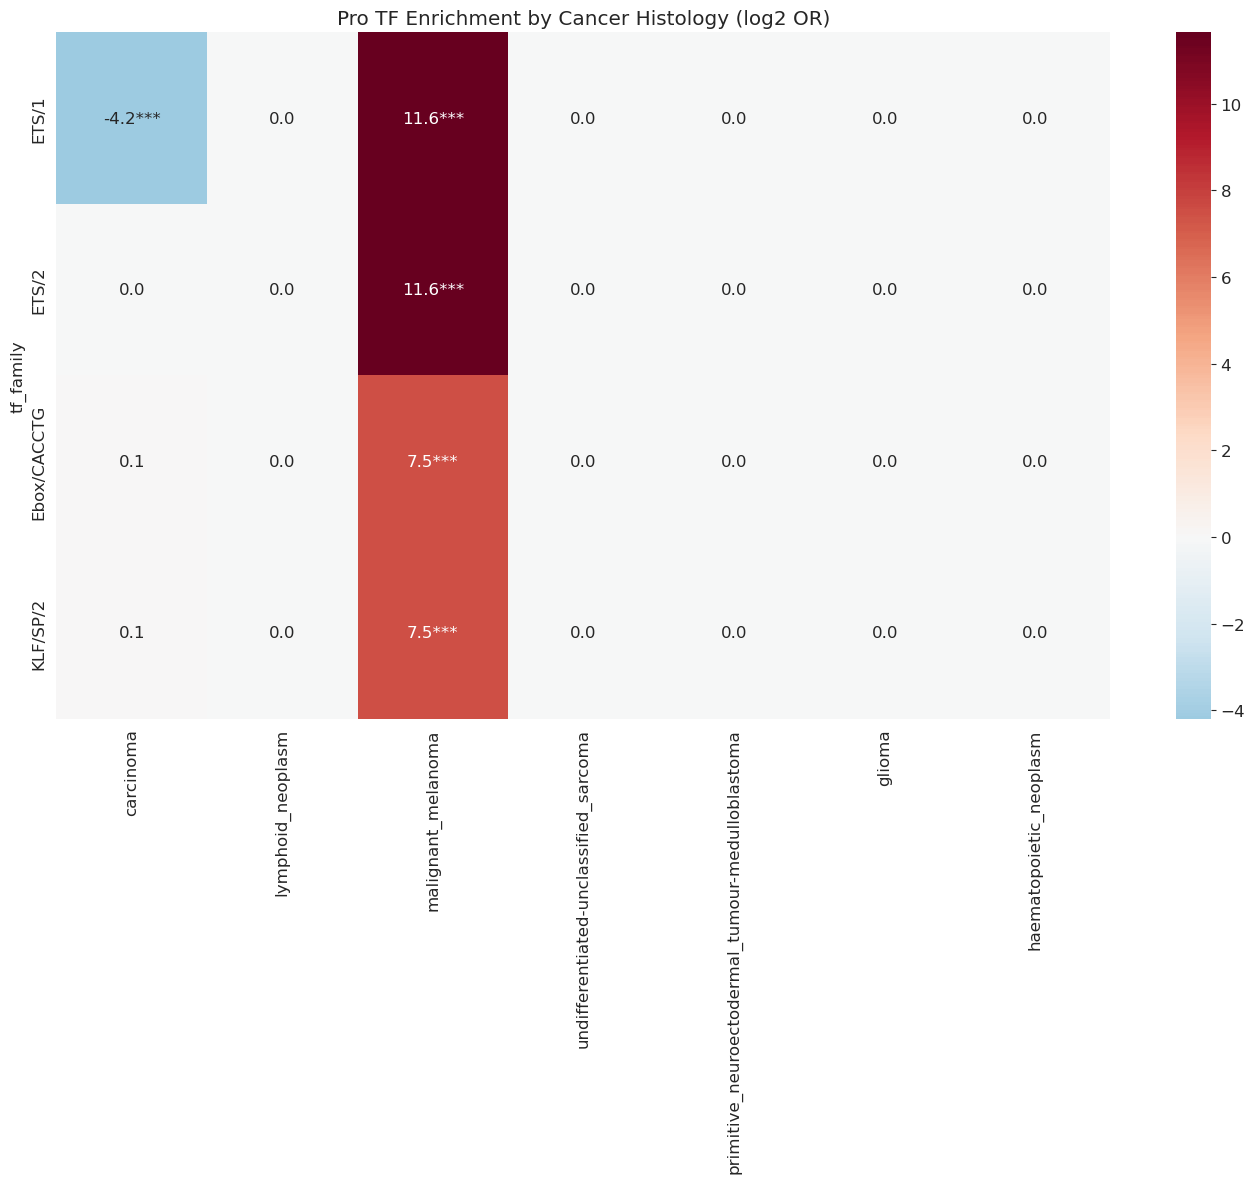

In [58]:
# Pro: heatmap of TF enrichments across histologies
fig = plot_enrichment_heatmap(
    pro_histology_results,
    'Pro TF Enrichment by Cancer Histology (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()


### Pro Analysis 3b: TF Enrichment in Recurrent Variants by Histology

  primitive_neuroectodermal_tumour-medulloblastoma: skipping (only 4 recurrent)


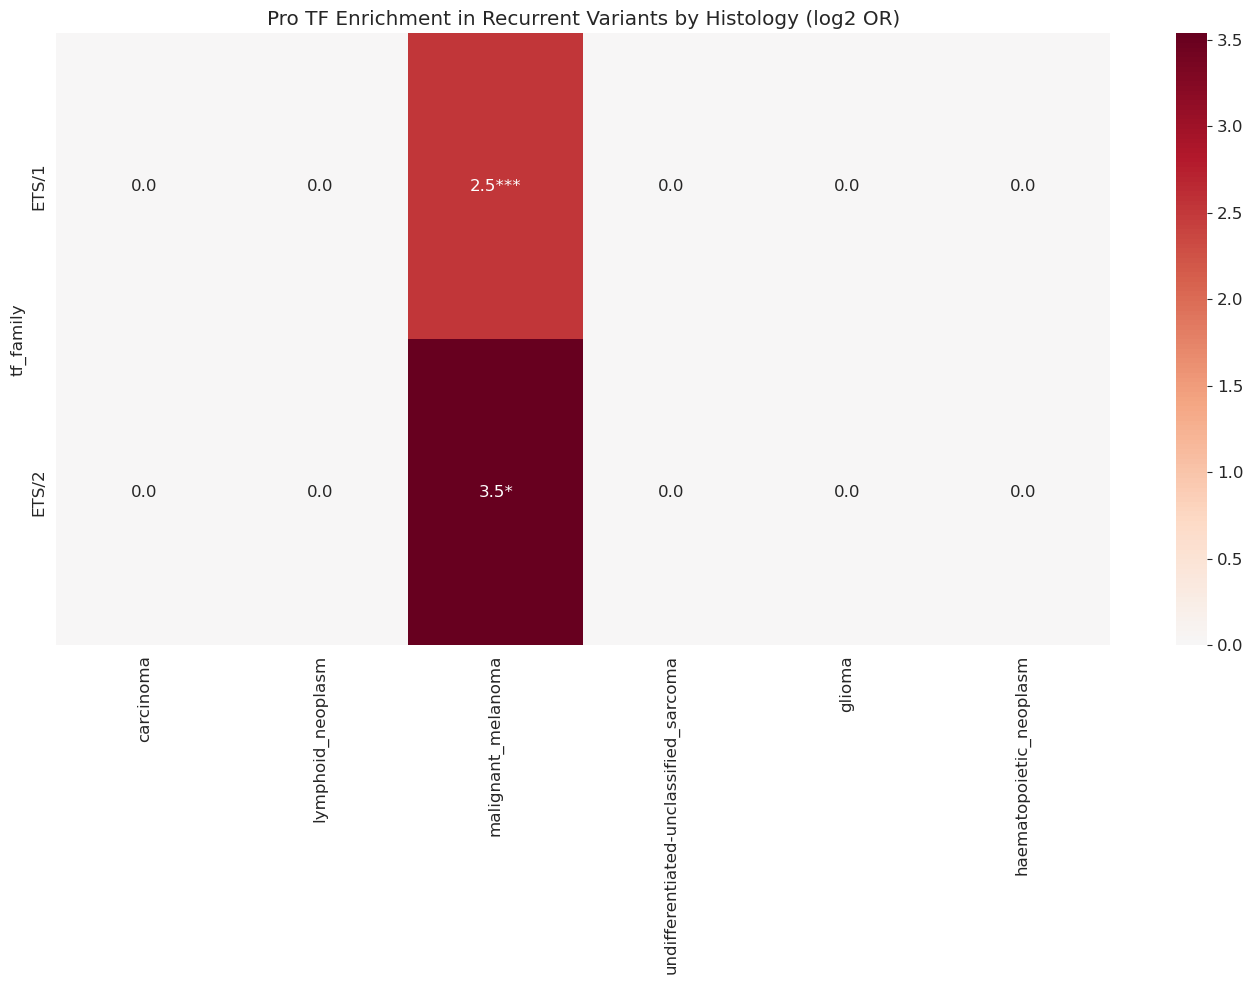

In [59]:
# Pro: TF enrichment in recurrent variants - stratified by histology
pro_recurrent_by_histology = {}

for histology in major_histologies:
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    n_total = len(hist_df)
    n_recurrent = hist_df['recurrent'].sum()

    if n_recurrent < 10:
        print(f"  {histology}: skipping (only {n_recurrent} recurrent)")
        continue

    result = fisher_exact_enrichment(hist_df, 'any_pro_tf_fam', 'recurrent', condition_val=1, min_count=3)
    pro_recurrent_by_histology[histology] = result

fig = plot_enrichment_heatmap(
    pro_recurrent_by_histology,
    'Pro TF Enrichment in Recurrent Variants by Histology (log2 OR)',
    figsize=(14, 10),
    show_significance=True
)
if fig:
    plt.show()


### Pro Analysis 4: Cell Type – Cancer Biology Connections

In [60]:
# Pro: cell type-specific TF disruptions in relevant cancer types
print("=== Pro: Cell Type - Cancer Biology Connections ===\n")

pro_cell_histology_pairs = [
    ('k562', 'lymphoid_neoplasm', 'K562 pro TFs in Lymphoid Neoplasm'),
    ('k562', 'haematopoietic_neoplasm', 'K562 pro TFs in Haematopoietic Neoplasm'),
    ('sknsh', 'primitive_neuroectodermal_tumour-medulloblastoma', 'SKNSH pro TFs in PNET/Medulloblastoma'),
    ('hepg2', 'carcinoma', 'HepG2 pro TFs in Carcinoma'),
]

pro_cell_hist_results = {}
for cell_type, histology, label in pro_cell_histology_pairs:
    tf_col = pro_tf_cols[cell_type]
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    other_df = cosmic_df[cosmic_df['primary_histology'] != histology].copy()
    combined = pd.concat([hist_df.assign(is_hist=1), other_df.assign(is_hist=0)])

    result = fisher_exact_enrichment(combined, tf_col, 'is_hist', condition_val=1, min_count=3)
    pro_cell_hist_results[label] = result

    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"{label}: {len(sig)} sig TFs")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj']].head(5))


=== Pro: Cell Type - Cancer Biology Connections ===

HepG2 pro TFs in Carcinoma: 1 sig TFs


,tf_family,odds_ratio,log2_or,p_adj
5,ETS/1,0.064081,-3.963963,0.000001


### Pro Analysis 5: TF Enrichment in Carcinoma Subtypes

Using the `cosmic_carcinoma` dataframe and subtype flags created in Analysis 5.


hepatocellular_carcinoma: 0 sig TFs
endometrioid_carcinoma: 1 sig TFs


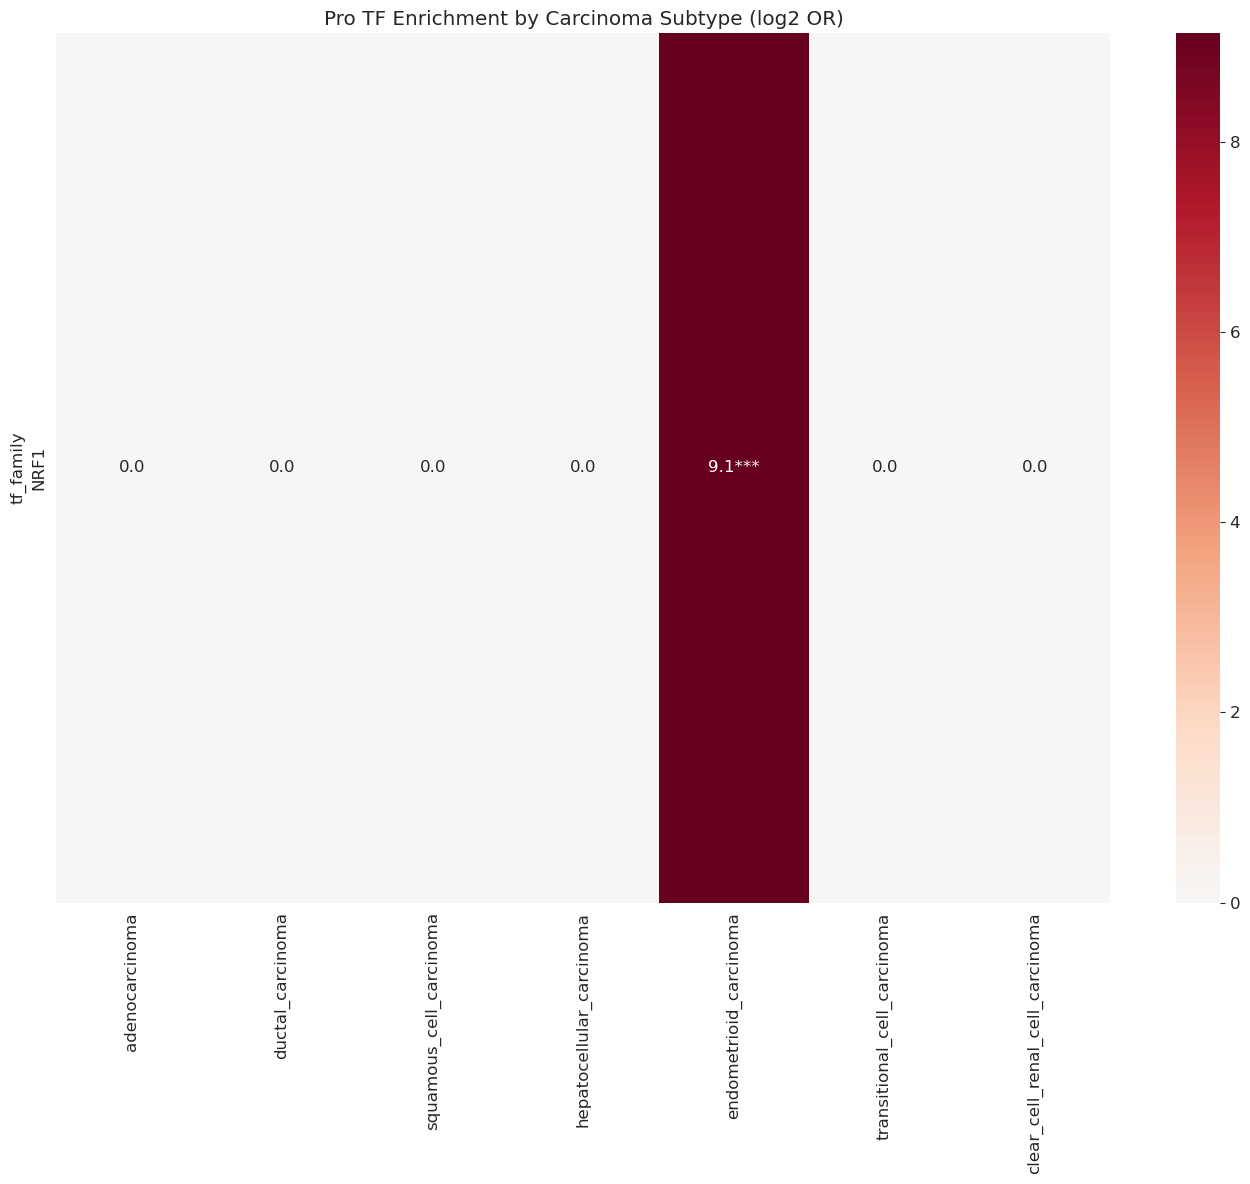

In [61]:
# Pro 5a: TF enrichment by carcinoma subtype
pro_carcinoma_subtype_results = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    n_variants = cosmic_carcinoma[col_name].sum()
    if n_variants < 100:
        continue

    result = fisher_exact_enrichment(cosmic_carcinoma, 'any_pro_tf_fam', col_name, condition_val=1, min_count=3)
    pro_carcinoma_subtype_results[subtype] = result
    if not result.empty:
        n_sig = len(result[result['p_adj'] < 0.05])
        print(f"{subtype}: {n_sig} sig TFs")

fig = plot_enrichment_heatmap(
    pro_carcinoma_subtype_results,
    'Pro TF Enrichment by Carcinoma Subtype (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()


In [62]:
# Pro 5b: TF enrichment in recurrent variants by carcinoma subtype
pro_recurrent_by_carcinoma = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    n_recurrent = subtype_df['recurrent'].sum()

    if len(subtype_df) < 100 or n_recurrent < 10:
        continue

    result = fisher_exact_enrichment(subtype_df, 'any_pro_tf_fam', 'recurrent', condition_val=1, min_count=3)
    pro_recurrent_by_carcinoma[subtype] = result
    if not result.empty:
        n_sig = len(result[result['p_adj'] < 0.05])
        print(f"{subtype}: {n_sig} sig TFs in recurrent variants")

fig = plot_enrichment_heatmap(
    pro_recurrent_by_carcinoma,
    'Pro TF Enrichment in Recurrent Variants by Carcinoma Subtype (log2 OR)',
    figsize=(14, 10)
)
if fig:
    plt.show()


No results to plot for: Pro TF Enrichment in Recurrent Variants by Carcinoma Subtype (log2 OR)


In [63]:
# Pro 5c: TF enrichment in emVars by carcinoma subtype
pro_emvar_by_carcinoma = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    n_emvar = subtype_df['emvar_any'].sum()

    if len(subtype_df) < 100 or n_emvar < 10:
        continue

    result = fisher_exact_enrichment(subtype_df, 'any_pro_tf_fam', 'emvar_any', condition_val=1, min_count=3)
    pro_emvar_by_carcinoma[subtype] = result
    if not result.empty:
        n_sig = len(result[result['p_adj'] < 0.05])
        print(f"{subtype}: {n_sig} sig TFs in emVars")

fig = plot_enrichment_heatmap(
    pro_emvar_by_carcinoma,
    'Pro TF Enrichment in emVars by Carcinoma Subtype (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()


No results to plot for: Pro TF Enrichment in emVars by Carcinoma Subtype (log2 OR)


---

## Combined (Enhancer + Promoter) Analyses

Analyses 1–5 using the **union of enhancer and promoter seqlet** TF calls.

For per-cell-type analyses: a variant is counted for TF_X if TF_X appears in **either** the dELS or promoter seqlet column for that cell type (`fisher_exact_enrichment_combined`).

For "any cell type" analyses: uses the `any_combined_tf_fam` column (first non-zero TF across all 6 columns).


### Combined Analysis 1: TF Enrichment in Recurrent vs Unique Variants

In [64]:
# Combined: TF enrichment in recurrent variants - per cell type
comb_recurrent_results = {}

for cell_type in tf_cols.keys():
    enh_col = tf_cols[cell_type]
    pro_col = pro_tf_cols[cell_type]
    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment_combined(cosmic_df, enh_col, pro_col, 'recurrent', condition_val=1, min_count=3)
    comb_recurrent_results[cell_type] = result
    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"Significant TFs (p_adj<0.1): {len(sig)}")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))

# any cell type
print("\n=== ANY CELL TYPE ===")
comb_recurrent_any = fisher_exact_enrichment(cosmic_df, 'any_combined_tf_fam', 'recurrent', condition_val=1, min_count=3)
comb_recurrent_results['any'] = comb_recurrent_any
if not comb_recurrent_any.empty:
    sig = comb_recurrent_any[comb_recurrent_any['p_adj'] < 0.1]
    print(f"Significant TFs (p_adj<0.1): {len(sig)}")
    if not sig.empty:
        display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))



=== K562 ===
Significant TFs (p_adj<0.1): 1


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
13,ZFX,6.77689,2.760623,0.075521,4



=== HEPG2 ===
Significant TFs (p_adj<0.1): 1


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
13,ETS/1,2.202762,1.139314,0.084815,16



=== SKNSH ===
Significant TFs (p_adj<0.1): 1


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
8,ETS/1,4.172423,2.060886,1.842197e-09,32



=== ANY CELL TYPE ===
Significant TFs (p_adj<0.1): 3


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
6,ETS/1,3.180018,1.669035,0.000009,28
23,ZFX,5.122141,2.356747,0.056369,5
0,CREB/ATF/3,1.898083,0.924543,0.092294,19


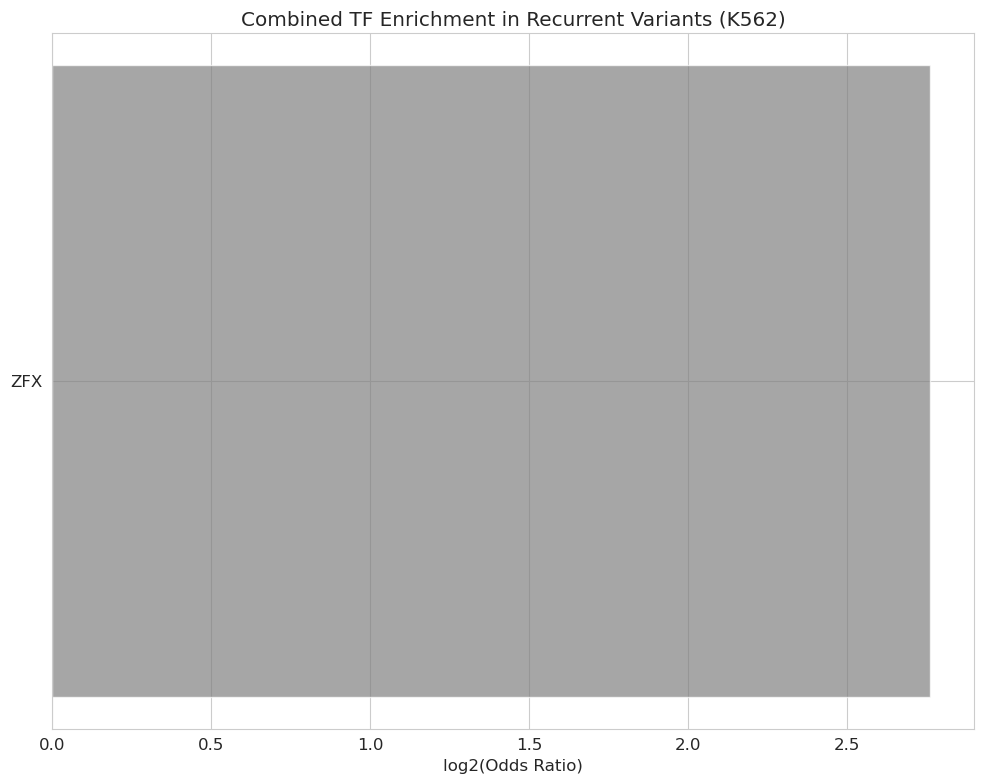

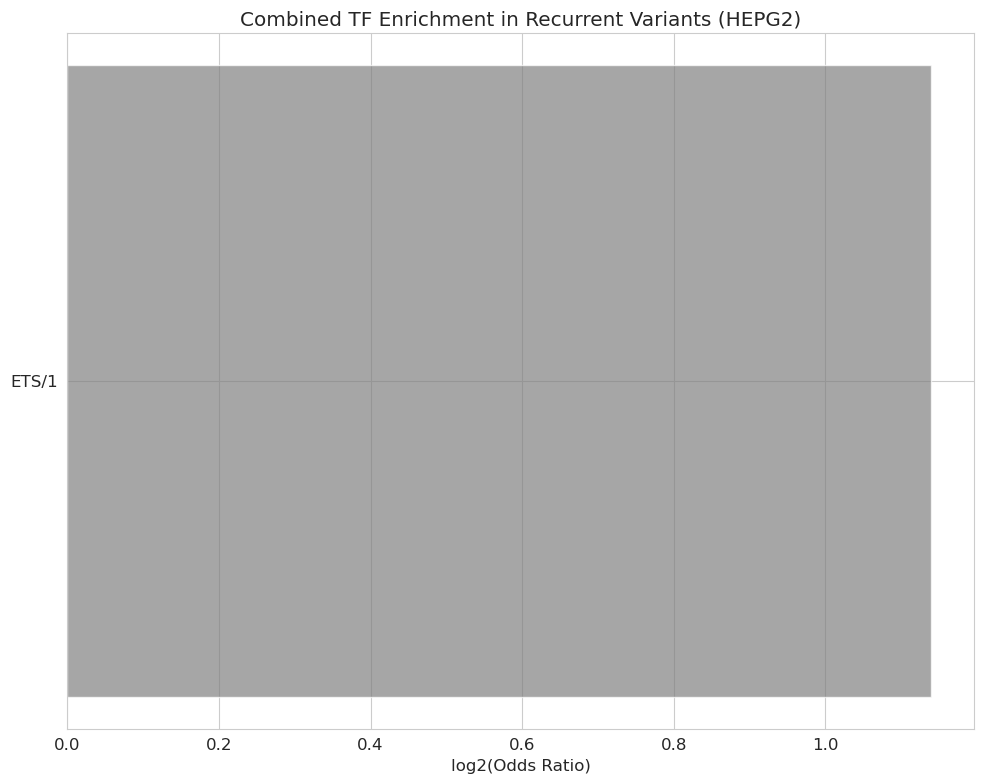

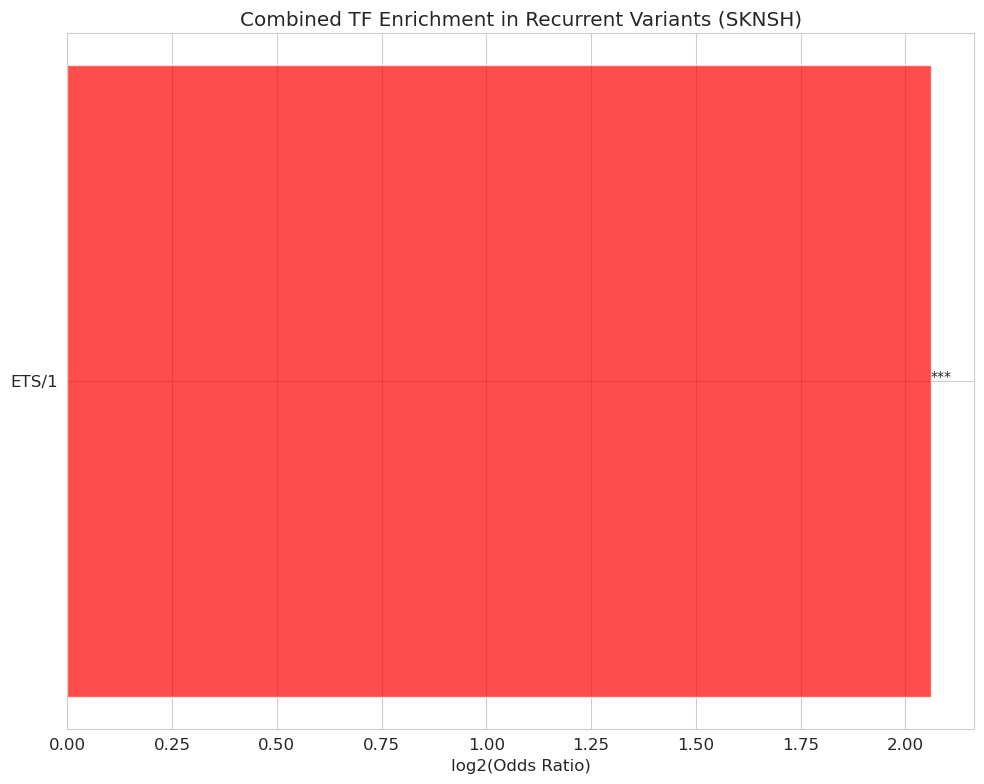

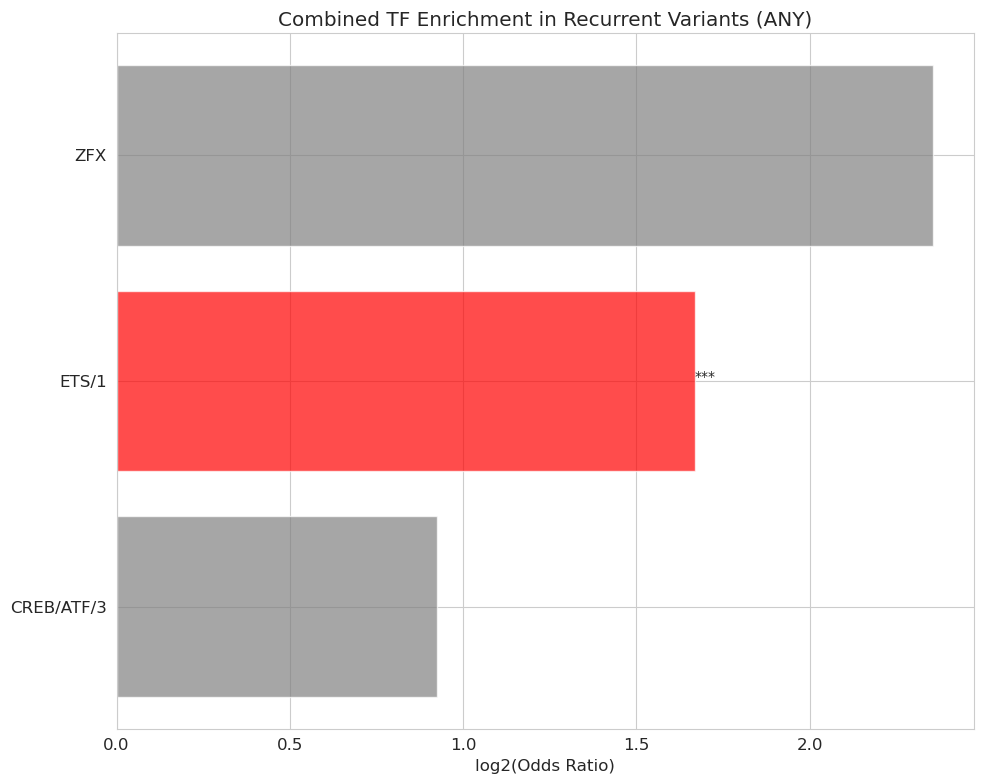

In [65]:
# Combined: visualize recurrent enrichments
for cell_type, result in comb_recurrent_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1],
            f'Combined TF Enrichment in Recurrent Variants ({cell_type.upper()})',
            max_display=20
        )
        plt.show()


### Combined Analysis 2: TF Enrichment in emVars

In [66]:
# Combined: TF enrichment in emVars - per cell type
comb_emvar_results = {}

for cell_type in tf_cols.keys():
    enh_col = tf_cols[cell_type]
    pro_col = pro_tf_cols[cell_type]
    emvar_col = emvar_cols[cell_type]
    print(f"\n=== {cell_type.upper()} ===")
    result = fisher_exact_enrichment_combined(cosmic_df, enh_col, pro_col, emvar_col, condition_val=1, min_count=3)
    comb_emvar_results[cell_type] = result
    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"Significant TFs (p_adj<0.1): {len(sig)}")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))

# any cell type
print("\n=== ANY CELL TYPE ===")
comb_emvar_any = fisher_exact_enrichment(cosmic_df, 'any_combined_tf_fam', 'emvar_any', condition_val=1, min_count=3)
comb_emvar_results['any'] = comb_emvar_any
if not comb_emvar_any.empty:
    sig = comb_emvar_any[comb_emvar_any['p_adj'] < 0.1]
    print(f"Significant TFs (p_adj<0.1): {len(sig)}")
    if not sig.empty:
        display(sig[['tf_family','odds_ratio','log2_or','p_adj','condition_with_tf']].head(10))



=== K562 ===
Significant TFs (p_adj<0.1): 76


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
23,KLF/SP/2,204.797483,7.678054,0.000000e+00,283
62,AP1/1,227.319611,7.828578,0.000000e+00,238
45,GATA,254.701983,7.992666,7.130148e-266,164
50,ETS/1,526.955990,9.041539,1.243384e-249,143
69,KLF/SP/1,340.045614,8.409584,1.437115e-174,104
52,Ebox/CACCTG,20.642842,4.367570,7.764184e-117,135
59,ETS/2,364.192466,8.508557,4.502526e-105,62
67,INSM1,41.826737,5.386354,2.684525e-93,83
20,Ebox/CACGTG/1,216.192310,7.756171,2.650670e-86,54
72,AP1/2,204.153466,7.673510,5.949453e-81,51



=== HEPG2 ===
Significant TFs (p_adj<0.1): 69


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
48,ETS/1,406.842660,8.668327,0.000000e+00,259
59,AP1/1,167.241915,7.385793,8.393788e-305,193
23,KLF/SP/2,175.451758,7.454931,3.710922e-258,162
19,Ebox/CACGTG/1,318.781296,8.316423,3.042629e-203,117
56,ETS/2,303.979187,8.247829,3.854401e-171,99
11,NRF1,376.369757,8.556007,7.204875e-112,63
39,CREB3/XBP1,125.849644,6.975557,3.511870e-89,59
10,NFY,85.096844,6.411034,2.133946e-79,57
4,YY1,47.940337,5.583168,2.384219e-68,57
32,CREB/ATF/1,172.327945,7.429013,1.053010e-62,39



=== SKNSH ===
Significant TFs (p_adj<0.1): 61


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
53,AP1/1,179.100854,7.484628,0.000000e+00,223
44,ETS/1,449.476408,8.812102,0.000000e+00,304
22,KLF/SP/2,186.728876,7.544801,1.820681e-284,181
50,ETS/2,334.913889,8.387646,4.063135e-229,135
19,Ebox/CACGTG/1,211.886168,7.727146,6.548472e-183,114
46,Ebox/CACCTG,14.344895,3.842465,1.232103e-165,227
11,NRF1,401.924657,8.650781,4.184051e-130,75
3,YY1,88.429278,6.466452,4.263965e-106,77
10,NFY,125.335348,6.969650,2.904070e-96,65
29,CREB/ATF/1,452.735185,8.822524,8.996459e-83,47



=== ANY CELL TYPE ===
Significant TFs (p_adj<0.1): 92


,tf_family,odds_ratio,log2_or,p_adj,condition_with_tf
11,AP1/1,118.799184,6.892381,0.000000e+00,388
14,KLF/SP/2,125.144497,6.967451,0.000000e+00,328
9,ETS/1,262.855645,8.038127,0.000000e+00,342
19,ETS/2,169.744731,7.407223,7.618714e-242,168
20,GATA,132.551043,7.050404,1.931593e-237,171
2,Ebox/CACCTG,11.242912,3.490944,9.800639e-216,346
25,Ebox/CACGTG/1,127.434126,6.993608,3.648548e-196,142
18,KLF/SP/1,200.430436,7.646958,3.269508e-162,110
77,NRF1,193.445551,7.595784,6.293478e-106,72
52,YY1,28.503661,4.833075,1.674259e-102,107


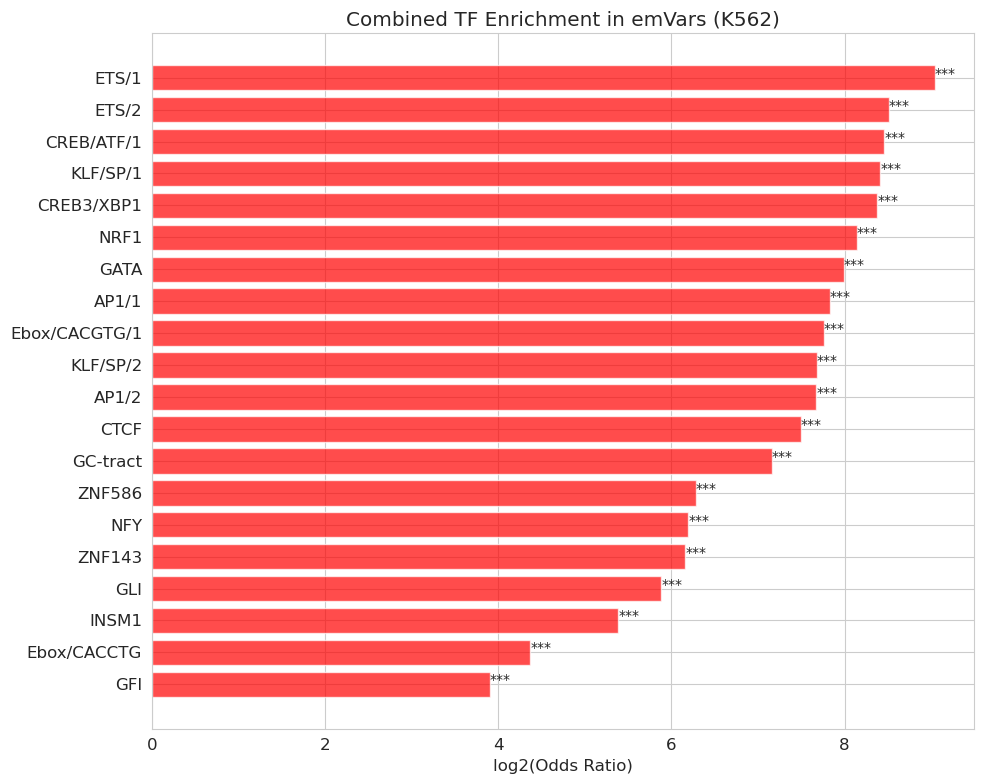

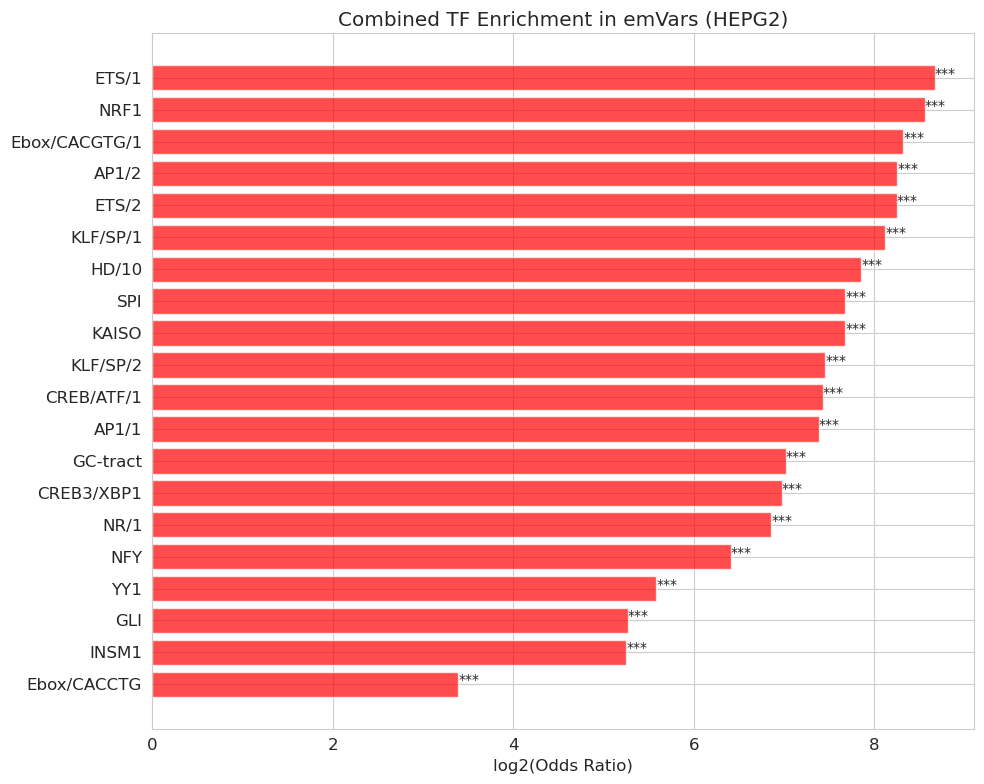

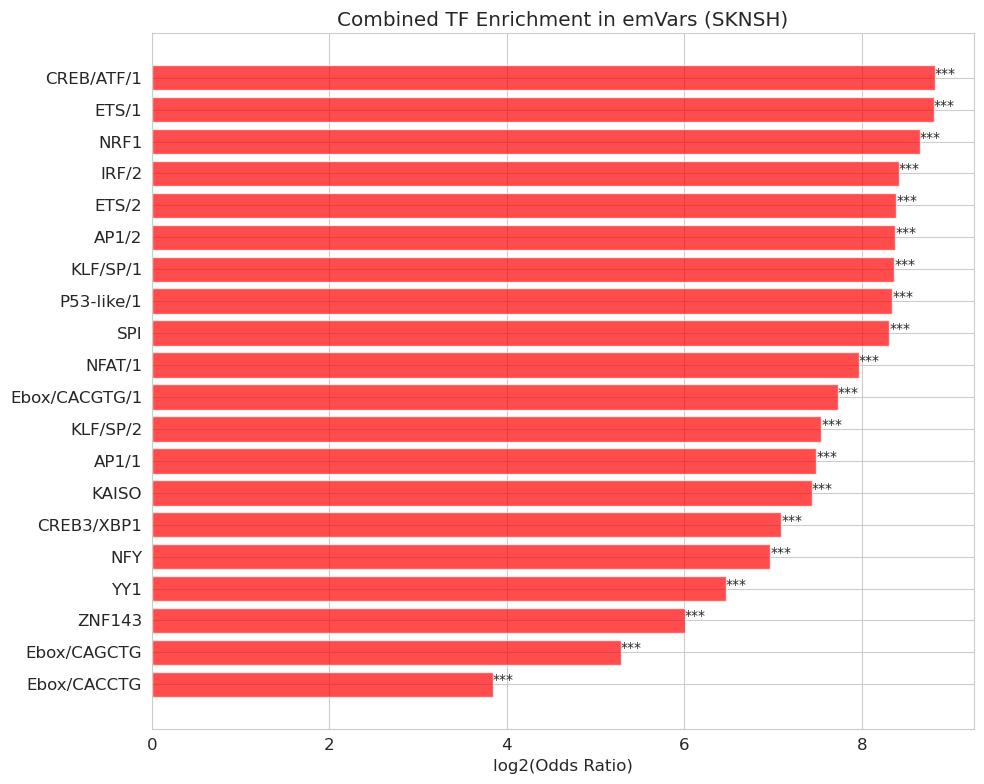

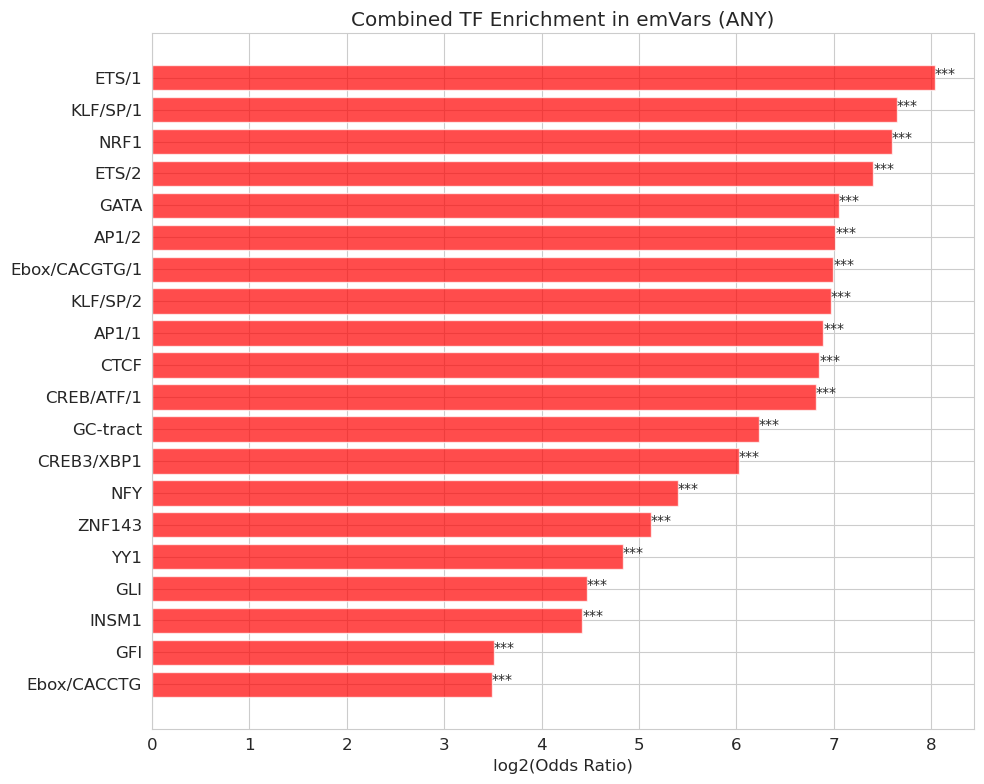

In [67]:
# Combined: visualize emVar enrichments
for cell_type, result in comb_emvar_results.items():
    if not result.empty and len(result[result['p_adj'] < 0.1]) > 0:
        fig = plot_enrichment_forest(
            result[result['p_adj'] < 0.1],
            f'Combined TF Enrichment in emVars ({cell_type.upper()})',
            max_display=20
        )
        plt.show()


### Combined Analysis 3: TF Enrichment by Cancer Histology

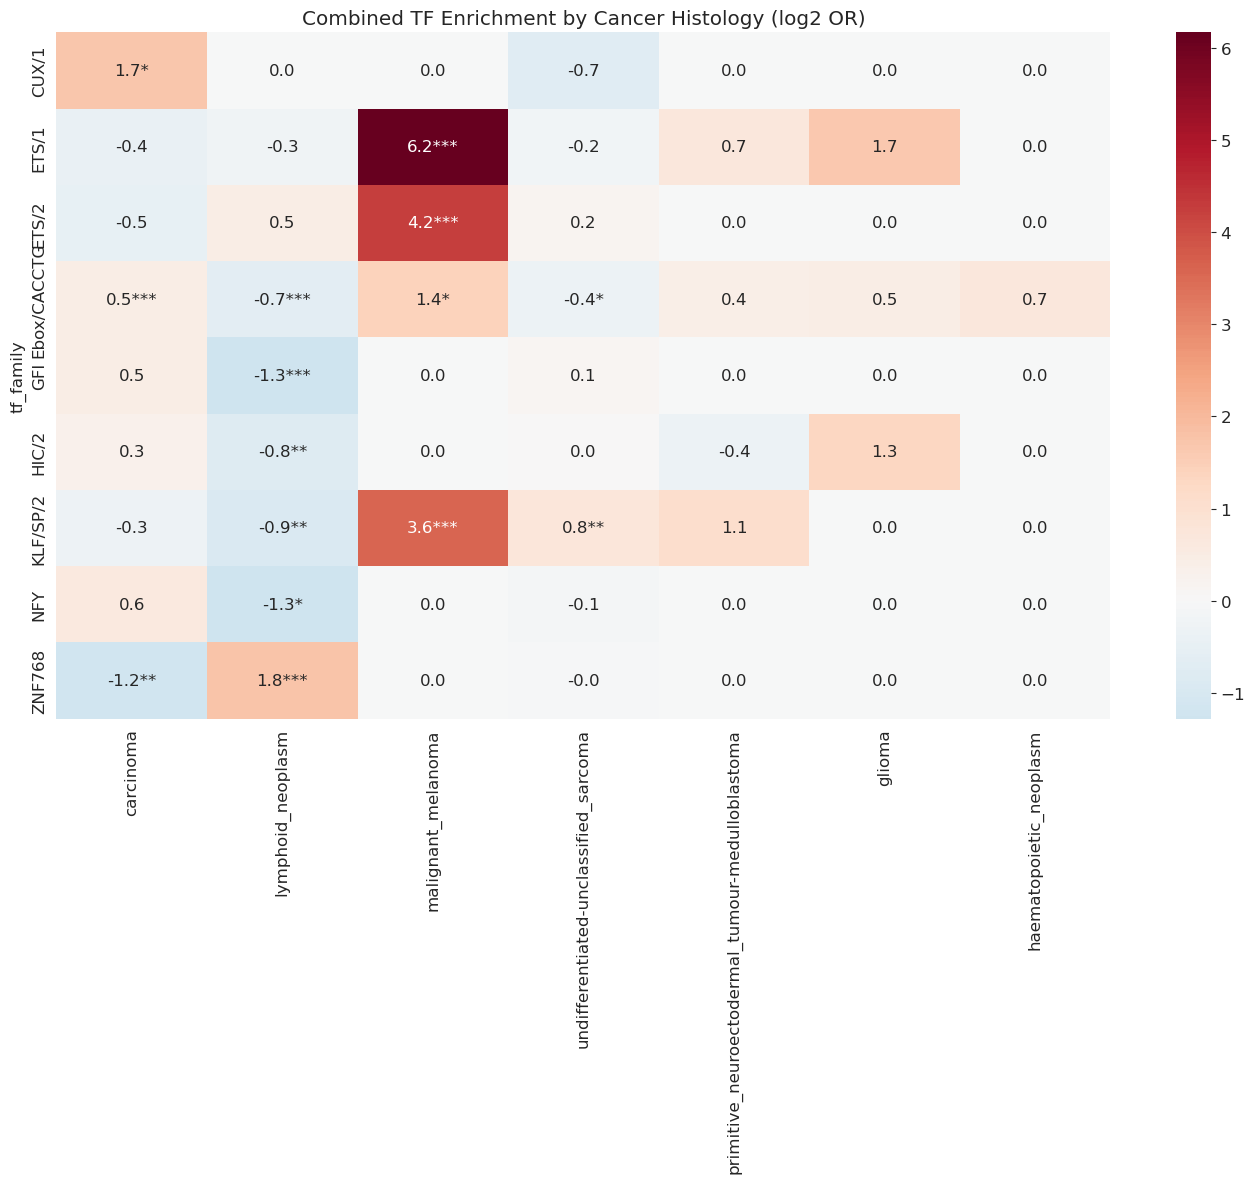

In [68]:
# Combined: TF enrichment by histology - using combined any_combined_tf_fam
comb_histology_results = {}

for histology in major_histologies:
    cosmic_major['is_histology'] = (cosmic_major['primary_histology'] == histology).astype(int)
    result = fisher_exact_enrichment(cosmic_major, 'any_combined_tf_fam', 'is_histology', condition_val=1, min_count=3)
    comb_histology_results[histology] = result

fig = plot_enrichment_heatmap(
    comb_histology_results,
    'Combined TF Enrichment by Cancer Histology (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()


### Combined Analysis 3b: TF Enrichment in Recurrent Variants by Histology

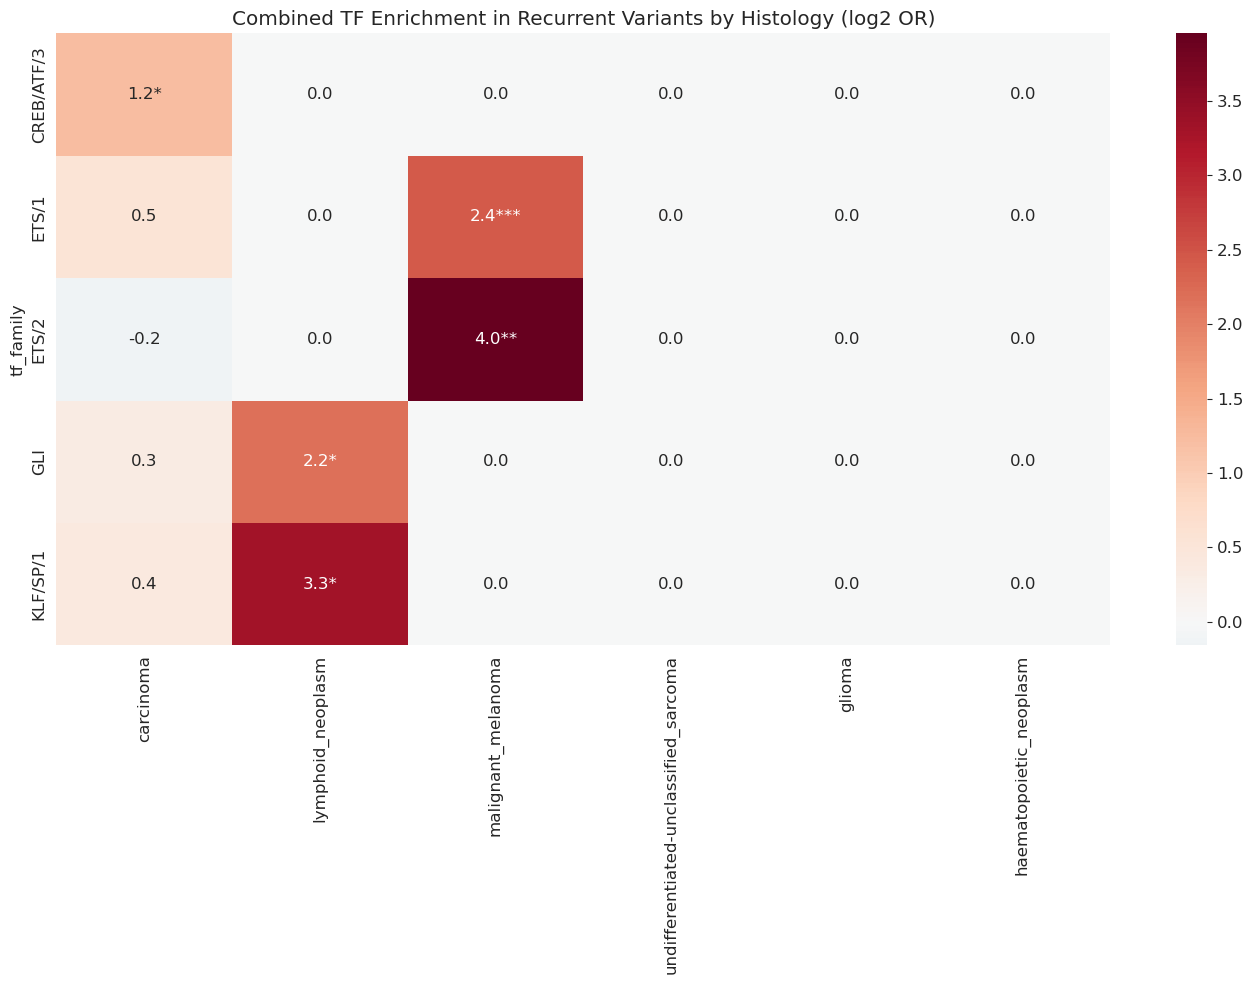

In [69]:
# Combined: recurrent TF enrichment stratified by histology
comb_recurrent_by_histology = {}

for histology in major_histologies:
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    if hist_df['recurrent'].sum() < 10:
        continue
    result = fisher_exact_enrichment(hist_df, 'any_combined_tf_fam', 'recurrent', condition_val=1, min_count=3)
    comb_recurrent_by_histology[histology] = result

fig = plot_enrichment_heatmap(
    comb_recurrent_by_histology,
    'Combined TF Enrichment in Recurrent Variants by Histology (log2 OR)',
    figsize=(14, 10),
    show_significance=True
)
if fig:
    plt.show()


### Combined Analysis 4: Cell Type – Cancer Biology Connections

In [70]:
# Combined: cell type-specific TF disruptions (enh OR pro) in relevant cancer types
print("=== Combined: Cell Type - Cancer Biology Connections ===\n")

comb_cell_hist_results = {}
for cell_type, histology, label in pro_cell_histology_pairs:
    enh_col = tf_cols[cell_type]
    pro_col = pro_tf_cols[cell_type]
    hist_df = cosmic_df[cosmic_df['primary_histology'] == histology].copy()
    other_df = cosmic_df[cosmic_df['primary_histology'] != histology].copy()
    combined = pd.concat([hist_df.assign(is_hist=1), other_df.assign(is_hist=0)])

    result = fisher_exact_enrichment_combined(combined, enh_col, pro_col, 'is_hist', condition_val=1, min_count=3)
    comb_cell_hist_results[label.replace('pro', 'combined')] = result

    if not result.empty:
        sig = result[result['p_adj'] < 0.1]
        print(f"{label}: {len(sig)} sig TFs")
        if not sig.empty:
            display(sig[['tf_family','odds_ratio','log2_or','p_adj']].head(5))


=== Combined: Cell Type - Cancer Biology Connections ===

K562 pro TFs in Lymphoid Neoplasm: 4 sig TFs


,tf_family,odds_ratio,log2_or,p_adj
16,GFI,0.424181,-1.237249,0.000747
10,ZNF768,3.342646,1.740990,0.014710
14,HIC/2,0.605995,-0.722621,0.060748
12,KLF/SP/2,0.580486,-0.784668,0.060748


SKNSH pro TFs in PNET/Medulloblastoma: 1 sig TFs


,tf_family,odds_ratio,log2_or,p_adj
0,KLF/SP/2,3.704464,1.889265,0.013406


HepG2 pro TFs in Carcinoma: 3 sig TFs


,tf_family,odds_ratio,log2_or,p_adj
32,ZNF768,0.371915,-1.426954,0.005312
73,Ebox/CACCTG,1.392496,0.477673,0.011765
2,CUX/1,4.033067,2.011877,0.016398


### Combined Analysis 5: TF Enrichment in Carcinoma Subtypes

adenocarcinoma: 0 sig TFs
ductal_carcinoma: 2 sig TFs
hepatocellular_carcinoma: 5 sig TFs
endometrioid_carcinoma: 2 sig TFs
transitional_cell_carcinoma: 7 sig TFs


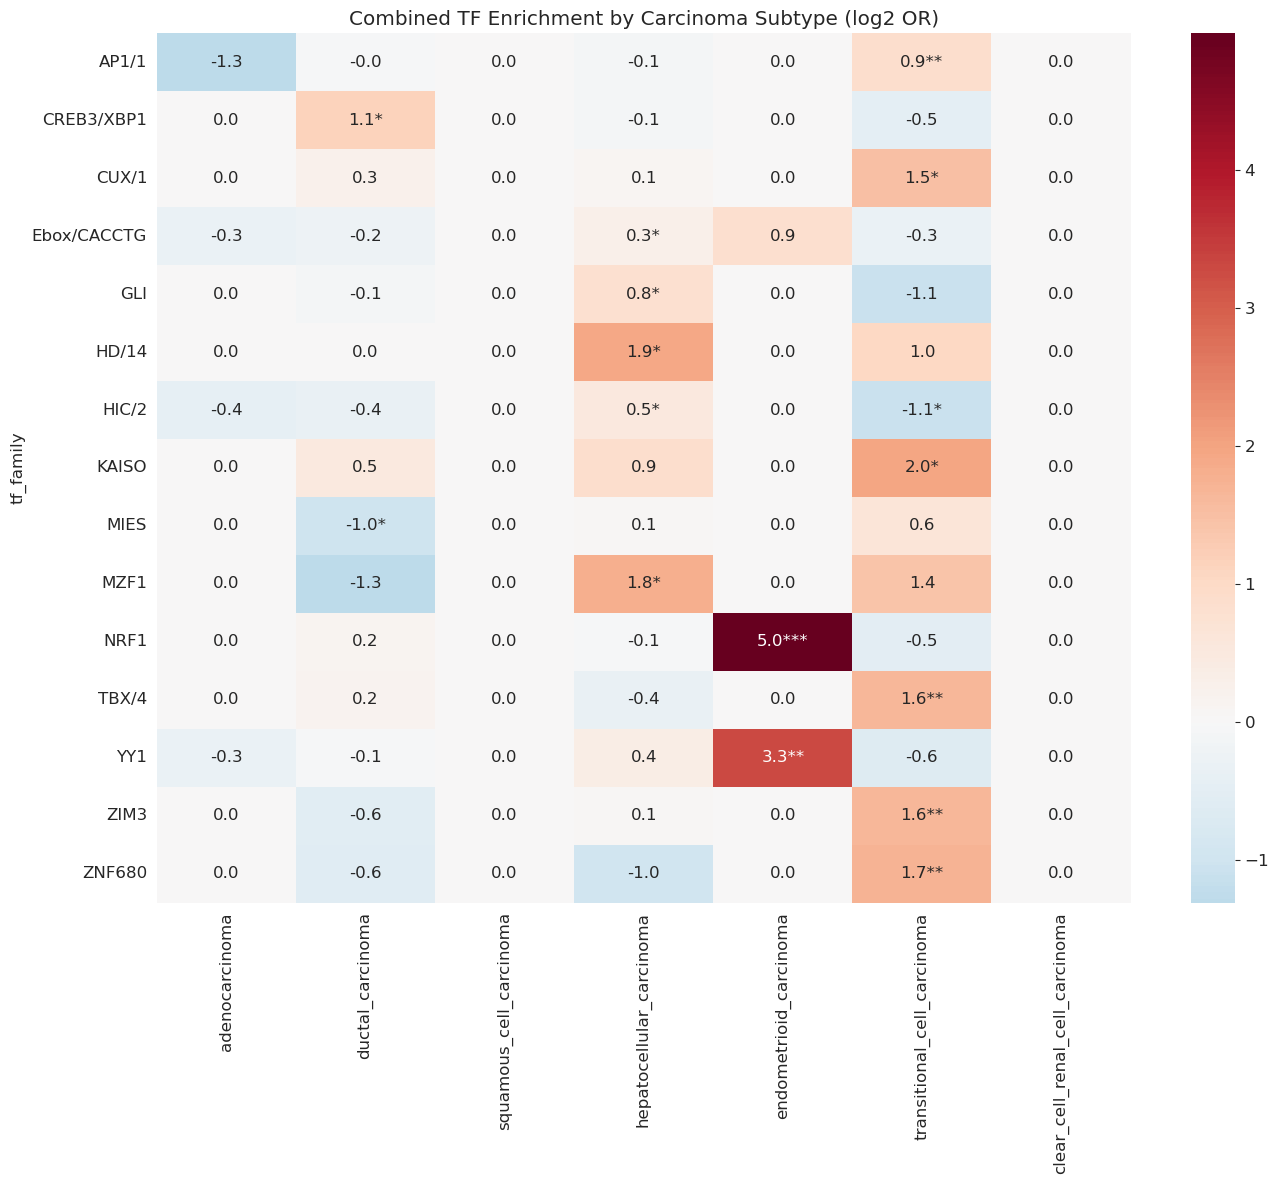

In [71]:
# Combined 5a: TF enrichment by carcinoma subtype
comb_carcinoma_subtype_results = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    if cosmic_carcinoma[col_name].sum() < 100:
        continue
    result = fisher_exact_enrichment(cosmic_carcinoma, 'any_combined_tf_fam', col_name, condition_val=1, min_count=3)
    comb_carcinoma_subtype_results[subtype] = result
    if not result.empty:
        print(f"{subtype}: {len(result[result['p_adj'] < 0.05])} sig TFs")

fig = plot_enrichment_heatmap(
    comb_carcinoma_subtype_results,
    'Combined TF Enrichment by Carcinoma Subtype (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()


ductal_carcinoma: 0 sig TFs in recurrent variants
hepatocellular_carcinoma: 2 sig TFs in recurrent variants
transitional_cell_carcinoma: 0 sig TFs in recurrent variants


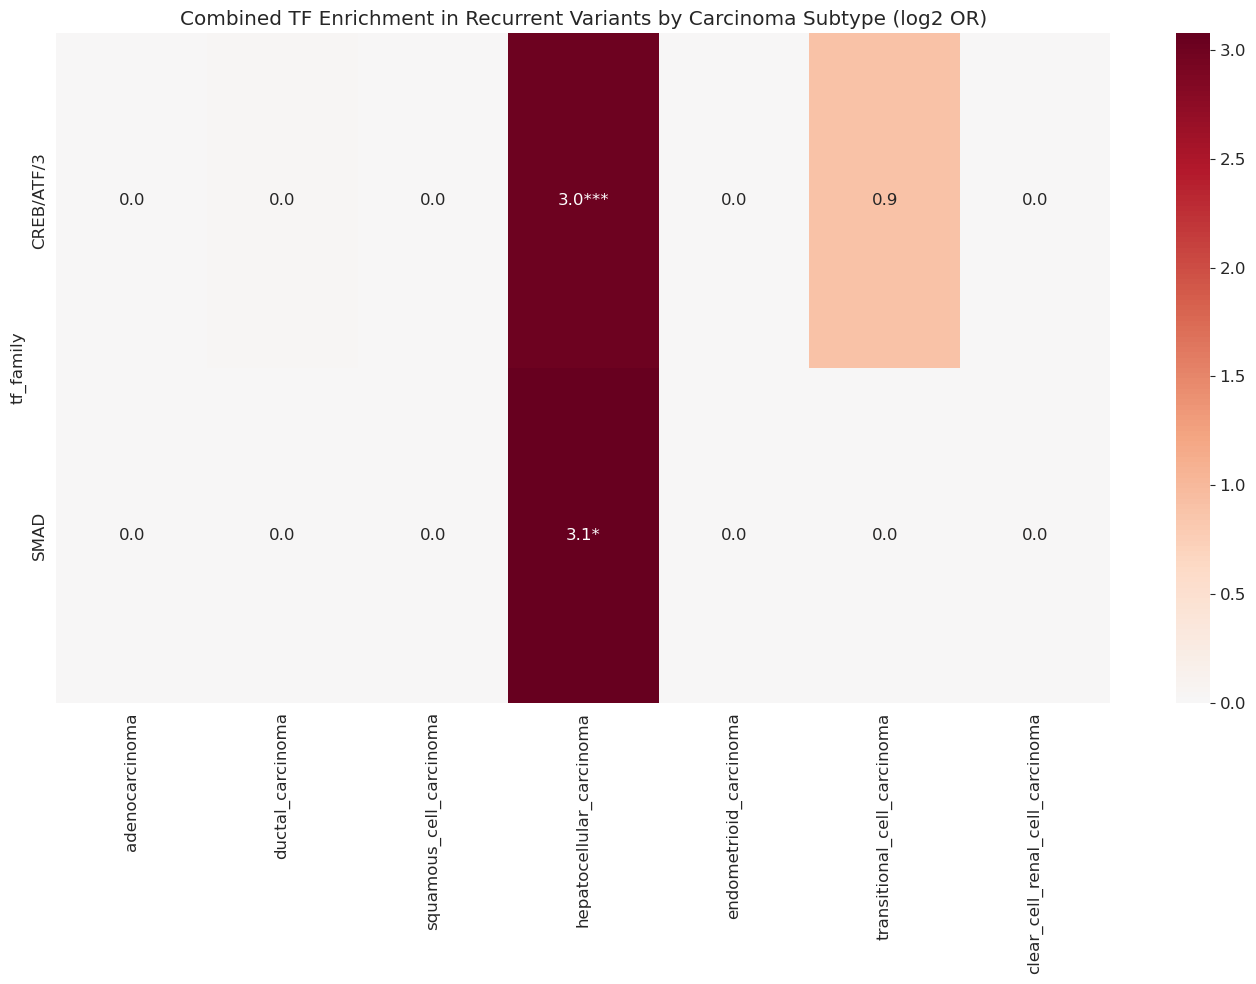

In [72]:
# Combined 5b: TF enrichment in recurrent variants by carcinoma subtype
comb_recurrent_by_carcinoma = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    if len(subtype_df) < 100 or subtype_df['recurrent'].sum() < 10:
        continue
    result = fisher_exact_enrichment(subtype_df, 'any_combined_tf_fam', 'recurrent', condition_val=1, min_count=3)
    comb_recurrent_by_carcinoma[subtype] = result
    if not result.empty:
        print(f"{subtype}: {len(result[result['p_adj'] < 0.05])} sig TFs in recurrent variants")

fig = plot_enrichment_heatmap(
    comb_recurrent_by_carcinoma,
    'Combined TF Enrichment in Recurrent Variants by Carcinoma Subtype (log2 OR)',
    figsize=(14, 10)
)
if fig:
    plt.show()


adenocarcinoma: 5 sig TFs in emVars
ductal_carcinoma: 49 sig TFs in emVars
hepatocellular_carcinoma: 45 sig TFs in emVars
transitional_cell_carcinoma: 24 sig TFs in emVars


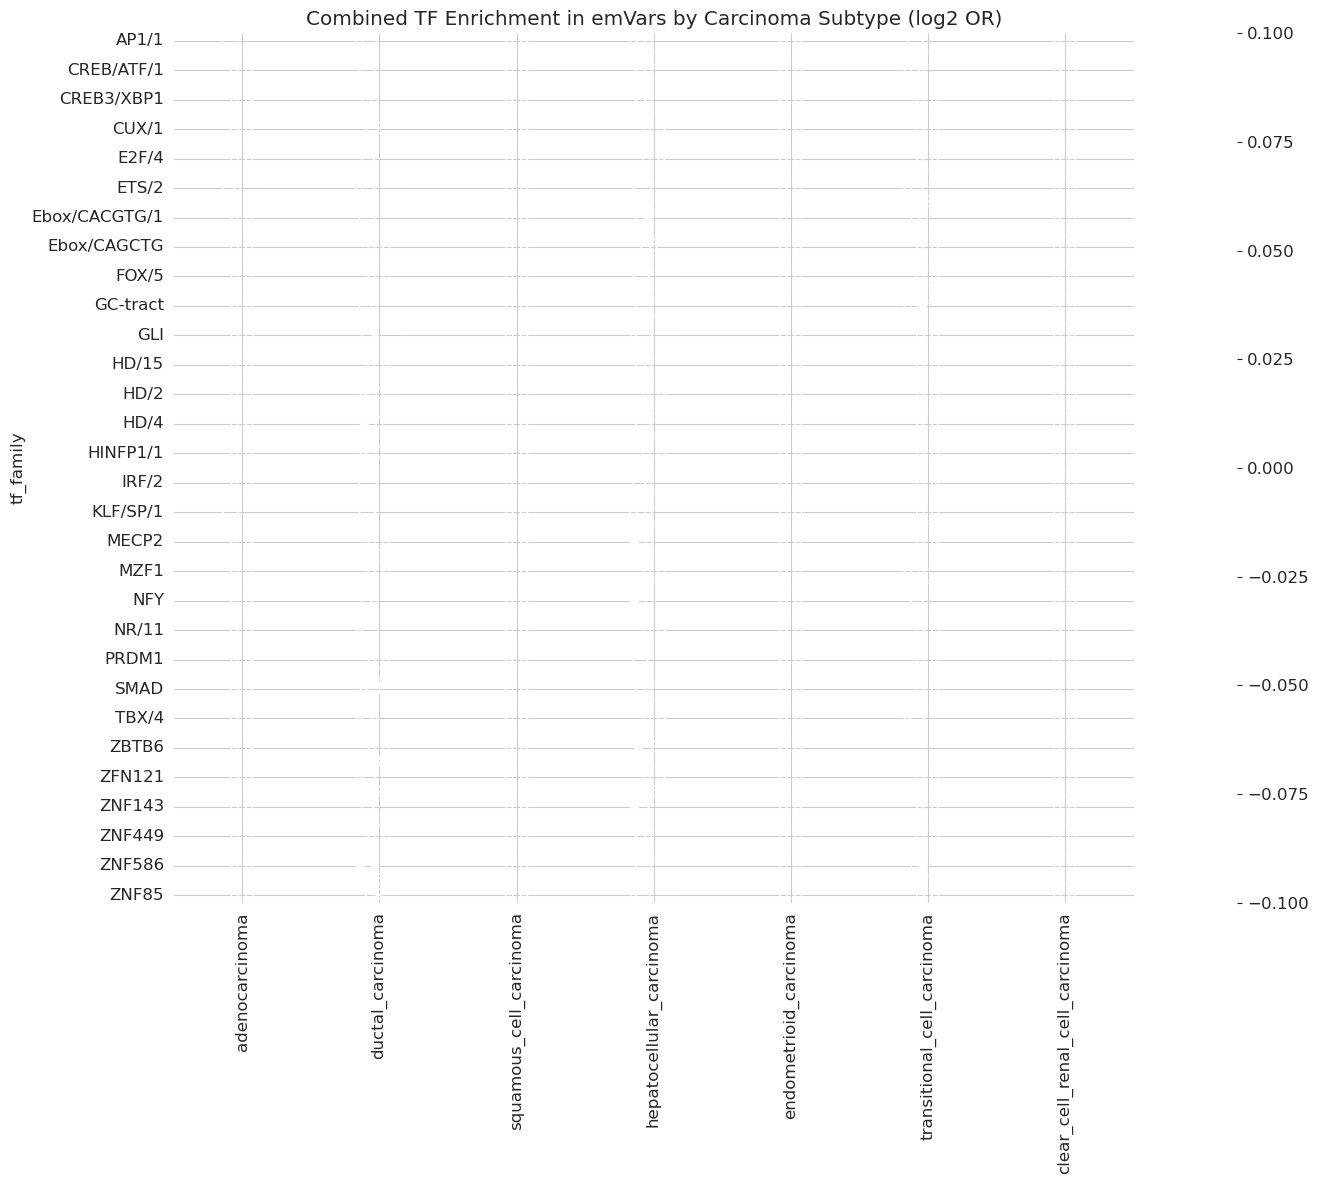

In [73]:
# Combined 5c: TF enrichment in emVars by carcinoma subtype
comb_emvar_by_carcinoma = {}

for subtype in major_carcinoma_subtypes:
    col_name = f'is_{subtype}'
    subtype_df = cosmic_carcinoma[cosmic_carcinoma[col_name] == 1].copy()
    if len(subtype_df) < 100 or subtype_df['emvar_any'].sum() < 10:
        continue
    result = fisher_exact_enrichment(subtype_df, 'any_combined_tf_fam', 'emvar_any', condition_val=1, min_count=3)
    comb_emvar_by_carcinoma[subtype] = result
    if not result.empty:
        print(f"{subtype}: {len(result[result['p_adj'] < 0.05])} sig TFs in emVars")

fig = plot_enrichment_heatmap(
    comb_emvar_by_carcinoma,
    'Combined TF Enrichment in emVars by Carcinoma Subtype (log2 OR)',
    figsize=(14, 12)
)
if fig:
    plt.show()
